In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('application_data.csv')

In [ ]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df.isnull().sum()

SK_ID_CURR                        0
TARGET                            0
NAME_CONTRACT_TYPE                0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY     41519
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_MON     41519
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_YEAR    41519
Length: 122, dtype: int64

In [ ]:
df.info(verbose=True,max_cols=130)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 122 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   SK_ID_CURR                    307511 non-null  int64  
 1   TARGET                        307511 non-null  int64  
 2   NAME_CONTRACT_TYPE            307511 non-null  object 
 3   CODE_GENDER                   307511 non-null  object 
 4   FLAG_OWN_CAR                  307511 non-null  object 
 5   FLAG_OWN_REALTY               307511 non-null  object 
 6   CNT_CHILDREN                  307511 non-null  int64  
 7   AMT_INCOME_TOTAL              307511 non-null  float64
 8   AMT_CREDIT                    307511 non-null  float64
 9   AMT_ANNUITY                   307499 non-null  float64
 10  AMT_GOODS_PRICE               307233 non-null  float64
 11  NAME_TYPE_SUITE               306219 non-null  object 
 12  NAME_INCOME_TYPE              307511 non-nu

In [ ]:
data1 = df.dropna(subset = ['HOUSETYPE_MODE'],axis=0,how='any')

In [ ]:
data1.index

Int64Index([     0,      1,     12,     13,     14,     18,     20,     22,
                23,     24,
            ...
            307495, 307498, 307500, 307501, 307505, 307506, 307507, 307508,
            307509, 307510],
           dtype='int64', length=153214)

In [ ]:
data1.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
12,100016,0,Cash loans,F,N,Y,0,67500.0,80865.0,5881.5,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,0.0
13,100017,0,Cash loans,M,Y,N,1,225000.0,918468.0,28966.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
14,100018,0,Cash loans,F,N,Y,0,189000.0,773680.5,32778.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
data1.isnull().sum()

SK_ID_CURR                        0
TARGET                            0
NAME_CONTRACT_TYPE                0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY     19295
AMT_REQ_CREDIT_BUREAU_WEEK    19295
AMT_REQ_CREDIT_BUREAU_MON     19295
AMT_REQ_CREDIT_BUREAU_QRT     19295
AMT_REQ_CREDIT_BUREAU_YEAR    19295
Length: 122, dtype: int64

In [ ]:
x_122=(data1.isnull().sum()/len(data1))*100

In [ ]:
y_122=x_122[x_122>25].index

In [ ]:
y_122

Index(['OWN_CAR_AGE', 'OCCUPATION_TYPE', 'EXT_SOURCE_1', 'YEARS_BUILD_AVG',
       'COMMONAREA_AVG', 'FLOORSMIN_AVG', 'LIVINGAPARTMENTS_AVG',
       'NONLIVINGAPARTMENTS_AVG', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE',
       'FLOORSMIN_MODE', 'LIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_MODE',
       'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'FLOORSMIN_MEDI',
       'LIVINGAPARTMENTS_MEDI', 'NONLIVINGAPARTMENTS_MEDI',
       'FONDKAPREMONT_MODE'],
      dtype='object')

In [ ]:
len(y_122)

19

## Karthik

In [ ]:
data1.iloc[:,72:78].isnull().sum()

APARTMENTS_MEDI                  3787
BASEMENTAREA_MEDI               26919
YEARS_BEGINEXPLUATATION_MEDI      879
YEARS_BUILD_MEDI                50481
COMMONAREA_MEDI                 60772
ELEVATORS_MEDI                  11134
dtype: int64

In [ ]:
from scipy.stats import shapiro
from scipy import stats

## APARTMENTS_MEDI 
#### Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor

In [ ]:
data1['APARTMENTS_MEDI'].value_counts()

0.0833    6997
0.0625    6610
0.0937    4570
0.0729    4172
0.0083    3500
          ... 
0.4689       1
0.6787       1
0.7724       1
0.9098       1
0.9108       1
Name: APARTMENTS_MEDI, Length: 1148, dtype: int64

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='APARTMENTS_MEDI', ylabel='Density'>

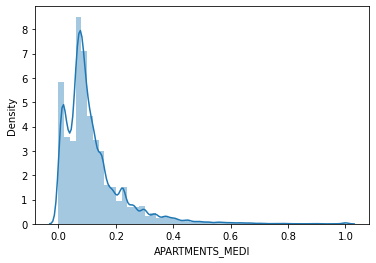

In [ ]:
sns.distplot(data1['APARTMENTS_MEDI'])

<AxesSubplot:xlabel='TARGET', ylabel='APARTMENTS_MEDI'>

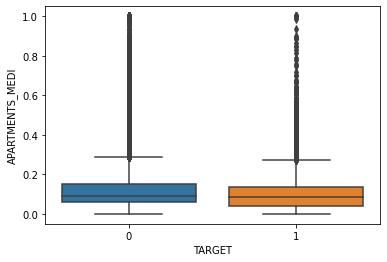

In [ ]:
sns.boxplot(y=data1['APARTMENTS_MEDI'],x=data1['TARGET'])

In [ ]:
Q1 = data1['APARTMENTS_MEDI'].quantile(0.25)
Q3 = data1['APARTMENTS_MEDI'].quantile(0.75)
IQR = Q3-Q1
UB = Q3+1.5*IQR
LB = Q1-1.5*IQR

data1['APARTMENTS_MEDI'] = data1['APARTMENTS_MEDI'].clip(upper=UB,lower=LB)

<ipython-input-935-c44e86e61c95>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1['APARTMENTS_MEDI'] = data1['APARTMENTS_MEDI'].clip(upper=UB,lower=LB)


<AxesSubplot:xlabel='TARGET', ylabel='APARTMENTS_MEDI'>

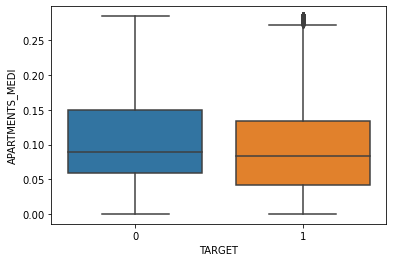

In [ ]:
sns.boxplot(y=data1['APARTMENTS_MEDI'],x=data1['TARGET'])

In [ ]:
#Outliers are removed as we can see

In [ ]:
# Hypothesis
# H0: Data is normal
# H1: Data is not normal
    
shapiro(data1['APARTMENTS_MEDI'])

C:\Users\saketh\anaconda3\lib\site-packages\scipy\stats\morestats.py:1681: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


ShapiroResult(statistic=nan, pvalue=1.0)

In [ ]:
#As the shapiro test is giving pvalue greater than significance level we can say that data is normally distributed

In [ ]:
# Hypothesis
# H0: No relation with the target column
# H1: Relationship exists with the target column

stats.mannwhitneyu(data1['APARTMENTS_MEDI'],data1['TARGET'])

MannwhitneyuResult(statistic=1646358987.0, pvalue=0.0)

In [ ]:
#pvalue obtained is less than significance level which concludes that there is a significant relation
#between APARTMENTS_MEDI and TARGET columns

## BASEMENTAREA_MEDI 
#### Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor

In [ ]:
data1['BASEMENTAREA_MEDI'].value_counts()

0.0000    14882
0.0818      271
0.1091      263
0.0545      262
0.0727      246
          ...  
0.3026        1
0.4647        1
0.3462        1
0.2983        1
0.7471        1
Name: BASEMENTAREA_MEDI, Length: 3768, dtype: int64

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='BASEMENTAREA_MEDI', ylabel='Density'>

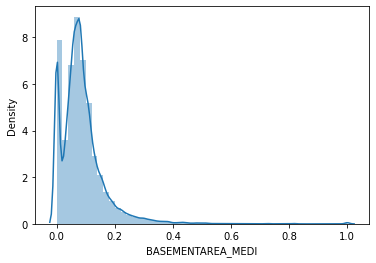

In [ ]:
sns.distplot(data1['BASEMENTAREA_MEDI'])

<AxesSubplot:xlabel='TARGET', ylabel='BASEMENTAREA_MEDI'>

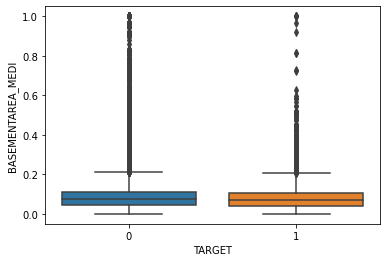

In [ ]:
sns.boxplot(y=data1['BASEMENTAREA_MEDI'],x=data1['TARGET'])

In [ ]:
Q1 = data1['BASEMENTAREA_MEDI'].quantile(0.25)
Q3 = data1['BASEMENTAREA_MEDI'].quantile(0.75)
IQR = Q3-Q1
UB = Q3+1.5*IQR
LB = Q1-1.5*IQR

data1['BASEMENTAREA_MEDI'] = data1['BASEMENTAREA_MEDI'].clip(upper=UB,lower=LB)

<ipython-input-945-55caf9aebbf9>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1['BASEMENTAREA_MEDI'] = data1['BASEMENTAREA_MEDI'].clip(upper=UB,lower=LB)


<AxesSubplot:xlabel='TARGET', ylabel='BASEMENTAREA_MEDI'>

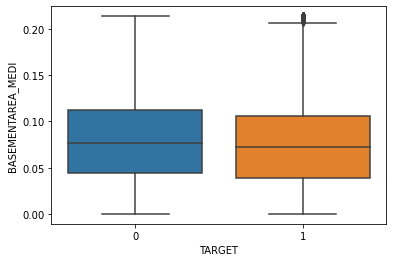

In [ ]:
sns.boxplot(y=data1['BASEMENTAREA_MEDI'],x=data1['TARGET'])

In [ ]:
# Hypothesis
# H0: Data is normal
# H1: Data is not normal
    
shapiro(data1['BASEMENTAREA_MEDI'])

C:\Users\saketh\anaconda3\lib\site-packages\scipy\stats\morestats.py:1681: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


ShapiroResult(statistic=nan, pvalue=1.0)

In [ ]:
#As the shapiro test is giving pvalue greater than significance level we can say that data is normally distributed

In [ ]:
# Hypothesis
# H0: No relation with the target column
# H1: Relationship exists with the target column

stats.mannwhitneyu(data1['BASEMENTAREA_MEDI'],data1['TARGET'])

MannwhitneyuResult(statistic=2412397444.0, pvalue=0.0)

In [ ]:
#pvalue obtained is less than significance level which concludes that there is a
#significant relation between BASEMENTAREA_MEDI and TARGET columns

## YEARS_BEGINEXPLUATATION_MEDI
#### Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor

In [ ]:
data1['YEARS_BEGINEXPLUATATION_MEDI'].value_counts()

0.9871    4174
0.9861    4119
0.9856    4045
0.9866    3993
0.9801    3953
          ... 
0.8992       1
0.6841       1
0.4908       1
0.8987       1
0.8823       1
Name: YEARS_BEGINEXPLUATATION_MEDI, Length: 244, dtype: int64

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='YEARS_BEGINEXPLUATATION_MEDI', ylabel='Density'>

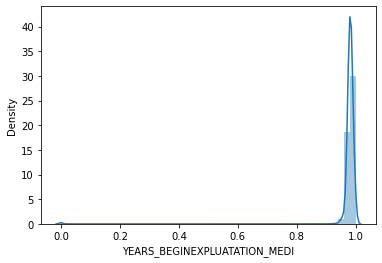

In [ ]:
sns.distplot(data1['YEARS_BEGINEXPLUATATION_MEDI'])

<AxesSubplot:xlabel='TARGET', ylabel='YEARS_BEGINEXPLUATATION_MEDI'>

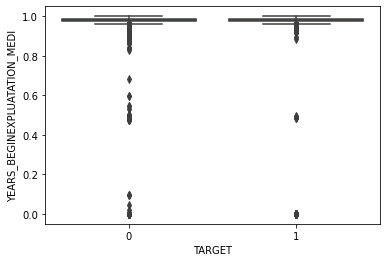

In [ ]:
sns.boxplot(y=data1['YEARS_BEGINEXPLUATATION_MEDI'],x=data1['TARGET'])

In [ ]:
Q1 = data1['YEARS_BEGINEXPLUATATION_MEDI'].quantile(0.25)
Q3 = data1['YEARS_BEGINEXPLUATATION_MEDI'].quantile(0.75)
IQR = Q3-Q1
UB = Q3+1.5*IQR
LB = Q1-1.5*IQR

data1['YEARS_BEGINEXPLUATATION_MEDI'] = data1['YEARS_BEGINEXPLUATATION_MEDI'].clip(upper=UB,lower=LB)

<ipython-input-954-060e4355f10a>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1['YEARS_BEGINEXPLUATATION_MEDI'] = data1['YEARS_BEGINEXPLUATATION_MEDI'].clip(upper=UB,lower=LB)


<AxesSubplot:xlabel='TARGET', ylabel='YEARS_BEGINEXPLUATATION_MEDI'>

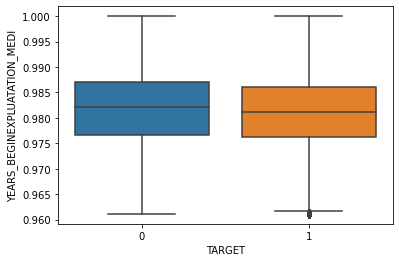

In [ ]:
sns.boxplot(y=data1['YEARS_BEGINEXPLUATATION_MEDI'],x=data1['TARGET'])

In [ ]:
# Hypothesis
# H0: Data is normal
# H1: Data is not normal
    
shapiro(data1['YEARS_BEGINEXPLUATATION_MEDI'])

C:\Users\saketh\anaconda3\lib\site-packages\scipy\stats\morestats.py:1681: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


ShapiroResult(statistic=nan, pvalue=1.0)

In [ ]:
#As the shapiro test is giving pvalue greater than significance level we can say that data is normally distributed

In [ ]:
# Hypothesis
# H0: No relation with the target column
# H1: Relationship exists with the target column

stats.mannwhitneyu(data1['YEARS_BEGINEXPLUATATION_MEDI'],data1['TARGET'])

MannwhitneyuResult(statistic=1629654265.0, pvalue=0.0)

In [ ]:
#pvalue obtained is less than significance level which concludes that there is a
#significant relation between YEARS_BEGINEXPLUATATION_MEDI and TARGET columns

## YEARS_BUILD_MEDI
#### Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor

In [ ]:
data1['YEARS_BUILD_MEDI'].value_counts()

0.8256    2980
0.8189    2870
0.8054    2836
0.7316    2791
0.8121    2780
          ... 
0.1278       2
0.0138       2
0.0339       1
0.0071       1
0.0406       1
Name: YEARS_BUILD_MEDI, Length: 151, dtype: int64

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='YEARS_BUILD_MEDI', ylabel='Density'>

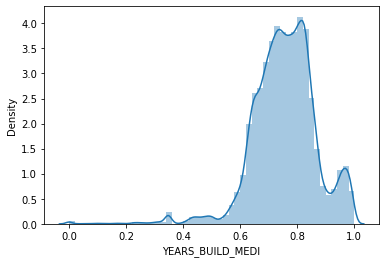

In [ ]:
sns.distplot(data1['YEARS_BUILD_MEDI'])

<AxesSubplot:xlabel='TARGET', ylabel='YEARS_BUILD_MEDI'>

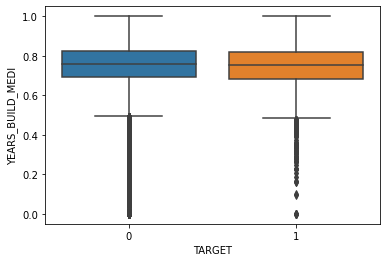

In [ ]:
sns.boxplot(y=data1['YEARS_BUILD_MEDI'],x=data1['TARGET'])

In [ ]:
Q1 = data1['YEARS_BUILD_MEDI'].quantile(0.25)
Q3 = data1['YEARS_BUILD_MEDI'].quantile(0.75)
IQR = Q3-Q1
UB = Q3+1.5*IQR
LB = Q1-1.5*IQR

data1['YEARS_BUILD_MEDI'] = data1['YEARS_BUILD_MEDI'].clip(upper=UB,lower=LB)

<ipython-input-963-34e78b307949>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1['YEARS_BUILD_MEDI'] = data1['YEARS_BUILD_MEDI'].clip(upper=UB,lower=LB)


<AxesSubplot:xlabel='TARGET', ylabel='YEARS_BUILD_MEDI'>

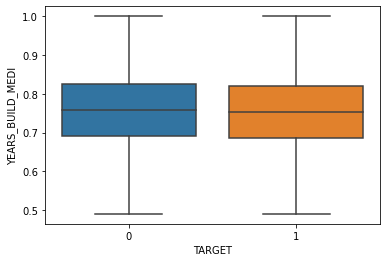

In [ ]:
sns.boxplot(y=data1['YEARS_BUILD_MEDI'],x=data1['TARGET'])

In [ ]:
# Hypothesis
# H0: Data is normal
# H1: Data is not normal
    
shapiro(data1['YEARS_BUILD_MEDI'])

C:\Users\saketh\anaconda3\lib\site-packages\scipy\stats\morestats.py:1681: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


ShapiroResult(statistic=nan, pvalue=1.0)

In [ ]:
#As the shapiro test is giving pvalue greater than significance level we can say that data is normally distributed

In [ ]:
# Hypothesis
# H0: No relation with the target column
# H1: Relationship exists with the target column

stats.mannwhitneyu(data1['YEARS_BUILD_MEDI'],data1['TARGET'])

MannwhitneyuResult(statistic=1098782610.0, pvalue=0.0)

In [ ]:
#pvalue obtained is less than significance level which concludes that there is a
#significant relation between YEARS_BUILD_MEDI and TARGET columns

## COMMONAREA_MEDI
#### Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor

In [ ]:
data1['COMMONAREA_MEDI'].value_counts()

0.0000    8648
0.0079     579
0.0080     486
0.0078     478
0.0086     376
          ... 
0.1773       1
0.5967       1
0.4433       1
0.2677       1
0.4833       1
Name: COMMONAREA_MEDI, Length: 3201, dtype: int64

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='COMMONAREA_MEDI', ylabel='Density'>

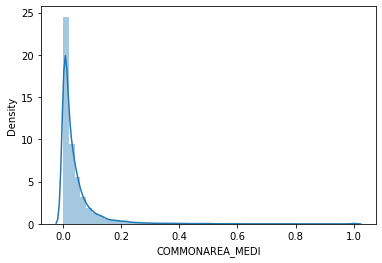

In [ ]:
sns.distplot(data1['COMMONAREA_MEDI'])

<AxesSubplot:xlabel='TARGET', ylabel='COMMONAREA_MEDI'>

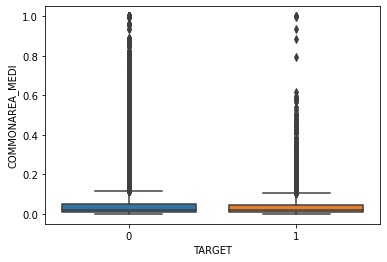

In [ ]:
sns.boxplot(y=data1['COMMONAREA_MEDI'],x=data1['TARGET'])

In [ ]:
Q1 = data1['COMMONAREA_MEDI'].quantile(0.25)
Q3 = data1['COMMONAREA_MEDI'].quantile(0.75)
IQR = Q3-Q1
UB = Q3+1.5*IQR
LB = Q1-1.5*IQR

data1['COMMONAREA_MEDI'] = data1['COMMONAREA_MEDI'].clip(upper=UB,lower=LB)

<ipython-input-972-b139d9cbaac3>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1['COMMONAREA_MEDI'] = data1['COMMONAREA_MEDI'].clip(upper=UB,lower=LB)


<AxesSubplot:xlabel='TARGET', ylabel='COMMONAREA_MEDI'>

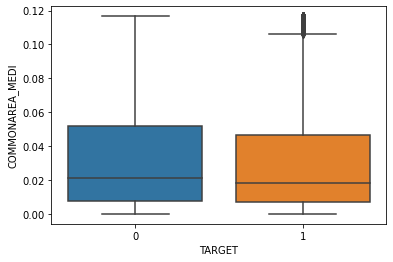

In [ ]:
sns.boxplot(y=data1['COMMONAREA_MEDI'],x=data1['TARGET'])

In [ ]:
# Hypothesis
# H0: Data is normal
# H1: Data is not normal
    
shapiro(data1['COMMONAREA_MEDI'])

C:\Users\saketh\anaconda3\lib\site-packages\scipy\stats\morestats.py:1681: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


ShapiroResult(statistic=nan, pvalue=1.0)

In [ ]:
#As the shapiro test is giving pvalue less than significance level we can say that data is not normally distributed

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='COMMONAREA_MEDI', ylabel='Density'>

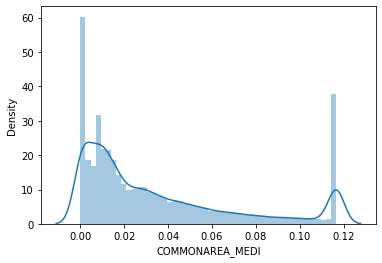

In [ ]:
sns.distplot(data1['COMMONAREA_MEDI'])

In [ ]:
pt = PowerTransformer()

In [ ]:
data1['COMMONAREA_MEDI'] = pt.fit_transform(data1[['COMMONAREA_MEDI']])

<ipython-input-978-d2ff7747f613>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1['COMMONAREA_MEDI'] = pt.fit_transform(data1[['COMMONAREA_MEDI']])


In [ ]:
data1['COMMONAREA_MEDI'].describe()

count    9.244200e+04
mean     1.455125e-16
std      1.000005e+00
min     -1.341876e+00
25%     -8.402431e-01
50%     -1.758656e-01
75%      8.328482e-01
max      1.708007e+00
Name: COMMONAREA_MEDI, dtype: float64

In [ ]:
# Hypothesis
# H0: No relation with the target column
# H1: Relationship exists with the target column

stats.mannwhitneyu(data1['COMMONAREA_MEDI'],data1['TARGET'])

MannwhitneyuResult(statistic=7915403960.0, pvalue=0.0)

In [ ]:
#pvalue obtained is less than significance level which concludes that there is a
#significant relation between COMMONAREA_MEDI and TARGET columns

## ELEVATORS_MEDI
#### Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor

In [ ]:
data1['ELEVATORS_MEDI'].value_counts()

0.00    86196
0.08    10674
0.16     9134
0.24     6316
0.12     5871
0.04     4770
0.20     4138
0.32     2903
0.28     2283
0.40     1586
0.36     1386
0.48     1089
0.44      714
0.10      534
0.56      492
0.64      453
0.06      385
0.14      383
0.02      363
0.52      284
0.18      279
0.60      247
0.72      223
0.22      222
1.00      158
0.26      145
0.80      140
0.68      112
0.30       94
0.96       80
0.34       80
0.88       68
0.38       62
0.76       45
0.84       32
0.42       32
0.46       23
0.92       20
0.50       16
0.54       10
0.78       10
0.90        6
0.58        6
0.74        6
0.62        5
0.66        5
Name: ELEVATORS_MEDI, dtype: int64

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='ELEVATORS_MEDI', ylabel='Density'>

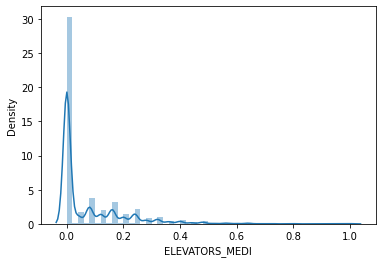

In [ ]:
sns.distplot(data1['ELEVATORS_MEDI'])

<AxesSubplot:xlabel='TARGET', ylabel='ELEVATORS_MEDI'>

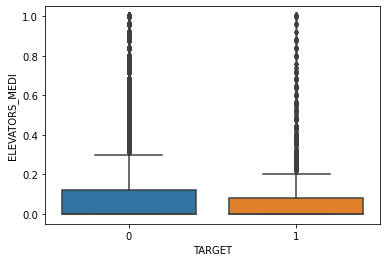

In [ ]:
sns.boxplot(y=data1['ELEVATORS_MEDI'],x=data1['TARGET'])

In [ ]:
Q1 = data1['ELEVATORS_MEDI'].quantile(0.25)
Q3 = data1['ELEVATORS_MEDI'].quantile(0.75)
IQR = Q3-Q1
UB = Q3+1.5*IQR
LB = Q1-1.5*IQR

data1['ELEVATORS_MEDI'] = data1['ELEVATORS_MEDI'].clip(upper=UB,lower=LB)

<ipython-input-985-8bd182482d5a>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1['ELEVATORS_MEDI'] = data1['ELEVATORS_MEDI'].clip(upper=UB,lower=LB)


<AxesSubplot:xlabel='TARGET', ylabel='ELEVATORS_MEDI'>

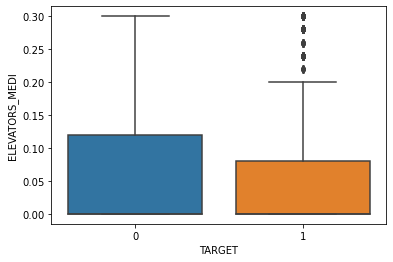

In [ ]:
sns.boxplot(y=data1['ELEVATORS_MEDI'],x=data1['TARGET'])

In [ ]:
#Outliers are removed as we can see

In [ ]:
# Hypothesis
# H0: Data is normal
# H1: Data is not normal
    
shapiro(data1['ELEVATORS_MEDI'])

C:\Users\saketh\anaconda3\lib\site-packages\scipy\stats\morestats.py:1681: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


ShapiroResult(statistic=nan, pvalue=1.0)

In [ ]:
#As the shapiro test is giving pvalue greater than significance level we can say that data is normally distributed

In [ ]:
# Hypothesis
# H0: No relation with the target column
# H1: Relationship exists with the target column

stats.mannwhitneyu(data1['ELEVATORS_MEDI'],data1['TARGET'])

MannwhitneyuResult(statistic=7662819282.0, pvalue=0.0)

In [ ]:
#pvalue obtained is less than significance level which concludes that there is a significant relation
#between ELEVATORS_MEDI and TARGET columns

## Mahesh Kodumuri

In [ ]:
data1.iloc[:,78:84].isnull().sum()

ENTRANCES_MEDI            3281
FLOORSMAX_MEDI            1727
FLOORSMIN_MEDI           54590
LANDAREA_MEDI            28816
LIVINGAPARTMENTS_MEDI    56143
LIVINGAREA_MEDI           4767
dtype: int64

In [ ]:
from scipy.stats import shapiro
from scipy import stats

## ENTRANCES_MEDI
#### Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor

In [ ]:
data1['ENTRANCES_MEDI'].value_counts()

0.1379    34872
0.0690    23586
0.1034    20127
0.2069    19479
0.0345    15829
0.1724     9431
0.2759     7905
0.2414     4255
0.3448     2087
0.3103     2055
0.0862     1342
0.1207     1212
0.4138     1181
0.3793     1003
0.1552      775
0.0517      606
0.1897      546
0.4828      503
0.4483      431
0.5517      351
0.5172      301
0.0000      292
0.2241      274
0.6207      241
0.5862      186
0.2586      169
1.0000      153
0.6897      115
0.2931      106
0.6552       68
0.3276       59
0.8966       52
0.7586       48
0.7241       44
0.8276       42
0.3621       39
0.7931       39
0.4310       31
0.9655       25
0.9310       21
0.8621       14
0.3966       14
0.4655       12
0.0172        7
0.5690        4
0.5000        1
Name: ENTRANCES_MEDI, dtype: int64

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='ENTRANCES_MEDI', ylabel='Density'>

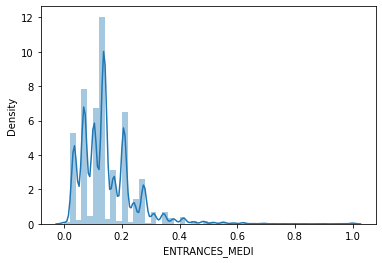

In [ ]:
sns.distplot(data1['ENTRANCES_MEDI'])

<AxesSubplot:xlabel='TARGET', ylabel='ENTRANCES_MEDI'>

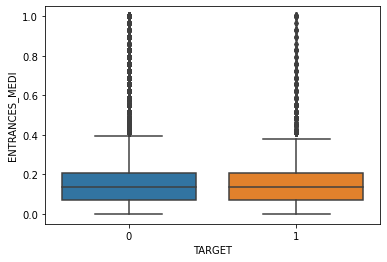

In [ ]:
sns.boxplot(y=data1['ENTRANCES_MEDI'],x=data1['TARGET'])

In [ ]:
Q1 = data1['ENTRANCES_MEDI'].quantile(0.25)
Q3 = data1['ENTRANCES_MEDI'].quantile(0.75)
IQR = Q3-Q1
UB = Q3+1.5*IQR
LB = Q1-1.5*IQR

data1['ENTRANCES_MEDI'] = data1['ENTRANCES_MEDI'].clip(upper=UB,lower=LB)

<ipython-input-997-007dd8706a03>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1['ENTRANCES_MEDI'] = data1['ENTRANCES_MEDI'].clip(upper=UB,lower=LB)


<AxesSubplot:xlabel='TARGET', ylabel='ENTRANCES_MEDI'>

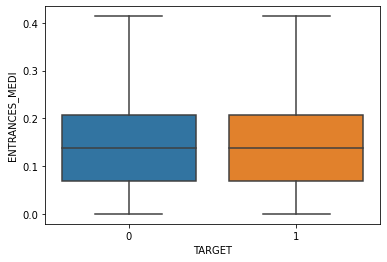

In [ ]:
sns.boxplot(y=data1['ENTRANCES_MEDI'],x=data1['TARGET'])

In [ ]:
#Outliers are removed as we can see

In [ ]:
# Hypothesis
# H0: Data is normal
# H1: Data is not normal
    
shapiro(data1['ENTRANCES_MEDI'])

C:\Users\saketh\anaconda3\lib\site-packages\scipy\stats\morestats.py:1681: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


ShapiroResult(statistic=nan, pvalue=1.0)

In [ ]:
#As the shapiro test is giving pvalue greater than significance level we can say that data is normally distributed

In [ ]:
# Hypothesis
# H0: No relation with the target column
# H1: Relationship exists with the target column

stats.mannwhitneyu(data1['ENTRANCES_MEDI'],data1['TARGET'])

MannwhitneyuResult(statistic=1625839079.0, pvalue=0.0)

In [ ]:
#pvalue obtained is less than significance level which concludes that there is a significant relation
#between ENTRANCES_MEDI and TARGET columns

## FLOORSMAX_MEDI
#### Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor

In [ ]:
data1['FLOORSMAX_MEDI'].value_counts()

0.1667    62548
0.3333    32664
0.0417    14356
0.3750     8097
0.1250     6926
0.0833     6500
0.4583     3038
0.0000     2828
0.6250     2025
0.5417     1841
0.6667     1662
0.2500     1639
0.2083     1509
0.2917      558
0.1042      459
0.3542      453
0.5833      435
0.3958      331
0.4167      323
0.1458      311
0.5000      304
0.2708      288
0.1875      240
0.8750      223
0.4792      219
0.7083      203
1.0000      167
0.4375      138
0.7500      135
0.3125      131
0.0625      128
0.2292      126
0.0208      124
0.6042      115
0.9583       95
0.7917       60
0.5208       47
0.5625       46
0.9167       36
0.8333       35
0.6458       30
0.7708       27
0.6875       24
0.8125       23
0.7292       10
0.9375        4
0.8542        3
0.8958        2
0.9792        1
Name: FLOORSMAX_MEDI, dtype: int64

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='FLOORSMAX_MEDI', ylabel='Density'>

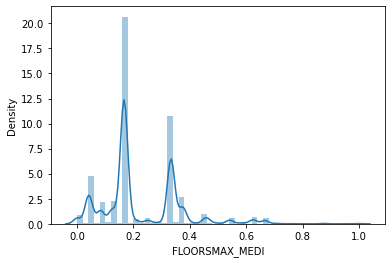

In [ ]:
sns.distplot(data1['FLOORSMAX_MEDI'])

<AxesSubplot:xlabel='TARGET', ylabel='FLOORSMAX_MEDI'>

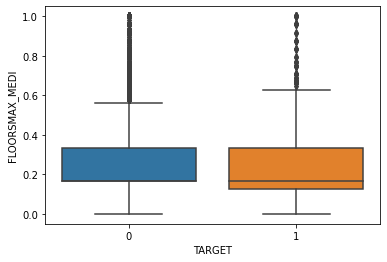

In [ ]:
sns.boxplot(y=data1['FLOORSMAX_MEDI'],x=data1['TARGET'])

In [ ]:
Q1 = data1['FLOORSMAX_MEDI'].quantile(0.25)
Q3 = data1['FLOORSMAX_MEDI'].quantile(0.75)
IQR = Q3-Q1
UB = Q3+1.5*IQR
LB = Q1-1.5*IQR

data1['FLOORSMAX_MEDI'] = data1['FLOORSMAX_MEDI'].clip(upper=UB,lower=LB)

<ipython-input-1007-bae913bbcbd4>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1['FLOORSMAX_MEDI'] = data1['FLOORSMAX_MEDI'].clip(upper=UB,lower=LB)


<AxesSubplot:xlabel='TARGET', ylabel='FLOORSMAX_MEDI'>

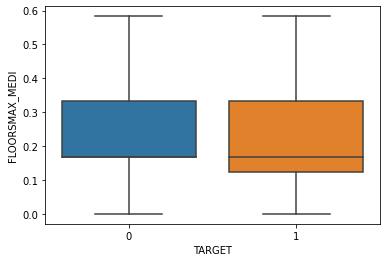

In [ ]:
sns.boxplot(y=data1['FLOORSMAX_MEDI'],x=data1['TARGET'])

In [ ]:
# Hypothesis
# H0: Data is normal
# H1: Data is not normal
    
shapiro(data1['FLOORSMAX_MEDI'])

C:\Users\saketh\anaconda3\lib\site-packages\scipy\stats\morestats.py:1681: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


ShapiroResult(statistic=nan, pvalue=1.0)

In [ ]:
#As the shapiro test is giving pvalue greater than significance level we can say that data is normally distributed

In [ ]:
# Hypothesis
# H0: No relation with the target column
# H1: Relationship exists with the target column

stats.mannwhitneyu(data1['FLOORSMAX_MEDI'],data1['TARGET'])

MannwhitneyuResult(statistic=1823176061.0, pvalue=0.0)

In [ ]:
#pvalue obtained is less than significance level which concludes that there is a
#significant relation between FLOORSMAX_MEDI and TARGET columns

## FLOORSMIN_MEDI
#### Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor

In [ ]:
data1['FLOORSMIN_MEDI'].value_counts()

0.2083    33677
0.3750    18499
0.0417    17994
0.0833     5127
0.4167     4064
0.1667     3556
0.1250     3361
0.0000     2349
0.5000     1831
0.6667     1260
0.7083     1108
0.5833     1055
0.2917      852
0.2500      778
0.3333      338
0.6250      234
0.5417      212
0.3958      205
0.4375      186
0.1458      180
0.1875      157
0.4583      154
0.3125      148
1.0000      147
0.9167      130
0.2292      121
0.7500      116
0.1042      106
0.2708      104
0.5208       81
0.3542       79
0.7917       64
0.4792       61
0.0625       51
0.0208       50
0.6458       49
0.8333       27
0.5625       19
0.8750       16
0.6042       16
0.9583       14
0.8125       12
0.7292       10
0.6875        9
0.7708        7
0.9792        5
0.8542        5
Name: FLOORSMIN_MEDI, dtype: int64

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='FLOORSMIN_MEDI', ylabel='Density'>

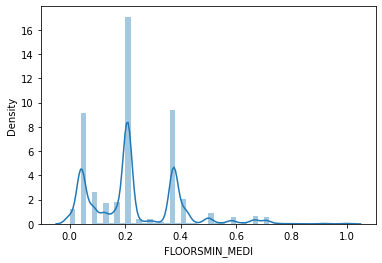

In [ ]:
sns.distplot(data1['FLOORSMIN_MEDI'])

<AxesSubplot:xlabel='TARGET', ylabel='FLOORSMIN_MEDI'>

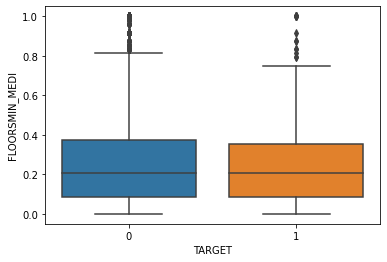

In [ ]:
sns.boxplot(y=data1['FLOORSMIN_MEDI'],x=data1['TARGET'])

In [ ]:
Q1 = data1['FLOORSMIN_MEDI'].quantile(0.25)
Q3 = data1['FLOORSMIN_MEDI'].quantile(0.75)
IQR = Q3-Q1
UB = Q3+1.5*IQR
LB = Q1-1.5*IQR

data1['FLOORSMIN_MEDI'] = data1['FLOORSMIN_MEDI'].clip(upper=UB,lower=LB)

<ipython-input-1016-2c378ed65d5d>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1['FLOORSMIN_MEDI'] = data1['FLOORSMIN_MEDI'].clip(upper=UB,lower=LB)


<AxesSubplot:xlabel='TARGET', ylabel='FLOORSMIN_MEDI'>

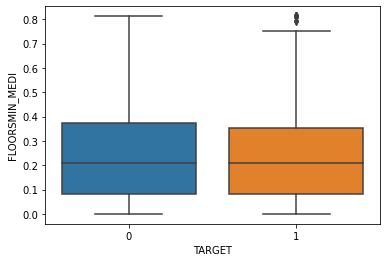

In [ ]:
sns.boxplot(y=data1['FLOORSMIN_MEDI'],x=data1['TARGET'])

In [ ]:
# Hypothesis
# H0: Data is normal
# H1: Data is not normal
    
shapiro(data1['FLOORSMIN_MEDI'])

C:\Users\saketh\anaconda3\lib\site-packages\scipy\stats\morestats.py:1681: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


ShapiroResult(statistic=nan, pvalue=1.0)

In [ ]:
#As the shapiro test is giving pvalue greater than significance level we can say that data is normally distributed

In [ ]:
# Hypothesis
# H0: No relation with the target column
# H1: Relationship exists with the target column

stats.mannwhitneyu(data1['FLOORSMIN_MEDI'],data1['TARGET'])

MannwhitneyuResult(statistic=1223146740.5, pvalue=0.0)

In [ ]:
#pvalue obtained is less than significance level which concludes that there is a
#significant relation between FLOORSMIN_MEDI and TARGET columns

## LANDAREA_MEDI
#### Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor

In [ ]:
data1['LANDAREA_MEDI'].value_counts()

0.0000    15812
0.0193      197
0.0642      194
0.0482      186
0.0161      179
          ...  
0.2393        1
0.3737        1
0.3499        1
0.2632        1
0.2359        1
Name: LANDAREA_MEDI, Length: 3559, dtype: int64

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='LANDAREA_MEDI', ylabel='Density'>

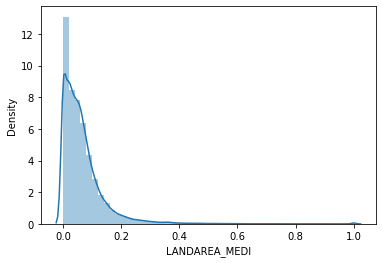

In [ ]:
sns.distplot(data1['LANDAREA_MEDI'])

<AxesSubplot:xlabel='TARGET', ylabel='LANDAREA_MEDI'>

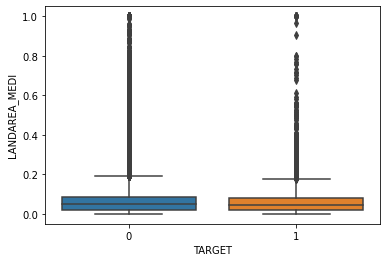

In [ ]:
sns.boxplot(y=data1['LANDAREA_MEDI'],x=data1['TARGET'])

In [ ]:
Q1 = data1['LANDAREA_MEDI'].quantile(0.25)
Q3 = data1['LANDAREA_MEDI'].quantile(0.75)
IQR = Q3-Q1
UB = Q3+1.5*IQR
LB = Q1-1.5*IQR

data1['LANDAREA_MEDI'] = data1['LANDAREA_MEDI'].clip(upper=UB,lower=LB)

<ipython-input-1025-d93089f0d4ce>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1['LANDAREA_MEDI'] = data1['LANDAREA_MEDI'].clip(upper=UB,lower=LB)


<AxesSubplot:xlabel='TARGET', ylabel='LANDAREA_MEDI'>

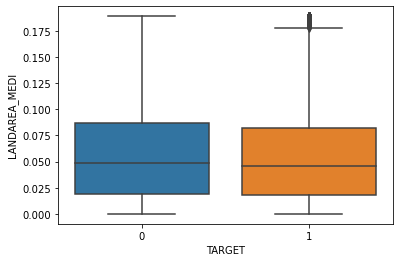

In [ ]:
sns.boxplot(y=data1['LANDAREA_MEDI'],x=data1['TARGET'])

In [ ]:
# Hypothesis
# H0: Data is normal
# H1: Data is not normal
    
shapiro(data1['LANDAREA_MEDI'])

C:\Users\saketh\anaconda3\lib\site-packages\scipy\stats\morestats.py:1681: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


ShapiroResult(statistic=nan, pvalue=1.0)

In [ ]:
#As the shapiro test is giving pvalue greater than significance level we can say that data is normally distributed

In [ ]:
# Hypothesis
# H0: No relation with the target column
# H1: Relationship exists with the target column

stats.mannwhitneyu(data1['LANDAREA_MEDI'],data1['TARGET'])

MannwhitneyuResult(statistic=2458356744.0, pvalue=0.0)

In [ ]:
#pvalue obtained is less than significance level which concludes that there is a
#significant relation between LANDAREA_MEDI and TARGET columns

## LIVINGAPARTMENTS_MEDI
#### Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor

In [ ]:
data1['LIVINGAPARTMENTS_MEDI'].value_counts()

0.0513    4492
0.0684    4487
0.0770    2924
0.0599    2701
0.0855    2010
          ... 
0.2484       1
0.7610       1
0.1706       1
0.8354       1
0.0098       1
Name: LIVINGAPARTMENTS_MEDI, Length: 1097, dtype: int64

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='LIVINGAPARTMENTS_MEDI', ylabel='Density'>

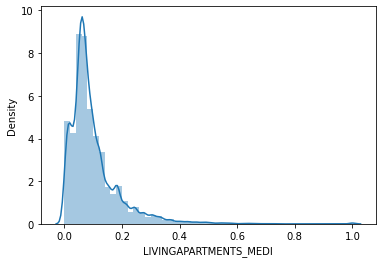

In [ ]:
sns.distplot(data1['LIVINGAPARTMENTS_MEDI'])

<AxesSubplot:xlabel='TARGET', ylabel='LIVINGAPARTMENTS_MEDI'>

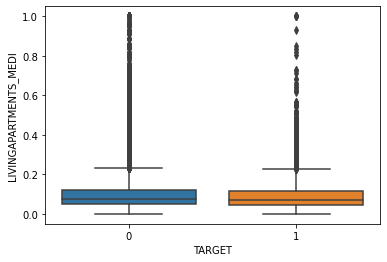

In [ ]:
sns.boxplot(y=data1['LIVINGAPARTMENTS_MEDI'],x=data1['TARGET'])

In [ ]:
Q1 = data1['LIVINGAPARTMENTS_MEDI'].quantile(0.25)
Q3 = data1['LIVINGAPARTMENTS_MEDI'].quantile(0.75)
IQR = Q3-Q1
UB = Q3+1.5*IQR
LB = Q1-1.5*IQR

data1['LIVINGAPARTMENTS_MEDI'] = data1['LIVINGAPARTMENTS_MEDI'].clip(upper=UB,lower=LB)

<ipython-input-1034-1cb1a848595d>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1['LIVINGAPARTMENTS_MEDI'] = data1['LIVINGAPARTMENTS_MEDI'].clip(upper=UB,lower=LB)


<AxesSubplot:xlabel='TARGET', ylabel='LIVINGAPARTMENTS_MEDI'>

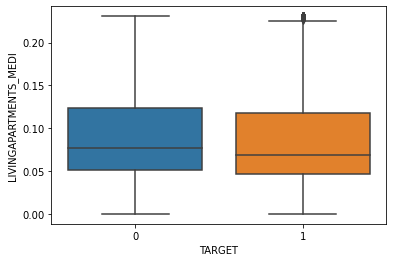

In [ ]:
sns.boxplot(y=data1['LIVINGAPARTMENTS_MEDI'],x=data1['TARGET'])

In [ ]:
# Hypothesis
# H0: Data is normal
# H1: Data is not normal
    
shapiro(data1['LIVINGAPARTMENTS_MEDI'])

C:\Users\saketh\anaconda3\lib\site-packages\scipy\stats\morestats.py:1681: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


ShapiroResult(statistic=nan, pvalue=1.0)

In [ ]:
#As the shapiro test is giving pvalue greater than significance level we can say that data is normally distributed

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='LIVINGAPARTMENTS_MEDI', ylabel='Density'>

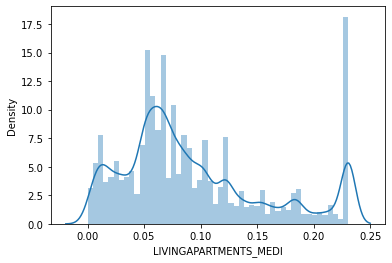

In [ ]:
sns.distplot(data1['LIVINGAPARTMENTS_MEDI'])

In [ ]:
data1['LIVINGAPARTMENTS_MEDI'] = pt.fit_transform(data1[['LIVINGAPARTMENTS_MEDI']])

<ipython-input-1039-72dce2061534>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1['LIVINGAPARTMENTS_MEDI'] = pt.fit_transform(data1[['LIVINGAPARTMENTS_MEDI']])


In [ ]:
data1['LIVINGAPARTMENTS_MEDI'].describe()

count    9.707100e+04
mean     3.589298e-16
std      1.000005e+00
min     -2.018755e+00
25%     -6.064963e-01
50%     -8.945263e-02
75%      6.773735e-01
max      1.751984e+00
Name: LIVINGAPARTMENTS_MEDI, dtype: float64

In [ ]:
# Hypothesis
# H0: No relation with the target column
# H1: Relationship exists with the target column

stats.mannwhitneyu(data1['LIVINGAPARTMENTS_MEDI'],data1['TARGET'])

MannwhitneyuResult(statistic=8301684846.0, pvalue=0.0)

In [ ]:
#pvalue obtained is less than significance level which concludes that there is a
#significant relation between LIVINGAPARTMENTS_MEDI and TARGET columns

## LIVINGAREA_MEDI 
#### Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor

In [ ]:
data1['LIVINGAREA_MEDI'].value_counts()

0.0000    284
0.0548    234
0.0520    231
0.0522    223
0.0518    222
         ... 
0.4588      1
0.8407      1
0.3726      1
0.4892      1
0.5073      1
Name: LIVINGAREA_MEDI, Length: 5258, dtype: int64

In [ ]:
data1['LIVINGAREA_MEDI'].describe()

count    148447.000000
mean          0.109448
std           0.112913
min           0.000000
25%           0.046500
50%           0.075600
75%           0.131200
max           1.000000
Name: LIVINGAREA_MEDI, dtype: float64

In [ ]:
data1['LIVINGAREA_MEDI'].skew()

2.8475246649859223

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='LIVINGAREA_MEDI', ylabel='Density'>

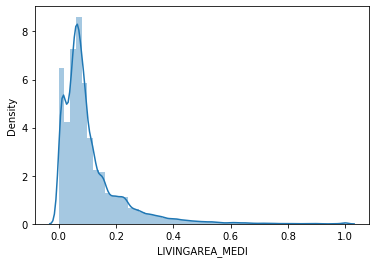

In [ ]:
sns.distplot(data1['LIVINGAREA_MEDI'])

<AxesSubplot:xlabel='TARGET', ylabel='LIVINGAREA_MEDI'>

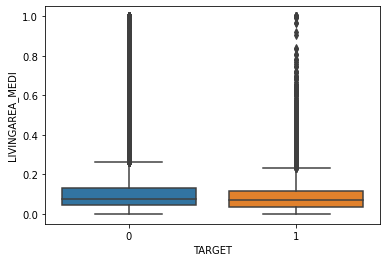

In [ ]:
sns.boxplot(y=data1['LIVINGAREA_MEDI'],x=data1['TARGET'])

In [ ]:
Q1 = data1['LIVINGAREA_MEDI'].quantile(0.25)
Q3 = data1['LIVINGAREA_MEDI'].quantile(0.75)
IQR = Q3-Q1
UB = Q3+1.5*IQR
LB = Q1-1.5*IQR

data1['LIVINGAREA_MEDI'] = data1['LIVINGAREA_MEDI'].clip(upper=UB,lower=LB)

<ipython-input-1048-f788cc6a12c6>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1['LIVINGAREA_MEDI'] = data1['LIVINGAREA_MEDI'].clip(upper=UB,lower=LB)


<AxesSubplot:xlabel='TARGET', ylabel='LIVINGAREA_MEDI'>

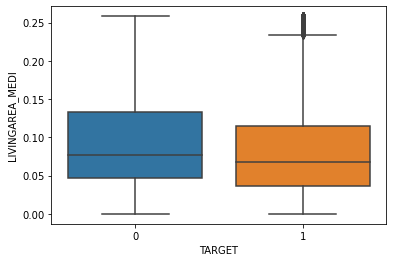

In [ ]:
sns.boxplot(y=data1['LIVINGAREA_MEDI'],x=data1['TARGET'])

In [ ]:
# Hypothesis
# H0: Data is normal
# H1: Data is not normal
    
shapiro(data1['LIVINGAREA_MEDI'])

C:\Users\saketh\anaconda3\lib\site-packages\scipy\stats\morestats.py:1681: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


ShapiroResult(statistic=nan, pvalue=1.0)

In [ ]:
#As the shapiro test is giving pvalue greater than significance level we can say that data is normally distributed

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='LIVINGAREA_MEDI', ylabel='Density'>

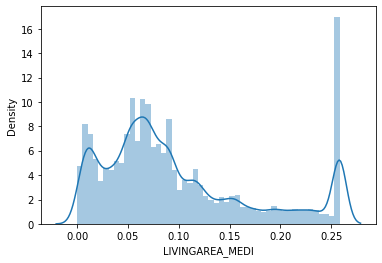

In [ ]:
sns.distplot(data1['LIVINGAREA_MEDI'])

In [ ]:
pt = PowerTransformer()

In [ ]:
data1['LIVINGAREA_MEDI'] = pt.fit_transform(data1[['LIVINGAREA_MEDI']])

<ipython-input-1054-5b2e59135fea>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1['LIVINGAREA_MEDI'] = pt.fit_transform(data1[['LIVINGAREA_MEDI']])


In [ ]:
# Hypothesis
# H0: No relation with the target column
# H1: Relationship exists with the target column

stats.mannwhitneyu(data1['LIVINGAREA_MEDI'],data1['TARGET'])

MannwhitneyuResult(statistic=10776933979.0, pvalue=0.0)

In [ ]:
#pvalue obtained is less than significance level which concludes that there is a
#significant relation between LIVINGAREA_MEDI and TARGET columns

## Yoganand

In [ ]:
data1.iloc[:,84:91].head()

,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE
0,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No
1,0.0039,0.0100,reg oper account,block of flats,0.0714,Block,No
12,NaN,0.0000,reg oper account,block of flats,0.0612,NaN,No
13,0.0000,0.0000,reg oper account,block of flats,0.1417,Panel,No
14,0.0194,0.1022,reg oper account,block of flats,0.3811,Panel,No


In [ ]:
data1.iloc[:,84:91].isnull().sum()

NONLIVINGAPARTMENTS_MEDI    59409
NONLIVINGAREA_MEDI          16863
FONDKAPREMONT_MODE          56209
HOUSETYPE_MODE                  0
TOTALAREA_MODE                241
WALLSMATERIAL_MODE           4278
EMERGENCYSTATE_MODE             0
dtype: int64

### NONLIVINGAPARTMENTS_MEDI - Normalized information about building where the client lives

In [ ]:
data1['NONLIVINGAPARTMENTS_MEDI'].value_counts()

0.0000    55963
0.0039    14097
0.0078     6487
0.0116     3783
0.0155     2554
          ...  
0.3513        1
0.4289        1
0.3649        1
0.2814        1
0.8890        1
Name: NONLIVINGAPARTMENTS_MEDI, Length: 214, dtype: int64

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='NONLIVINGAPARTMENTS_MEDI', ylabel='Density'>

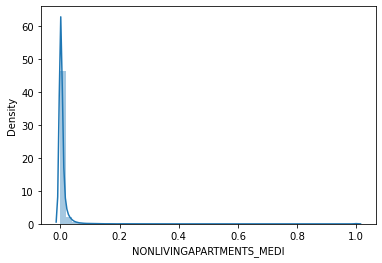

In [ ]:
sns.distplot(data1['NONLIVINGAPARTMENTS_MEDI'])

<AxesSubplot:xlabel='TARGET', ylabel='NONLIVINGAPARTMENTS_MEDI'>

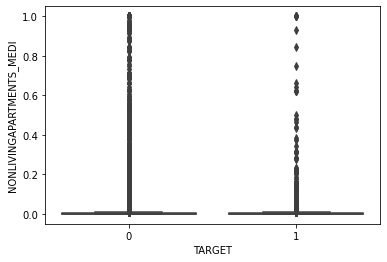

In [ ]:
sns.boxplot(y=data1['NONLIVINGAPARTMENTS_MEDI'],x=data1['TARGET'])

In [ ]:
Q1 = data1['NONLIVINGAPARTMENTS_MEDI'].quantile(0.25)
Q3 = data1['NONLIVINGAPARTMENTS_MEDI'].quantile(0.75)
IQR = Q3-Q1
UB = Q3+1.5*IQR
LB = Q1-1.5*IQR

data1['NONLIVINGAPARTMENTS_MEDI'] = data1['NONLIVINGAPARTMENTS_MEDI'].clip(upper=UB,lower=LB)

<ipython-input-1062-e023c0d88546>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1['NONLIVINGAPARTMENTS_MEDI'] = data1['NONLIVINGAPARTMENTS_MEDI'].clip(upper=UB,lower=LB)


C:\Users\saketh\anaconda3\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='NONLIVINGAPARTMENTS_MEDI', ylabel='Density'>

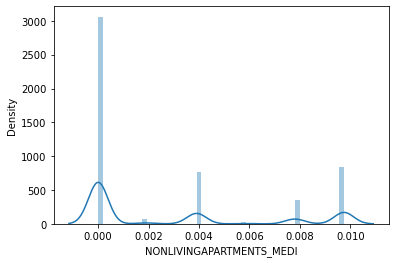

In [ ]:
sns.distplot(data1['NONLIVINGAPARTMENTS_MEDI'])

In [ ]:
from scipy.stats import shapiro
from scipy import stats

# Hypothesis
# H0: Data is normal
# H1: Data is not normal
    
shapiro(data1['NONLIVINGAPARTMENTS_MEDI'])

C:\Users\saketh\anaconda3\lib\site-packages\scipy\stats\morestats.py:1681: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


ShapiroResult(statistic=nan, pvalue=1.0)

<AxesSubplot:xlabel='TARGET', ylabel='NONLIVINGAPARTMENTS_MEDI'>

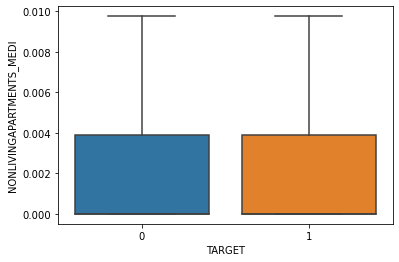

In [ ]:
sns.boxplot(y=data1['NONLIVINGAPARTMENTS_MEDI'],x=data1['TARGET'])

In [ ]:
stats.ttest_ind(data1['NONLIVINGAPARTMENTS_MEDI'],data1['TARGET'])

Ttest_indResult(statistic=nan, pvalue=nan)

In [ ]:
# As the parametric test failed going for non parametric test

# Hypothesis
# H0: No relation with the target column
# H1: Relationship exists with the target column

stats.mannwhitneyu(data1['NONLIVINGAPARTMENTS_MEDI'],data1['TARGET'])

MannwhitneyuResult(statistic=4991798108.5, pvalue=0.0)

### NONLIVINGAREA_MEDI - Normalized information about building where the client lives

In [ ]:
data1['NONLIVINGAREA_MEDI'].value_counts()

0.0000    60423
0.0012      532
0.0022      471
0.0037      452
0.0044      416
          ...  
0.2318        1
0.3137        1
0.3184        1
0.2742        1
0.2244        1
Name: NONLIVINGAREA_MEDI, Length: 3312, dtype: int64

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='NONLIVINGAREA_MEDI', ylabel='Density'>

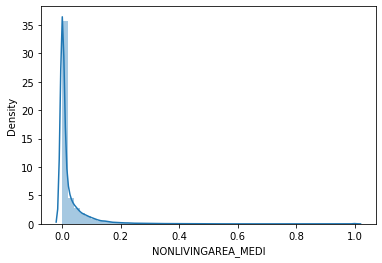

In [ ]:
sns.distplot(data1['NONLIVINGAREA_MEDI'])

<AxesSubplot:xlabel='TARGET', ylabel='NONLIVINGAREA_MEDI'>

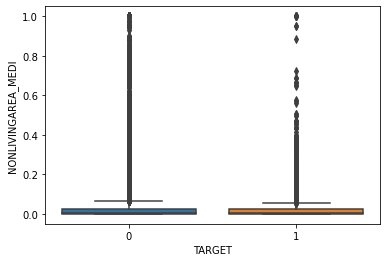

In [ ]:
sns.boxplot(y=data1['NONLIVINGAREA_MEDI'],x=data1['TARGET'])

In [ ]:
Q1 = data1['NONLIVINGAREA_MEDI'].quantile(0.25)
Q3 = data1['NONLIVINGAREA_MEDI'].quantile(0.75)
IQR = Q3-Q1
UB = Q3+1.5*IQR
LB = Q1-1.5*IQR

data1['NONLIVINGAREA_MEDI'] = data1['NONLIVINGAREA_MEDI'].clip(upper=UB,lower=LB)

<ipython-input-1071-9b44856fe02a>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1['NONLIVINGAREA_MEDI'] = data1['NONLIVINGAREA_MEDI'].clip(upper=UB,lower=LB)


C:\Users\saketh\anaconda3\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='NONLIVINGAREA_MEDI', ylabel='Density'>

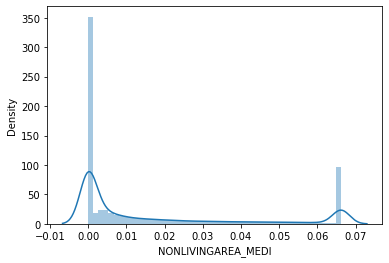

In [ ]:
sns.distplot(data1['NONLIVINGAREA_MEDI'])

In [ ]:
# Hypothesis
# H0: Data is normal
# H1: Data is not normal
    
shapiro(data1['NONLIVINGAREA_MEDI'])

C:\Users\saketh\anaconda3\lib\site-packages\scipy\stats\morestats.py:1681: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


ShapiroResult(statistic=nan, pvalue=1.0)

<AxesSubplot:xlabel='TARGET', ylabel='NONLIVINGAREA_MEDI'>

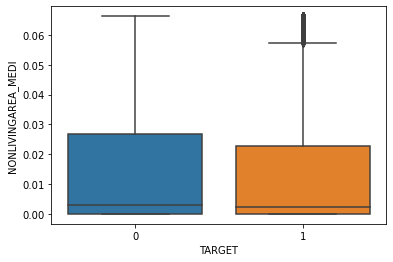

In [ ]:
sns.boxplot(y=data1['NONLIVINGAREA_MEDI'],x=data1['TARGET'])

In [ ]:
stats.ttest_ind(data1['NONLIVINGAREA_MEDI'],data1['TARGET'])

Ttest_indResult(statistic=nan, pvalue=nan)

In [ ]:
# As the parametric test failed going for non parametric test

# Hypothesis
# H0: No relation with the target column
# H1: Relationship exists with the target column

stats.mannwhitneyu(data1['NONLIVINGAREA_MEDI'],data1['TARGET'])

MannwhitneyuResult(statistic=5765048108.5, pvalue=0.0)

### FONDKAPREMONT_MODE - Normalized information about building where the client lives

In [ ]:
data1['FONDKAPREMONT_MODE'].value_counts()

reg oper account         73704
reg oper spec account    12053
not specified             5648
org spec account          5600
Name: FONDKAPREMONT_MODE, dtype: int64

Text(0.5, 0, 'FONDKAPREMONT_MODE')

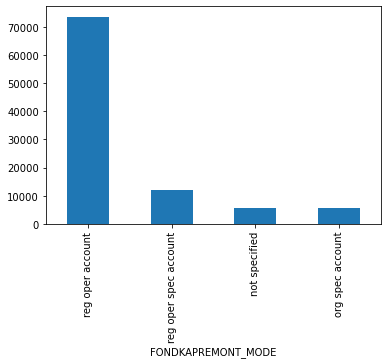

In [ ]:
data1['FONDKAPREMONT_MODE'].value_counts().plot(kind='bar')
plt.xlabel('FONDKAPREMONT_MODE')

<AxesSubplot:xlabel='FONDKAPREMONT_MODE'>

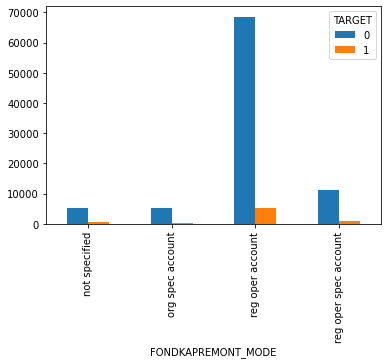

In [ ]:
pd.crosstab(data1['FONDKAPREMONT_MODE'],data1['TARGET']).plot(kind='bar')

In [ ]:
# Checking the relation with the target

# Hypothesis
# H0: No relation with the target column
# H1: Relationship exists with the target column

stats.chi2_contingency(pd.crosstab(data1['FONDKAPREMONT_MODE'],data1['TARGET']))

(16.895269656222315,
 0.0007426716786774431,
 3,
 array([[ 5258.77387764,   389.22612236],
        [ 5214.08174836,   385.91825164],
        [68624.76449668,  5079.23550332],
        [11222.37987733,   830.62012267]]))

### HOUSETYPE_MODE - Normalized information about building where the client lives

In [ ]:
data1['HOUSETYPE_MODE'].value_counts()

block of flats      150503
specific housing      1499
terraced house        1212
Name: HOUSETYPE_MODE, dtype: int64

Text(0.5, 0, 'HOUSETYPE_MODE')

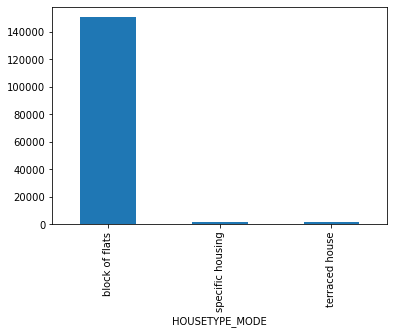

In [ ]:
data1['HOUSETYPE_MODE'].value_counts().plot(kind='bar')
plt.xlabel('HOUSETYPE_MODE')

<AxesSubplot:xlabel='HOUSETYPE_MODE'>

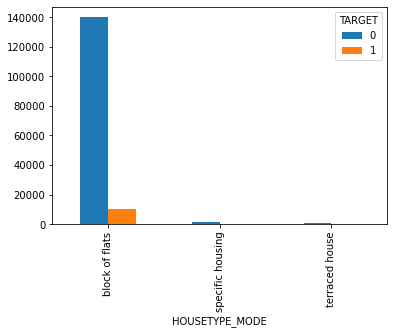

In [ ]:
pd.crosstab(data1['HOUSETYPE_MODE'],data1['TARGET']).plot(kind='bar')

In [ ]:
# Checking the relation with the target

# Hypothesis
# H0: No relation with the target column
# H1: Relationship exists with the target column

stats.chi2_contingency(pd.crosstab(data1['HOUSETYPE_MODE'],data1['TARGET']))

(27.63255609672849,
 9.992328040454538e-07,
 2,
 array([[1.39987416e+05, 1.05155835e+04],
        [1.39426548e+03, 1.04734522e+02],
        [1.12731805e+03, 8.46819481e+01]]))

### TOTALAREA_MODE - Normalized information about building where the client lives

In [ ]:
data1['TOTALAREA_MODE'].value_counts()

0.0000    563
0.0570    243
0.0547    226
0.0548    225
0.0550    222
         ... 
0.5978      1
0.7335      1
0.3563      1
0.5685      1
0.2847      1
Name: TOTALAREA_MODE, Length: 5089, dtype: int64

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='TOTALAREA_MODE', ylabel='Density'>

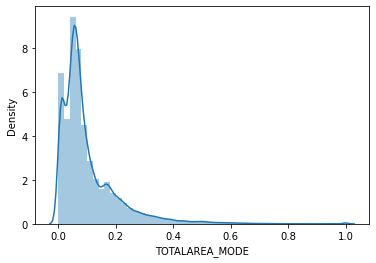

In [ ]:
sns.distplot(data1['TOTALAREA_MODE'])

<AxesSubplot:xlabel='TARGET', ylabel='TOTALAREA_MODE'>

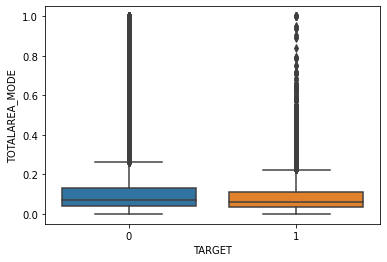

In [ ]:
sns.boxplot(y=data1['TOTALAREA_MODE'],x=data1['TARGET'])

In [ ]:
Q1 = data1['TOTALAREA_MODE'].quantile(0.25)
Q3 = data1['TOTALAREA_MODE'].quantile(0.75)
IQR = Q3-Q1
UB = Q3+1.5*IQR
LB = Q1-1.5*IQR

data1['TOTALAREA_MODE'] = data1['TOTALAREA_MODE'].clip(upper=UB,lower=LB)

<ipython-input-1088-ded2513e48f8>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1['TOTALAREA_MODE'] = data1['TOTALAREA_MODE'].clip(upper=UB,lower=LB)


C:\Users\saketh\anaconda3\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='TOTALAREA_MODE', ylabel='Density'>

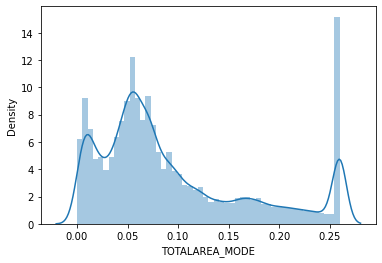

In [ ]:
sns.distplot(data1['TOTALAREA_MODE'])

In [ ]:
# Hypothesis
# H0: Data is normal
# H1: Data is not normal
    
shapiro(data1['TOTALAREA_MODE'])

C:\Users\saketh\anaconda3\lib\site-packages\scipy\stats\morestats.py:1681: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


ShapiroResult(statistic=nan, pvalue=1.0)

<AxesSubplot:xlabel='TARGET', ylabel='TOTALAREA_MODE'>

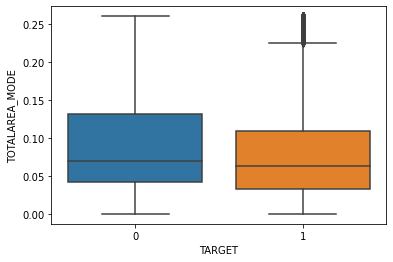

In [ ]:
sns.boxplot(y=data1['TOTALAREA_MODE'],x=data1['TARGET'])

In [ ]:
stats.ttest_ind(data1['TOTALAREA_MODE'],data1['TARGET'])

Ttest_indResult(statistic=nan, pvalue=nan)

In [ ]:
# As the parametric test failed going for non parametric test

# Hypothesis
# H0: No relation with the target column
# H1: Relationship exists with the target column

stats.mannwhitneyu(data1['TOTALAREA_MODE'],data1['TARGET'])

MannwhitneyuResult(statistic=1677692248.5, pvalue=0.0)

### WALLSMATERIAL_MODE - Normalized information about building where the client lives

In [ ]:
data1['WALLSMATERIAL_MODE'].value_counts()

Panel           65351
Stone, brick    63733
Block            9172
Wooden           5247
Mixed            2051
Monolithic       1775
Others           1607
Name: WALLSMATERIAL_MODE, dtype: int64

Text(0.5, 0, 'WALLSMATERIAL_MODE')

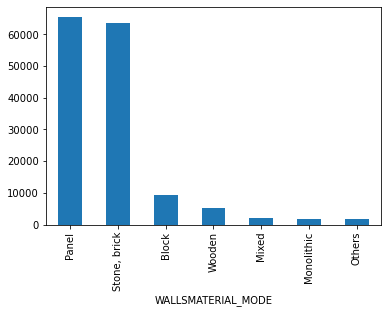

In [ ]:
data1['WALLSMATERIAL_MODE'].value_counts().plot(kind='bar')
plt.xlabel('WALLSMATERIAL_MODE')

<AxesSubplot:xlabel='WALLSMATERIAL_MODE'>

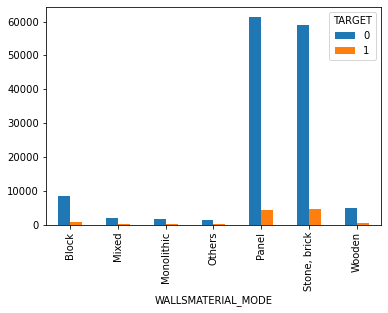

In [ ]:
pd.crosstab(data1['WALLSMATERIAL_MODE'],data1['TARGET']).plot(kind='bar')

In [ ]:
# Checking the relation with the target

# Hypothesis
# H0: No relation with the target column
# H1: Relationship exists with the target column

stats.chi2_contingency(pd.crosstab(data1['WALLSMATERIAL_MODE'],data1['TARGET']))

(134.29613375498337,
 1.5993211291578217e-26,
 6,
 array([[ 8532.64011387,   639.35988613],
        [ 1908.0293146 ,   142.9706854 ],
        [ 1651.26866574,   123.73133426],
        [ 1494.97957512,   112.02042488],
        [60795.52595746,  4555.47404254],
        [59290.31316807,  4442.68683193],
        [ 4881.24320514,   365.75679486]]))

### EMERGENCYSTATE_MODE - Normalized information about building where the client lives

In [ ]:
data1['EMERGENCYSTATE_MODE'].value_counts()

No     150931
Yes      2283
Name: EMERGENCYSTATE_MODE, dtype: int64

Text(0.5, 0, 'EMERGENCYSTATE_MODE')

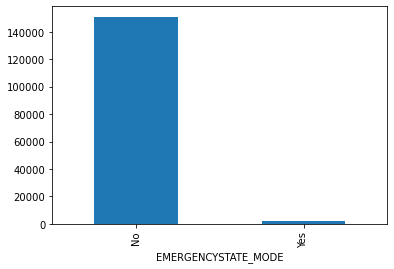

In [ ]:
data1['EMERGENCYSTATE_MODE'].value_counts().plot(kind='bar')
plt.xlabel('EMERGENCYSTATE_MODE')

<AxesSubplot:xlabel='EMERGENCYSTATE_MODE'>

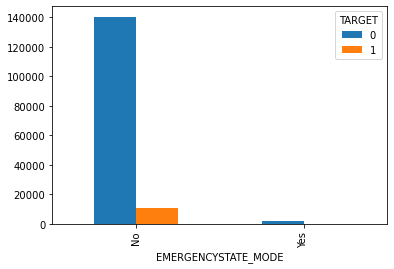

In [ ]:
pd.crosstab(data1['EMERGENCYSTATE_MODE'],data1['TARGET']).plot(kind='bar')

In [ ]:
# Checking the relation with the target

# Hypothesis
# H0: No relation with the target column
# H1: Relationship exists with the target column

stats.chi2_contingency(pd.crosstab(data1['EMERGENCYSTATE_MODE'],data1['TARGET']))

(24.62105672757605,
 6.978501840546536e-07,
 1,
 array([[140385.51228347,  10545.48771653],
        [  2123.48771653,    159.51228347]]))

# Saketh , Nitish , Kedar , Nikhil

In [ ]:
subset = data1.iloc[:,44:72]

In [ ]:
subset.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 153214 entries, 0 to 307510
Data columns (total 28 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   APARTMENTS_AVG                149427 non-null  float64
 1   BASEMENTAREA_AVG              126295 non-null  float64
 2   YEARS_BEGINEXPLUATATION_AVG   152335 non-null  float64
 3   YEARS_BUILD_AVG               102733 non-null  float64
 4   COMMONAREA_AVG                92442 non-null   float64
 5   ELEVATORS_AVG                 142080 non-null  float64
 6   ENTRANCES_AVG                 149933 non-null  float64
 7   FLOORSMAX_AVG                 151487 non-null  float64
 8   FLOORSMIN_AVG                 98624 non-null   float64
 9   LANDAREA_AVG                  124398 non-null  float64
 10  LIVINGAPARTMENTS_AVG          97071 non-null   float64
 11  LIVINGAREA_AVG                148447 non-null  float64
 12  NONLIVINGAPARTMENTS_AVG       93805 non-null

In [ ]:
subset.isnull().sum()*100/len(subset)

APARTMENTS_AVG                   2.471706
BASEMENTAREA_AVG                17.569543
YEARS_BEGINEXPLUATATION_AVG      0.573707
YEARS_BUILD_AVG                 32.948033
COMMONAREA_AVG                  39.664783
ELEVATORS_AVG                    7.266960
ENTRANCES_AVG                    2.141449
FLOORSMAX_AVG                    1.127182
FLOORSMIN_AVG                   35.629903
LANDAREA_AVG                    18.807681
LIVINGAPARTMENTS_AVG            36.643518
LIVINGAREA_AVG                   3.111334
NONLIVINGAPARTMENTS_AVG         38.775177
NONLIVINGAREA_AVG               11.006174
APARTMENTS_MODE                  2.471706
BASEMENTAREA_MODE               17.569543
YEARS_BEGINEXPLUATATION_MODE     0.573707
YEARS_BUILD_MODE                32.948033
COMMONAREA_MODE                 39.664783
ELEVATORS_MODE                   7.266960
ENTRANCES_MODE                   2.141449
FLOORSMAX_MODE                   1.127182
FLOORSMIN_MODE                  35.629903
LANDAREA_MODE                   18

In [ ]:
subset.describe()

,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,...,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE
count,149427.000000,126295.000000,152335.000000,102733.000000,92442.000000,142080.000000,149933.000000,151487.000000,98624.000000,124398.000000,...,92442.000000,142080.000000,149933.000000,151487.000000,98624.000000,124398.000000,97071.000000,148447.000000,93805.000000,136351.000000
mean,0.117926,0.088529,0.977782,0.752584,0.044657,0.078957,0.150089,0.226943,0.232034,0.066398,...,0.042588,0.074484,0.145515,0.222951,0.228189,0.065016,0.105705,0.106716,0.008078,0.026959
std,0.108486,0.082558,0.059253,0.113217,0.076052,0.134781,0.100347,0.144717,0.161400,0.081237,...,0.074457,0.132432,0.101293,0.143810,0.161183,0.081802,0.097870,0.112472,0.046303,0.070146
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.057700,0.044200,0.976700,0.687200,0.007900,0.000000,0.069000,0.166700,0.083300,0.018725,...,0.007200,0.000000,0.069000,0.166700,0.083300,0.016600,0.054200,0.043300,0.000000,0.000000
50%,0.087600,0.076400,0.982100,0.755200,0.021100,0.000000,0.137900,0.166700,0.208300,0.048200,...,0.019100,0.000000,0.137900,0.166700,0.208300,0.045900,0.077100,0.073300,0.000000,0.001100
75%,0.148500,0.112300,0.987100,0.823200,0.051500,0.120000,0.206900,0.333300,0.375000,0.085700,...,0.049000,0.120800,0.206900,0.333300,0.375000,0.084100,0.131300,0.125700,0.003900,0.023000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


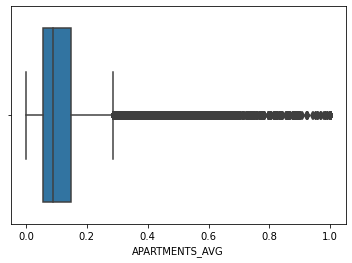

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


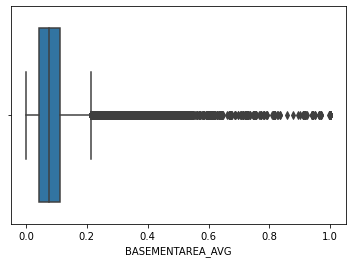

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


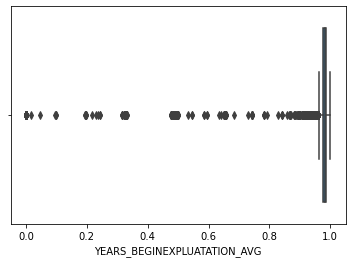

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


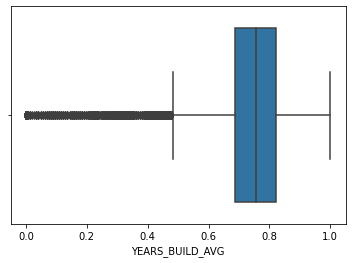

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


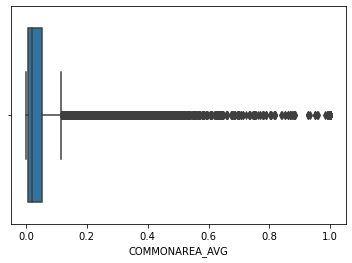

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


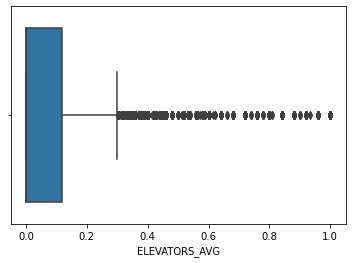

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


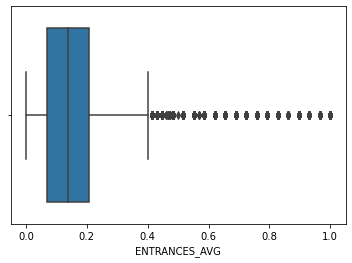

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


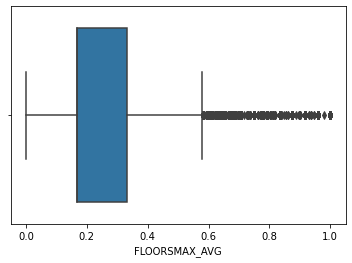

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


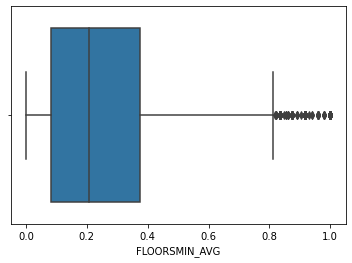

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


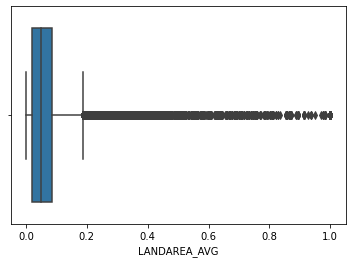

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


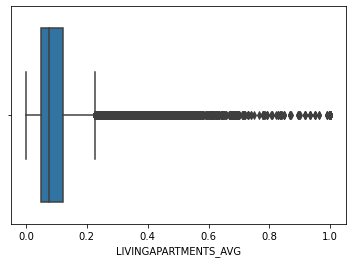

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


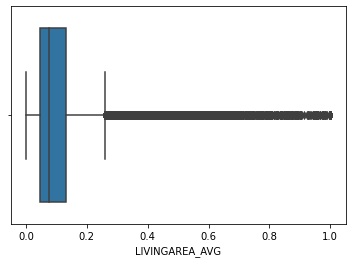

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


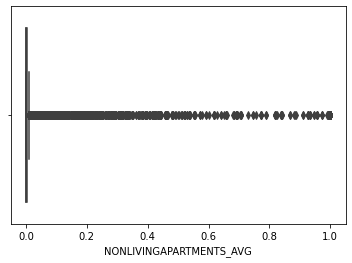

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


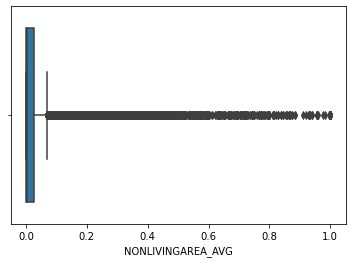

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


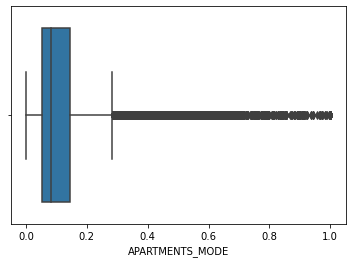

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


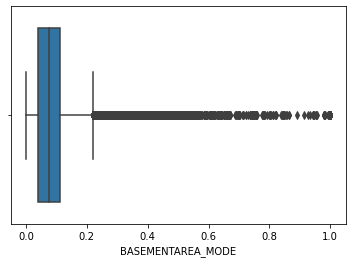

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


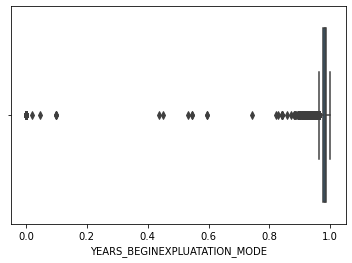

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


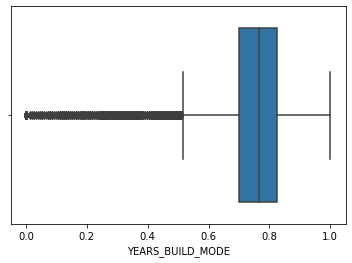

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


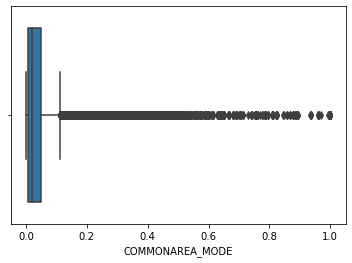

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


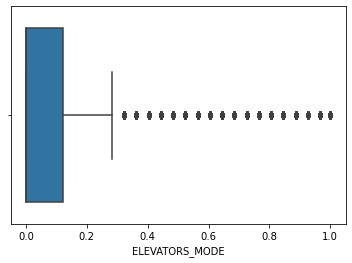

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


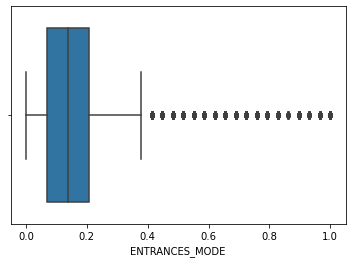

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


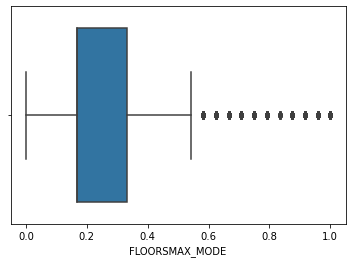

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


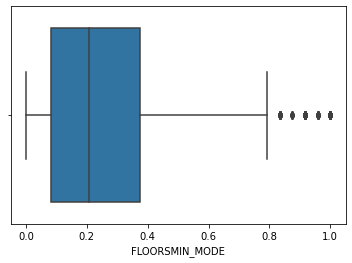

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


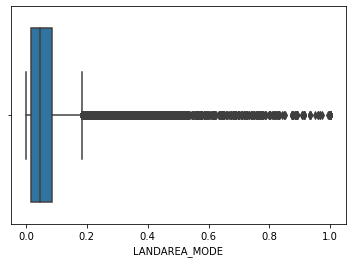

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


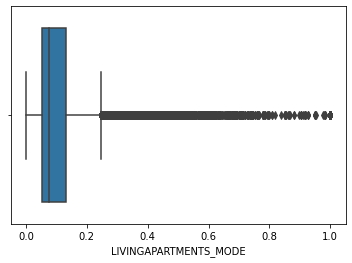

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


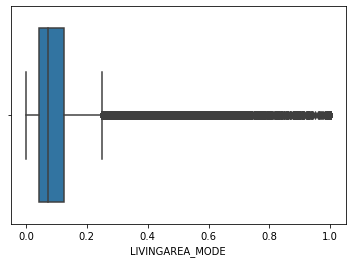

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


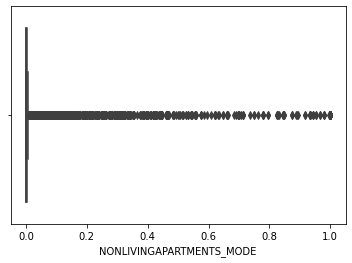

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


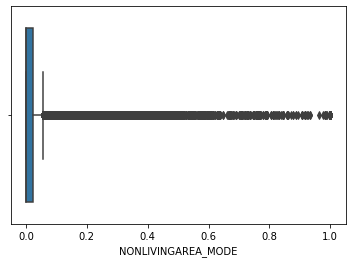

In [ ]:
for i in subset.columns:
    sns.boxplot(data1[i])
    plt.show()

In [ ]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer()

In [ ]:
for i in subset.columns:
    data1[i] = pt.fit_transform(data1[[i]])
    
    

<ipython-input-1108-b96f763cd1ad>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1[i] = pt.fit_transform(data1[[i]])
<ipython-input-1108-b96f763cd1ad>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1[i] = pt.fit_transform(data1[[i]])
<ipython-input-1108-b96f763cd1ad>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stab

<ipython-input-1108-b96f763cd1ad>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1[i] = pt.fit_transform(data1[[i]])
<ipython-input-1108-b96f763cd1ad>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1[i] = pt.fit_transform(data1[[i]])
<ipython-input-1108-b96f763cd1ad>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stab

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


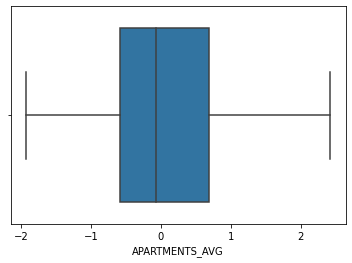

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


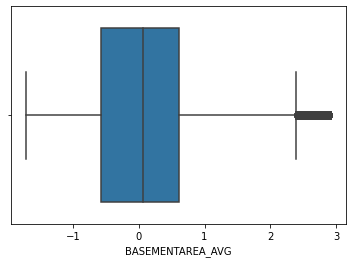

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


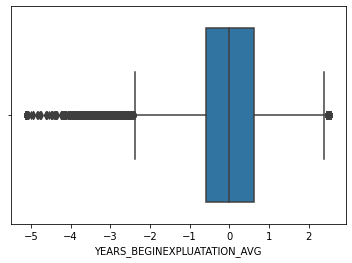

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


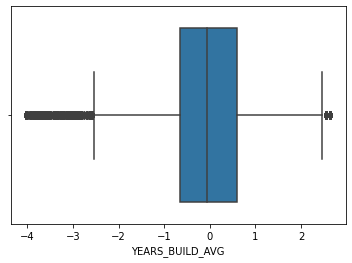

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


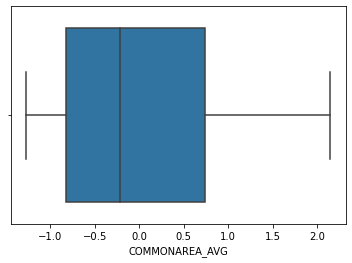

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


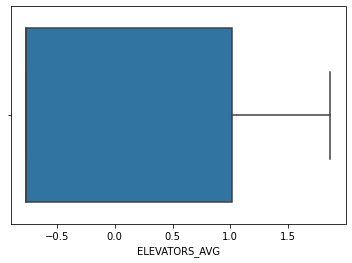

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


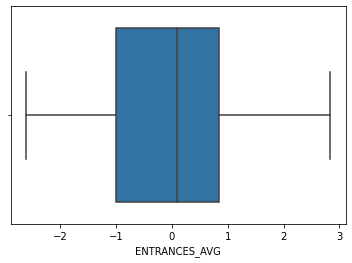

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


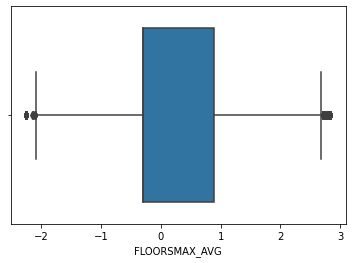

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


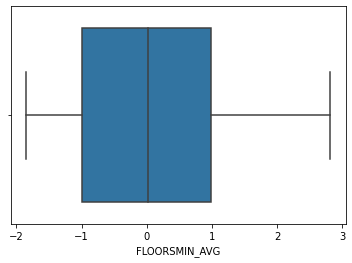

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


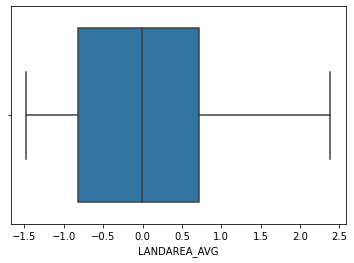

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


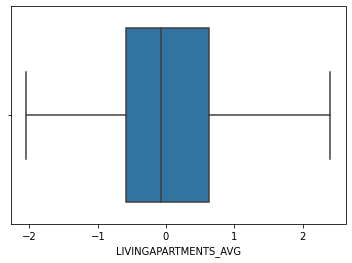

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


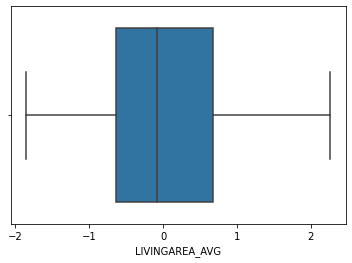

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


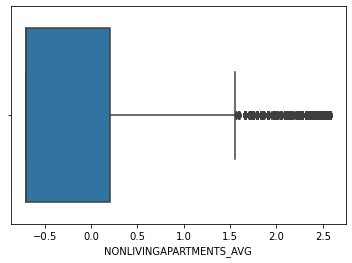

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


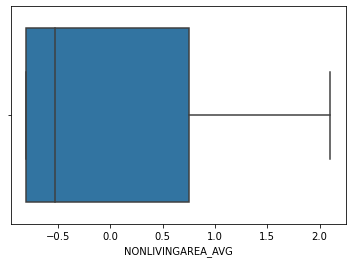

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


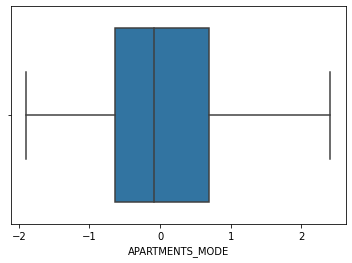

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


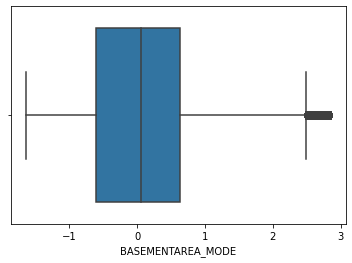

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


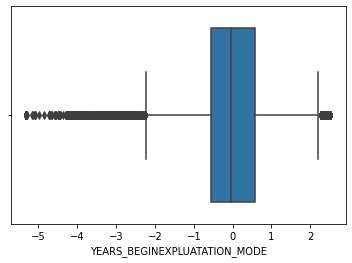

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


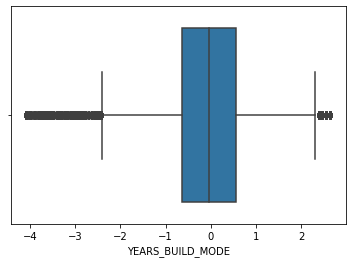

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


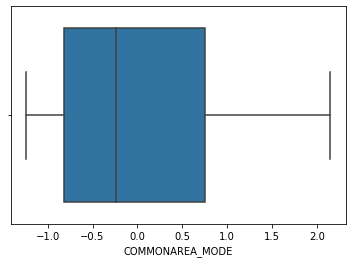

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


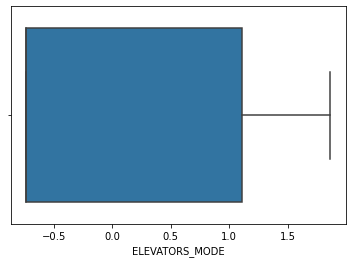

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


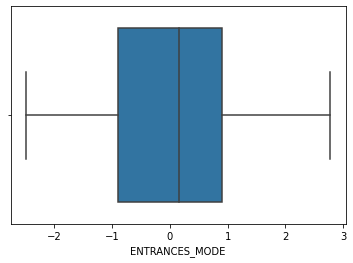

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


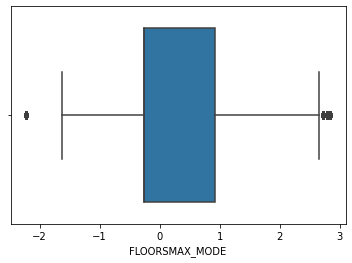

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


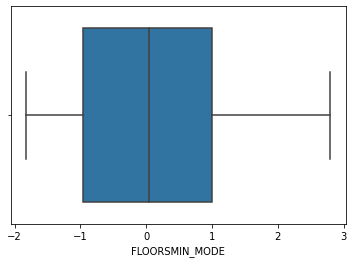

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


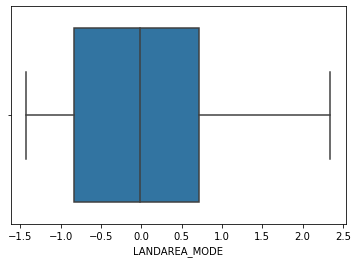

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


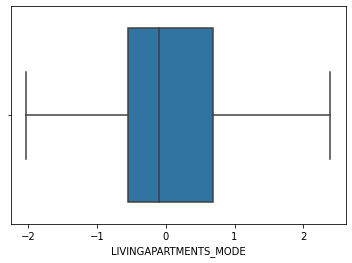

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


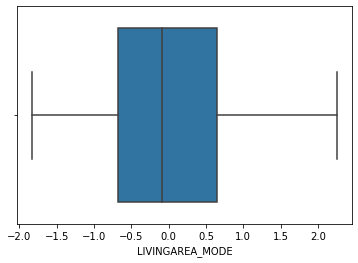

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


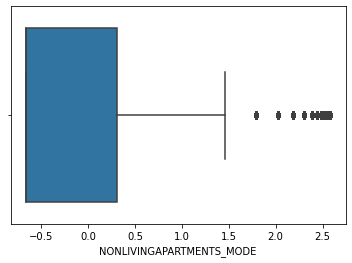

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


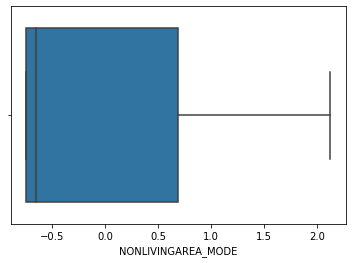

In [ ]:
for i in subset.columns:
    sns.boxplot(data1[i])
    plt.show()

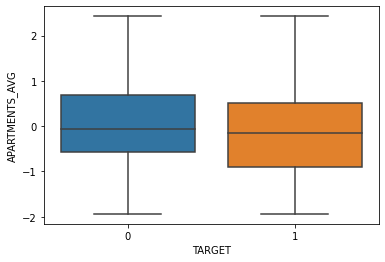

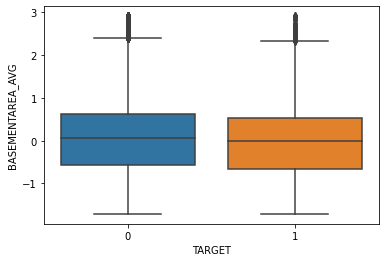

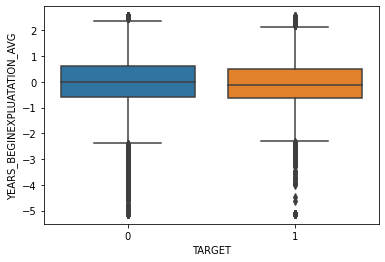

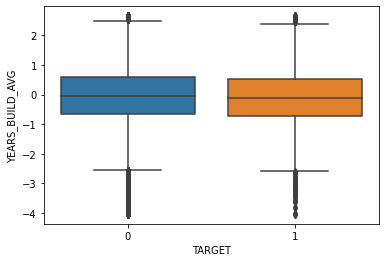

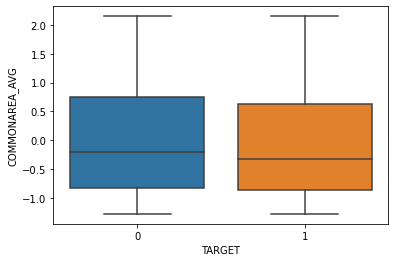

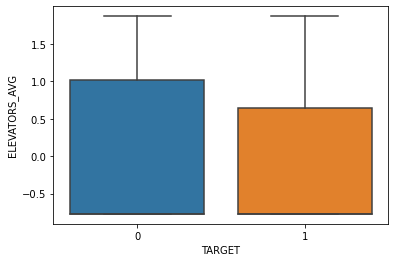

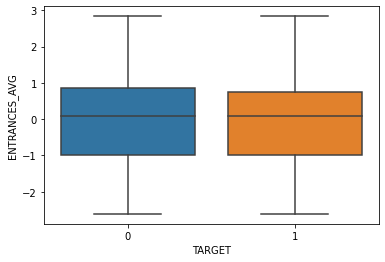

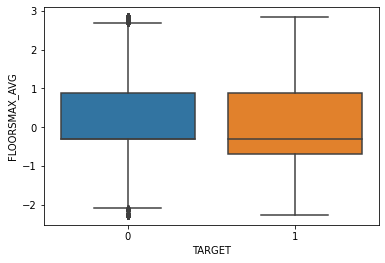

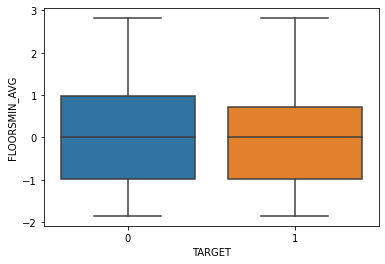

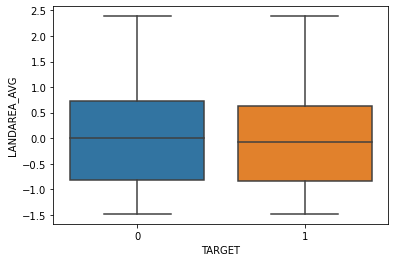

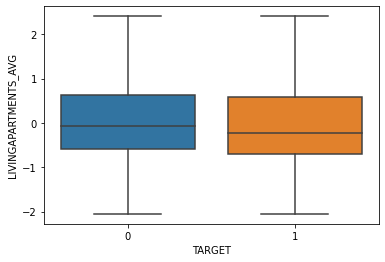

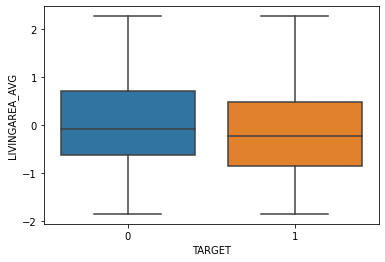

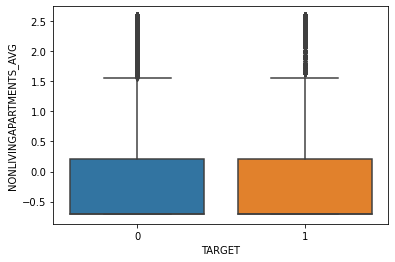

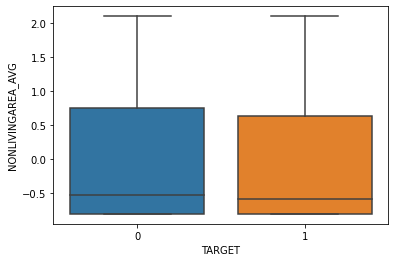

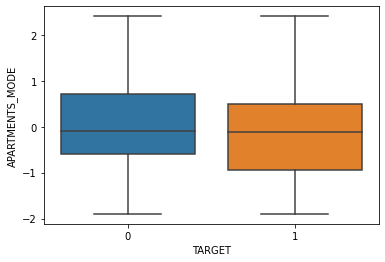

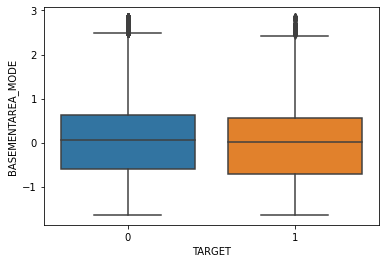

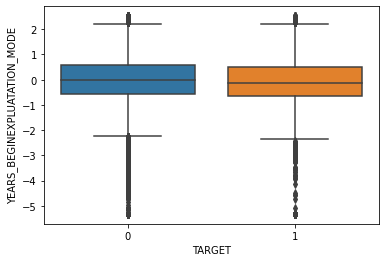

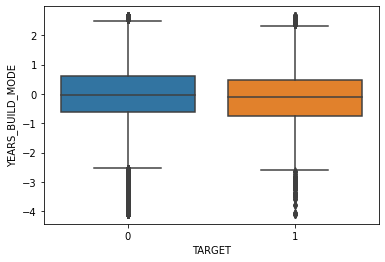

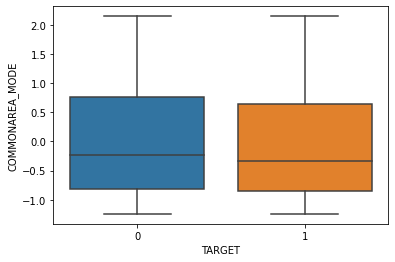

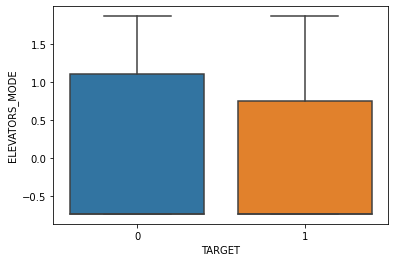

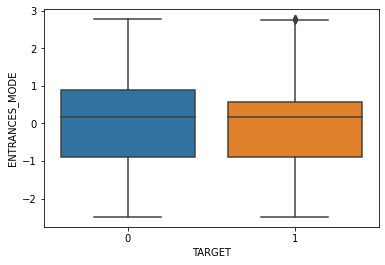

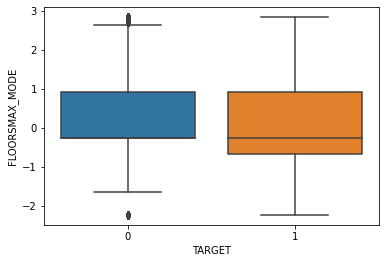

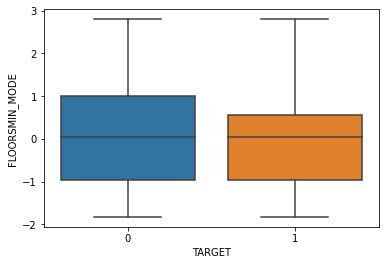

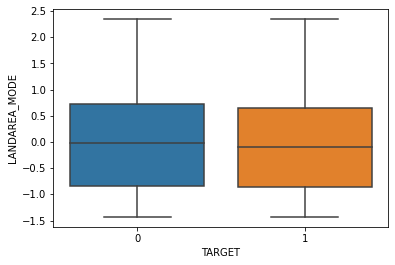

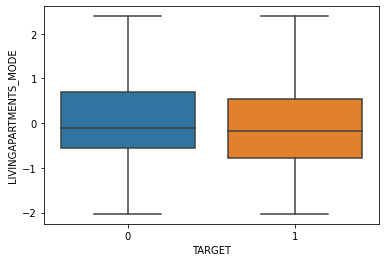

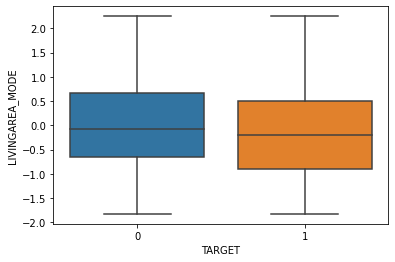

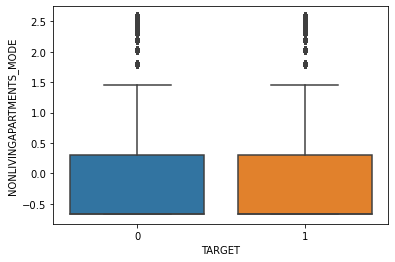

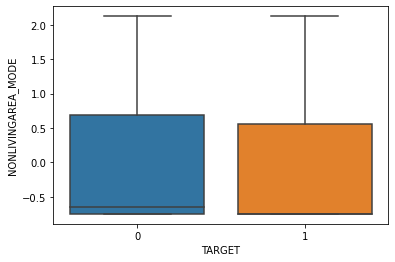

In [ ]:
for i in subset.columns:
    sns.boxplot(y = data1[i] ,x = data1['TARGET'] )
    plt.show()

In [ ]:
data1['TARGET'].value_counts(normalize = True)*100

0    93.013041
1     6.986959
Name: TARGET, dtype: float64

In [ ]:
null_value = subset.isnull().sum()*100/len(data1)

In [ ]:
null_cols = null_value[null_value>25].index
null_cols

Index(['YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'FLOORSMIN_AVG',
       'LIVINGAPARTMENTS_AVG', 'NONLIVINGAPARTMENTS_AVG', 'YEARS_BUILD_MODE',
       'COMMONAREA_MODE', 'FLOORSMIN_MODE', 'LIVINGAPARTMENTS_MODE',
       'NONLIVINGAPARTMENTS_MODE'],
      dtype='object')

In [ ]:
data1.drop(null_cols , axis = 1 , inplace = True) # to be dropped because null value percentage is greater than 25 
# percent
data1.shape

C:\Users\saketh\anaconda3\lib\site-packages\pandas\core\frame.py:4163: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().drop(


(153214, 112)

In [ ]:
default = data1[data1['TARGET']==0]
non_default = data1[data1['TARGET']==1]

In [ ]:
subset.drop(null_cols , axis = 1 , inplace = True)

In [ ]:
import scipy.stats as stats

In [ ]:
p_values=[]
for i in subset.columns:
    s , p = stats.shapiro(default[i])
    if p>0.05:
        stat , p_val = stats.mannwhitneyu(default[i] , non_default[i])
        p_values.append(p_val)
    else:
        s1 , p1 = stats.shapiro(non_default[i])
        if p1>0.05:
            stat , p_val = stats.mannwhitneyu(default[i] , non_default[i])
            p_values.append(p_val)
        else:
            s2 , p2 = stats.levene(default[i] , non_default[i])
            if p2 > 0.05:
                stat , p_val = stats.mannwhitneyu(default[i] , non_default[i])
                p_values.append(p_val)
            else:
                stat , p_val = stats.ttest_ind(default[i] , non_default[i])
                p_values.append(p_val)
pd.DataFrame(p_values , index = subset.columns , columns =['P_VALUE'])
            
                
            

C:\Users\saketh\anaconda3\lib\site-packages\scipy\stats\morestats.py:1681: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


,P_VALUE
APARTMENTS_AVG,2.446654e-34
BASEMENTAREA_AVG,6.087194e-20
YEARS_BEGINEXPLUATATION_AVG,5.688815e-27
ELEVATORS_AVG,5.037099e-29
ENTRANCES_AVG,8.950589e-15
FLOORSMAX_AVG,5.828705e-64
LANDAREA_AVG,1.864350e-19
LIVINGAREA_AVG,1.681390e-52
NONLIVINGAREA_AVG,6.508986e-05
APARTMENTS_MODE,1.306533e-30


In [ ]:
# from the table above , we can see that p values for all the variable are below the 0.05 cutoff , Hence they are 
# significantly related to the TARGET column

<AxesSubplot:>

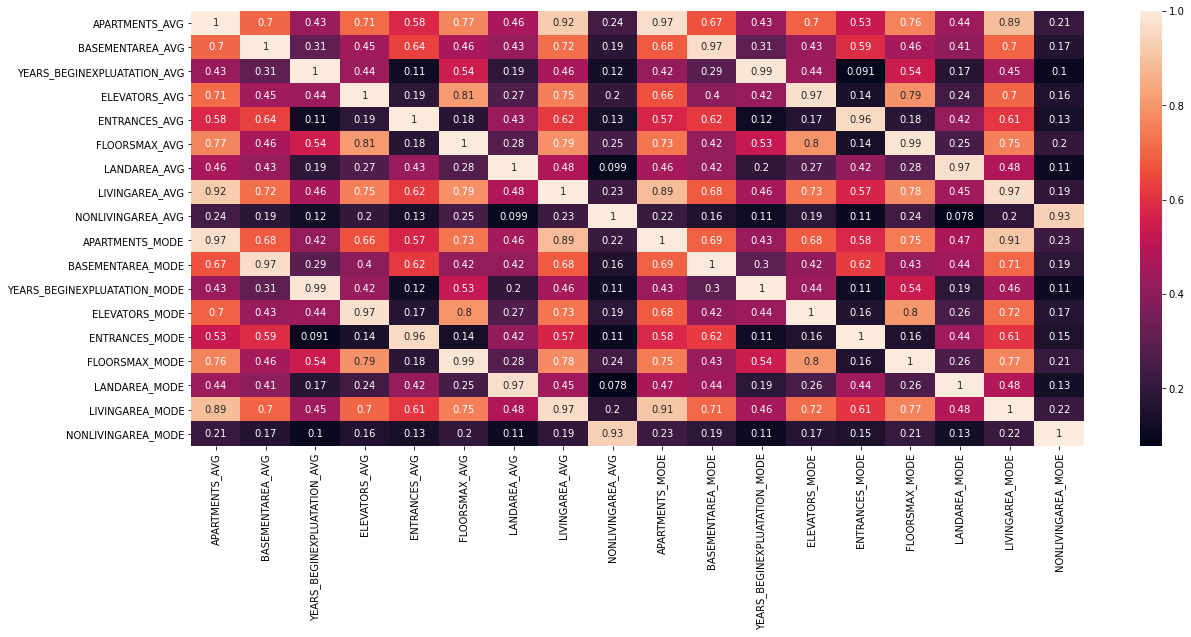

In [ ]:
plt.figure(figsize=(20,8))
sns.heatmap(data1[subset.columns].corr(),annot=True)

In [ ]:
dff=data1.drop('SK_ID_CURR',axis=1)

In [ ]:
data1.index

Int64Index([     0,      1,     12,     13,     14,     18,     20,     22,
                23,     24,
            ...
            307495, 307498, 307500, 307501, 307505, 307506, 307507, 307508,
            307509, 307510],
           dtype='int64', length=153214)

In [ ]:
dff.index = np.arange(len(data1))

In [ ]:
dff.index

Int64Index([     0,      1,      2,      3,      4,      5,      6,      7,
                 8,      9,
            ...
            153204, 153205, 153206, 153207, 153208, 153209, 153210, 153211,
            153212, 153213],
           dtype='int64', length=153214)

In [ ]:
dff.info(max_cols = 150)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 153214 entries, 0 to 153213
Data columns (total 111 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   TARGET                        153214 non-null  int64  
 1   NAME_CONTRACT_TYPE            153214 non-null  object 
 2   CODE_GENDER                   153214 non-null  object 
 3   FLAG_OWN_CAR                  153214 non-null  object 
 4   FLAG_OWN_REALTY               153214 non-null  object 
 5   CNT_CHILDREN                  153214 non-null  int64  
 6   AMT_INCOME_TOTAL              153214 non-null  float64
 7   AMT_CREDIT                    153214 non-null  float64
 8   AMT_ANNUITY                   153208 non-null  float64
 9   AMT_GOODS_PRICE               153085 non-null  float64
 10  NAME_TYPE_SUITE               152527 non-null  object 
 11  NAME_INCOME_TYPE              153214 non-null  object 
 12  NAME_EDUCATION_TYPE           153214 non-nu

In [ ]:
dff.shape

(153214, 111)

In [ ]:
dff['TARGET'].value_counts(normalize = True)*100

0    93.013041
1     6.986959
Name: TARGET, dtype: float64

### NAME_CONTRACT_TYPE , CODE_GENDER ,FLAG_OWN_CAR , FLAG_OWN_REALTY, CNT_CHILDREN, AMT_INCOME_TOTAL  OWN CAR AGE

# Name Contract Type 
### Identification if loan is cash or revolving

In [ ]:
dff['NAME_CONTRACT_TYPE'].isnull().sum()

0

In [ ]:
dff['NAME_CONTRACT_TYPE'].value_counts()

Cash loans         137401
Revolving loans     15813
Name: NAME_CONTRACT_TYPE, dtype: int64

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='NAME_CONTRACT_TYPE', ylabel='count'>

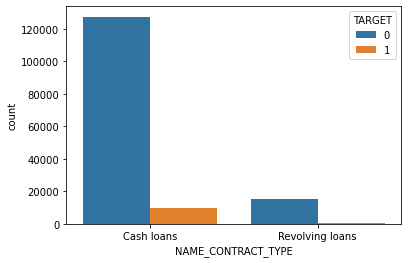

In [ ]:
sns.countplot(dff['NAME_CONTRACT_TYPE'] , hue = dff['TARGET'])

In [ ]:
default = dff[dff['TARGET']==1]

In [ ]:
default['NAME_CONTRACT_TYPE'].value_counts()*100/dff['NAME_CONTRACT_TYPE'].value_counts()

Cash loans         7.266323
Revolving loans    4.559540
Name: NAME_CONTRACT_TYPE, dtype: float64

Text(0.5, 1.0, 'Percentage of defaulters')

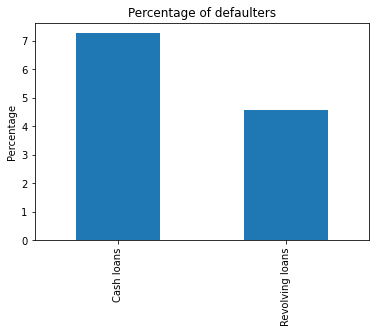

In [ ]:
(default['NAME_CONTRACT_TYPE'].value_counts()*100/dff['NAME_CONTRACT_TYPE'].value_counts()).plot(kind='bar') 
plt.ylabel('Percentage')
plt.title('Percentage of defaulters')
# percentage defaulters in each category 

In [ ]:
loan_table = pd.crosstab(dff['TARGET'] , dff['NAME_CONTRACT_TYPE'])

In [ ]:
stats.chi2_contingency(loan_table)

(159.45876061054523,
 1.4856066631495262e-36,
 1,
 array([[127800.84789249,  14708.15210751],
        [  9600.15210751,   1104.84789249]]))

In [ ]:
# Ho: The features are independent
# Ha: The features are dependent i.e significant relationship between the features

In [ ]:
# we can see that p value is very very less (of the order of -65) and hence < 0.05. Hence we 
# reject null. Thus there is a significant relationship between the two columns

# CODE GENDER
### Gender of the client

In [ ]:
dff['CODE_GENDER'].isnull().sum()

0

In [ ]:
dff['CODE_GENDER'].value_counts()

F      102899
M       50312
XNA         3
Name: CODE_GENDER, dtype: int64

In [ ]:
dff[dff['CODE_GENDER']=='XNA'] # should impute this using KNN or other imputation techniques

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
19197,0,Revolving loans,XNA,N,Y,2,157500.0,270000.0,13500.0,225000.0,...,0,0,0,0,0.0,0.0,0.0,3.0,0.0,4.0
41557,0,Revolving loans,XNA,N,Y,1,135000.0,405000.0,20250.0,225000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
94357,0,Revolving loans,XNA,Y,Y,0,247500.0,540000.0,27000.0,900000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,6.0


In [ ]:
dff['CODE_GENDER'].mode()

0    F
dtype: object

In [ ]:
dff['CODE_GENDER'] = dff['CODE_GENDER'].apply(lambda x: dff['CODE_GENDER'].mode()[0] if x =='XNA' else x)


In [ ]:
default['CODE_GENDER'].value_counts()*100/len(default)

F    58.047641
M    41.952359
Name: CODE_GENDER, dtype: float64

In [ ]:
(default['CODE_GENDER'].value_counts()*100/dff['CODE_GENDER'].value_counts())

F    6.038755
M    8.926300
Name: CODE_GENDER, dtype: float64

Text(0, 0.5, 'Percentage')

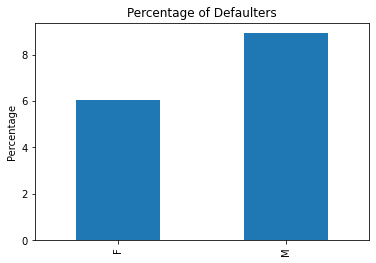

In [ ]:
(default['CODE_GENDER'].value_counts()*100/dff['CODE_GENDER'].value_counts()).plot(kind='bar')
plt.title('Percentage of Defaulters')
plt.ylabel('Percentage')

In [ ]:
gender_table = pd.crosstab(dff['TARGET'] ,dff['CODE_GENDER'])

In [ ]:
stats.chi2_contingency(gender_table)

(433.0889082803211,
 3.456152929048882e-96,
 1,
 array([[95712.2790215, 46796.7209785],
        [ 7189.7209785,  3515.2790215]]))

In [ ]:
# we can see that p value is very very less (of the order of -200) and hence < 0.05. Hence we 
# reject null. Thus there is a significant relationship between the two columns

# AMT_INCOME_TOTAL
### Income of the client

In [ ]:
dff['AMT_INCOME_TOTAL'].isnull().sum()

0

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='AMT_INCOME_TOTAL', ylabel='Density'>

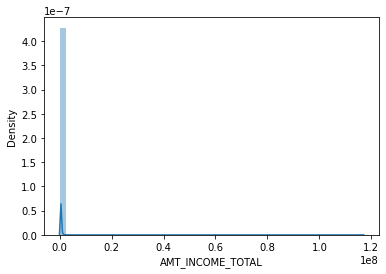

In [ ]:
sns.distplot(dff['AMT_INCOME_TOTAL'])

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='AMT_INCOME_TOTAL'>

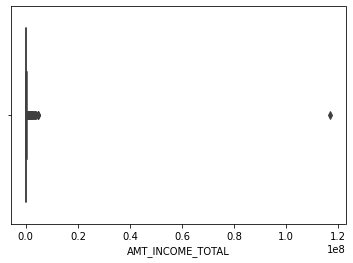

In [ ]:
sns.boxplot(dff['AMT_INCOME_TOTAL'])

In [ ]:
dff['AMT_INCOME_TOTAL'].skew()

326.57747189297675

In [ ]:
# we can see that this column is very heavily right skewed . Hence we perform log transformation

In [ ]:
dff.info(max_cols = 120)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 153214 entries, 0 to 153213
Data columns (total 111 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   TARGET                        153214 non-null  int64  
 1   NAME_CONTRACT_TYPE            153214 non-null  object 
 2   CODE_GENDER                   153214 non-null  object 
 3   FLAG_OWN_CAR                  153214 non-null  object 
 4   FLAG_OWN_REALTY               153214 non-null  object 
 5   CNT_CHILDREN                  153214 non-null  int64  
 6   AMT_INCOME_TOTAL              153214 non-null  float64
 7   AMT_CREDIT                    153214 non-null  float64
 8   AMT_ANNUITY                   153208 non-null  float64
 9   AMT_GOODS_PRICE               153085 non-null  float64
 10  NAME_TYPE_SUITE               152527 non-null  object 
 11  NAME_INCOME_TYPE              153214 non-null  object 
 12  NAME_EDUCATION_TYPE           153214 non-nu

In [ ]:
dff['LOG_AMT_INCOME_TOTAL'] = np.log(dff['AMT_INCOME_TOTAL'])

In [ ]:
dff['LOG_AMT_INCOME_TOTAL'].skew()

0.2250166297334278

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='LOG_AMT_INCOME_TOTAL', ylabel='Density'>

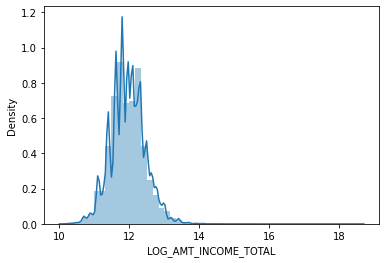

In [ ]:
sns.distplot(dff['LOG_AMT_INCOME_TOTAL'])

In [ ]:
default = dff[dff['TARGET']==1]
non_default = dff[dff['TARGET']==0]

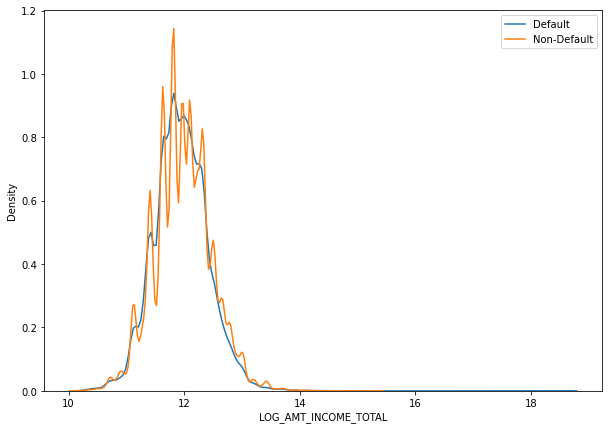

In [ ]:
plt.figure(figsize = (10,7))
sns.kdeplot(default['LOG_AMT_INCOME_TOTAL'])
sns.kdeplot(non_default['LOG_AMT_INCOME_TOTAL'])
plt.legend(['Default','Non-Default'])

<AxesSubplot:xlabel='TARGET', ylabel='LOG_AMT_INCOME_TOTAL'>

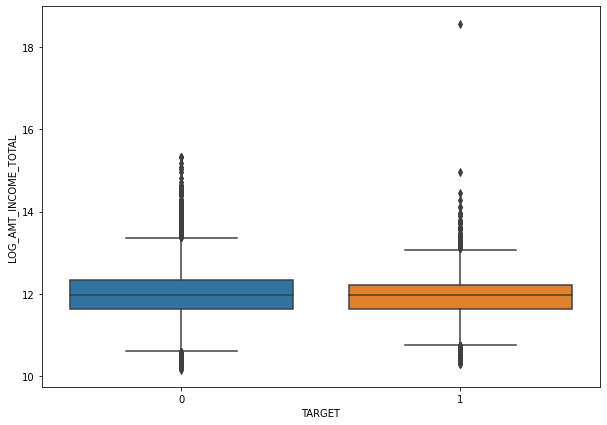

In [ ]:
plt.figure(figsize =(10,7))
sns.boxplot(y = dff['LOG_AMT_INCOME_TOTAL'], x = dff['TARGET'])

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='LOG_AMT_INCOME_TOTAL'>

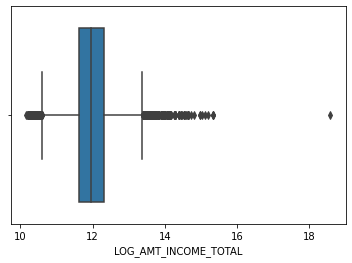

In [ ]:
sns.boxplot(dff['LOG_AMT_INCOME_TOTAL'])

In [ ]:
# we can see that datapoints are densely located right after the whisker lines on both sides. Hence we can increase our range to include 
# these points as well.

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='LOG_AMT_INCOME_TOTAL'>

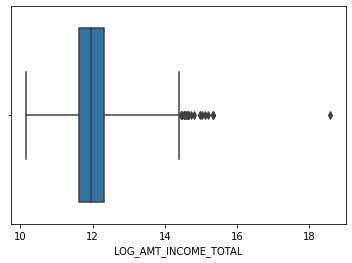

In [ ]:
sns.boxplot(dff['LOG_AMT_INCOME_TOTAL'] , whis = 3 )

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='LOG_AMT_INCOME_TOTAL'>

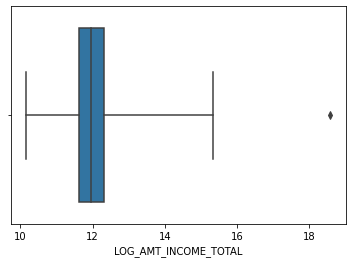

In [ ]:
sns.boxplot(dff['LOG_AMT_INCOME_TOTAL'] , whis = 5)

In [ ]:
# we can see that most of the densely located outliers have been included with whisker as 5. Hence we take the upper limit and lower
#Limit as follows


In [ ]:
q1 = dff['LOG_AMT_INCOME_TOTAL'].quantile(0.25)
q3 = dff['LOG_AMT_INCOME_TOTAL'].quantile(0.75)
iqr =  q3 - q1
ul = q3 + (5*iqr)
ll = q1 - (5*iqr)



In [ ]:
dff[ (dff['LOG_AMT_INCOME_TOTAL'] < ll) | (dff['LOG_AMT_INCOME_TOTAL'] > ul) ]

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,LOG_AMT_INCOME_TOTAL
6445,1,Cash loans,F,N,Y,1,117000000.0,562491.0,26194.5,454500.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,18.577684


In [ ]:
# these 10 rows are our outliers. 

In [ ]:
print(ll, ul)

8.164972597826885 15.789591583986285


In [ ]:
dff['LOG_AMT_INCOME_TOTAL'] = dff['LOG_AMT_INCOME_TOTAL'].clip(lower = ll , upper = ul) # capping the outliers with ul and ll

In [ ]:
# Ho: columns are independent
# Ha: columns have significant relationship


In [ ]:
# 2 sample test target vs log_amt_income_total

In [ ]:
default_inc = dff[dff['TARGET']==1]['LOG_AMT_INCOME_TOTAL']
non_default_inc = dff[dff['TARGET']==0]['LOG_AMT_INCOME_TOTAL']

In [ ]:
len(default_inc)

10705

In [ ]:
len(non_default_inc)

142509

In [ ]:
sample_non_default = pd.Series(np.random.choice(non_default_inc , size = len(default_inc), replace = False))

In [ ]:
sample_non_default

0        12.372646
1        12.506177
2        11.407565
3        12.100712
4        11.547327
           ...    
10700    11.967181
10701    12.100712
10702    12.911642
10703    11.845820
10704    12.100712
Length: 10705, dtype: float64

In [ ]:
stats.levene(default_inc , sample_non_default)
# variances arent same

LeveneResult(statistic=31.040334726164303, pvalue=2.5576131890053558e-08)

In [ ]:
stats.shapiro(default_inc)

C:\Users\saketh\anaconda3\lib\site-packages\scipy\stats\morestats.py:1681: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


ShapiroResult(statistic=0.9875401258468628, pvalue=1.489803559870577e-29)

In [ ]:
stats.shapiro(sample_non_default)
# data is not normal

ShapiroResult(statistic=0.9900017380714417, pvalue=9.975212398509781e-27)

In [ ]:
len(default_inc)

10705

In [ ]:
len(sample_non_default)

10705

In [ ]:
stats.mannwhitneyu(default_inc , sample_non_default)

MannwhitneyuResult(statistic=55079198.5, pvalue=4.3153997871491316e-07)

In [ ]:
# p_value is less than 0.05. thus , there is significant relationship between target and total_income

In [ ]:
stats.kruskal(default_inc , non_default_inc)

KruskalResult(statistic=53.040740260260655, pvalue=3.2670147879457373e-13)

# FLAG_OWN_CAR
### Flag if the client owns a car

In [ ]:
dff['FLAG_OWN_CAR'].isnull().sum()

0

In [ ]:
dff['FLAG_OWN_CAR'].value_counts() # need to convert the data to 0 and 1

N    103533
Y     49681
Name: FLAG_OWN_CAR, dtype: int64

In [ ]:
bp = default['FLAG_OWN_CAR'].value_counts()*100/dff['FLAG_OWN_CAR'].value_counts()
bp

N    7.340655
Y    6.249874
Name: FLAG_OWN_CAR, dtype: float64

Text(0, 0.5, 'Percentage')

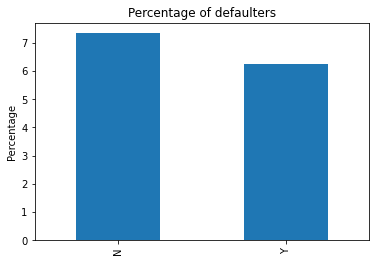

In [ ]:
bp.plot(kind='bar')
plt.title('Percentage of defaulters')
plt.ylabel('Percentage')

<AxesSubplot:xlabel='TARGET', ylabel='count'>

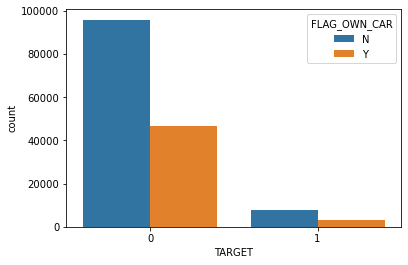

In [ ]:
sns.countplot(x = dff['TARGET'] , hue= dff['FLAG_OWN_CAR'])

In [ ]:
car = pd.crosstab(dff['TARGET'] ,dff['FLAG_OWN_CAR'])

In [ ]:
stats.chi2_contingency(car)

(61.29520982350473,
 4.912741305102576e-15,
 1,
 array([[96299.19130758, 46209.80869242],
        [ 7233.80869242,  3471.19130758]]))

In [ ]:
# p value less than 0.05., hence the feature has significant relationship with TARGET

# FLAG_OWN_REALTY
### Flag if client owns a house or flat

In [ ]:
dff['FLAG_OWN_REALTY'].isnull().sum()

0

In [ ]:
dff['FLAG_OWN_REALTY'].value_counts()

Y    107781
N     45433
Name: FLAG_OWN_REALTY, dtype: int64

In [ ]:
realty = dff[dff['TARGET']==1]['FLAG_OWN_REALTY'].value_counts()*100/dff['FLAG_OWN_REALTY'].value_counts()
realty

Y    6.906598
N    7.177602
Name: FLAG_OWN_REALTY, dtype: float64

Text(0, 0.5, 'Percentage')

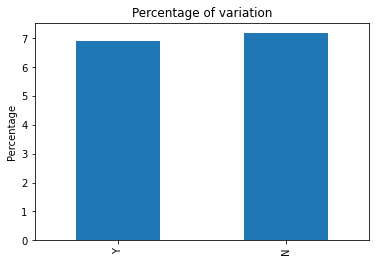

In [ ]:
realty.plot(kind='bar')
plt.title('Percentage of variation')
plt.ylabel('Percentage')


<AxesSubplot:xlabel='TARGET', ylabel='count'>

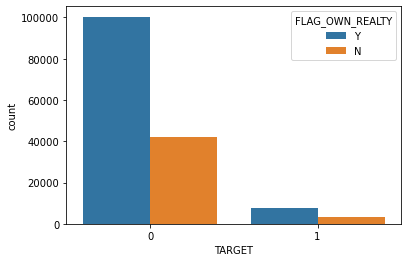

In [ ]:
sns.countplot(x = dff['TARGET'] ,hue= dff['FLAG_OWN_REALTY'])

In [ ]:
car = pd.crosstab(dff['TARGET'] ,dff['FLAG_OWN_CAR'])

In [ ]:
stats.chi2_contingency(car)

(61.29520982350473,
 4.912741305102576e-15,
 1,
 array([[96299.19130758, 46209.80869242],
        [ 7233.80869242,  3471.19130758]]))

In [ ]:
# p value less than 0.05. significant column

# OWN_CAR_AGE

In [ ]:
dff['OWN_CAR_AGE'].isnull().sum()

103534

In [ ]:
dff[dff['OWN_CAR_AGE'].isnull()]['FLAG_OWN_CAR'].value_counts()

N    103533
Y         1
Name: FLAG_OWN_CAR, dtype: int64

In [ ]:
# for the N entries, we can imput4e +1 in OWN_CAR_AGE

In [ ]:
dff[dff['FLAG_OWN_CAR']=='N']['OWN_CAR_AGE']

0        NaN
1        NaN
2        NaN
4        NaN
5        NaN
          ..
153209   NaN
153210   NaN
153211   NaN
153212   NaN
153213   NaN
Name: OWN_CAR_AGE, Length: 103533, dtype: float64

In [ ]:
dff['OWN_CAR_AGE'].isnull().sum()

103534

In [ ]:
dff.index

Int64Index([     0,      1,      2,      3,      4,      5,      6,      7,
                 8,      9,
            ...
            153204, 153205, 153206, 153207, 153208, 153209, 153210, 153211,
            153212, 153213],
           dtype='int64', length=153214)

In [ ]:
l=[]
for i in range(0,len(dff)):
    if dff['FLAG_OWN_CAR'][i]=='N':
        l.append(-1)
    else :
        l.append(dff['OWN_CAR_AGE'][i])
l = pd.Series(l)



In [ ]:
l.isnull().sum()

1

In [ ]:
dff['OWN_CAR_AGE'].isnull().sum()

103534

In [ ]:
dff['OWN_CAR_AGE'] = l

In [ ]:
dff['OWN_CAR_AGE'].isnull().sum()

1

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='OWN_CAR_AGE', ylabel='Density'>

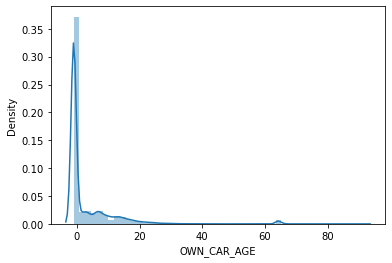

In [ ]:
sns.distplot(dff['OWN_CAR_AGE'])

In [ ]:
dff['OWN_CAR_AGE'].describe()

count    153213.000000
mean          2.995647
std           9.079263
min          -1.000000
25%          -1.000000
50%          -1.000000
75%           4.000000
max          91.000000
Name: OWN_CAR_AGE, dtype: float64

## Occupation Type

In [ ]:
dff[dff['ORGANIZATION_TYPE']=='XNA']['NAME_INCOME_TYPE'].value_counts()

Pensioner     26918
Unemployed       11
Name: NAME_INCOME_TYPE, dtype: int64

In [ ]:
dff[dff['ORGANIZATION_TYPE']=='XNA']['OCCUPATION_TYPE'].isnull().sum()
# for pensioners and unemployed , occupation type is null because they dont have a job. Hence we can impute these values as XNA

26928

In [ ]:
p =[]
for i in range(0,len(dff)):
    if dff['ORGANIZATION_TYPE'][i] == 'XNA' and dff['OCCUPATION_TYPE'][i]!=dff['OCCUPATION_TYPE'][i]:
        p.append('retired')
    else:
        p.append(dff['OCCUPATION_TYPE'][i])
p = pd.Series(p)
p.value_counts()
# give it as retired
# we can combine different levels to one class

retired                  26928
Laborers                 26604
Sales staff              15493
Core staff               14039
Managers                 11947
Drivers                   8231
High skill tech staff     6657
Accountants               5548
Medicine staff            4031
Security staff            2918
Cooking staff             2578
Cleaning staff            2444
Private service staff     1476
Secretaries                781
Low-skill Laborers         713
Waiters/barmen staff       608
Realty agents              440
HR staff                   351
IT staff                   325
dtype: int64

In [ ]:
len(p)

153214

In [ ]:
p.isnull().sum()*100/len(p)

13.77289281658334

In [ ]:
dff['OCCUPATION_TYPE'].isnull().sum()

48030

In [ ]:
dff['OCCUPATION_TYPE']=p

In [ ]:
dff['OCCUPATION_TYPE'].isnull().sum()

21102

In [ ]:
p =[]
for i in range(0,len(dff)):
    if dff['OCCUPATION_TYPE'][i] == 'Pensioner' and dff['OCCUPATION_TYPE'][i] == 'Unemployed'  :
        p.append('Retired')
        
    elif dff['OCCUPATION_TYPE'][i] == 'Medicine staff' or dff['OCCUPATION_TYPE'][i] == 'Security staff' or dff['OCCUPATION_TYPE'][i] == 'Cooking staff' or dff['OCCUPATION_TYPE'][i] == 'Cleaning staff' or dff['OCCUPATION_TYPE'][i] == 'Private service staff' or dff['OCCUPATION_TYPE'][i] == 'Waiters/barmen staff' or dff['OCCUPATION_TYPE'][i] == 'Drivers':
        p.append('Services staff')
        
    elif dff['OCCUPATION_TYPE'][i] == 'Low-skill Laborers' or dff['OCCUPATION_TYPE'][i] == 'Laborers' :
        p.append('Laborers')
        
    elif dff['OCCUPATION_TYPE'][i] == 'High skill tech staff' or dff['OCCUPATION_TYPE'][i] == 'IT staff' :
        p.append('Technical staff')
    
    elif dff['OCCUPATION_TYPE'][i] == 'HR staff' or dff['OCCUPATION_TYPE'][i] == 'Accountants' or dff['OCCUPATION_TYPE'][i] == 'Sales staff' or dff['OCCUPATION_TYPE'][i] == 'Realty agents' :
        p.append('HR Finance & Marketing')
        
    else:
        p.append(dff['OCCUPATION_TYPE'][i])
p = pd.Series(p)
p.value_counts()

Laborers                  27317
retired                   26928
Services staff            22286
HR Finance & Marketing    21832
Core staff                14039
Managers                  11947
Technical staff            6982
Secretaries                 781
dtype: int64

In [ ]:
dff['OCCUPATION_TYPE']=p

In [ ]:
ns = dff.isnull().sum()*100/len(dff)

In [ ]:
ns[ns!=0]

AMT_ANNUITY                      0.003916
AMT_GOODS_PRICE                  0.084196
NAME_TYPE_SUITE                  0.448392
OWN_CAR_AGE                      0.000653
OCCUPATION_TYPE                 13.772893
CNT_FAM_MEMBERS                  0.000653
EXT_SOURCE_1                    54.428446
EXT_SOURCE_2                     0.199068
EXT_SOURCE_3                    19.104651
APARTMENTS_AVG                   2.471706
BASEMENTAREA_AVG                17.569543
YEARS_BEGINEXPLUATATION_AVG      0.573707
ELEVATORS_AVG                    7.266960
ENTRANCES_AVG                    2.141449
FLOORSMAX_AVG                    1.127182
LANDAREA_AVG                    18.807681
LIVINGAREA_AVG                   3.111334
NONLIVINGAREA_AVG               11.006174
APARTMENTS_MODE                  2.471706
BASEMENTAREA_MODE               17.569543
YEARS_BEGINEXPLUATATION_MODE     0.573707
ELEVATORS_MODE                   7.266960
ENTRANCES_MODE                   2.141449
FLOORSMAX_MODE                   1

In [ ]:
dff['OCCUPATION_TYPE'].value_counts()

Laborers                  27317
retired                   26928
Services staff            22286
HR Finance & Marketing    21832
Core staff                14039
Managers                  11947
Technical staff            6982
Secretaries                 781
Name: OCCUPATION_TYPE, dtype: int64

In [ ]:
default = dff[dff['TARGET']==1]

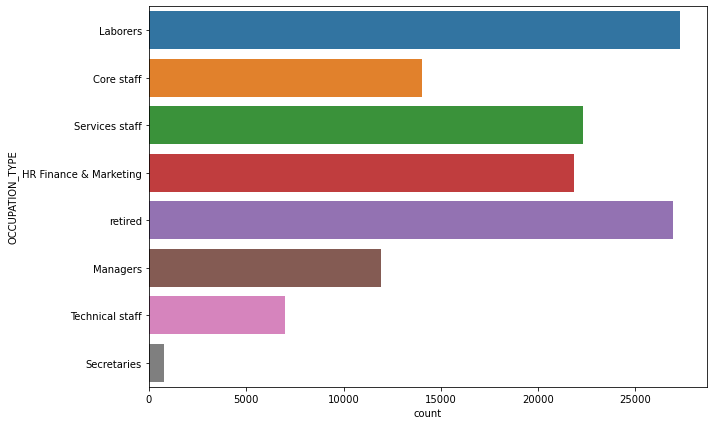

In [ ]:
plt.figure(figsize =(10,7))
sns.countplot(y = dff['OCCUPATION_TYPE'])
plt.show()

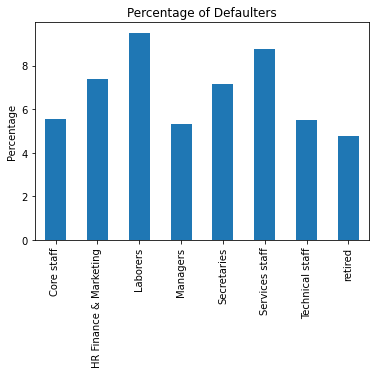

In [ ]:
#plt.figure(figsize =(10,7))
(default['OCCUPATION_TYPE'].value_counts()*100/dff['OCCUPATION_TYPE'].value_counts()).plot(kind='bar')
plt.title('Percentage of Defaulters')
plt.ylabel('Percentage')
plt.show()

In [ ]:
occ = pd.crosstab(dff['TARGET'] , dff['OCCUPATION_TYPE'])

In [ ]:
stats.chi2_contingency(occ)

(695.1556827382565,
 7.639086039032153e-146,
 7,
 array([[13048.92065066, 20292.33105244, 25390.50968118, 11104.45580265,
           725.92115024, 20714.31338561,  6489.6049564 , 25028.94332082],
        [  990.07934934,  1539.66894756,  1926.49031882,   842.54419735,
            55.07884976,  1571.68661439,   492.3950436 ,  1899.05667918]]))

In [ ]:
# p value is 0. #Hence occupation type is significantly related to target

# ORGANIZATION_TYPE
### Type of organization where client works


In [ ]:
dff['ORGANIZATION_TYPE'].isnull().sum()

0

In [ ]:
vc = df['ORGANIZATION_TYPE'].value_counts()
vc

Business Entity Type 3    67992
XNA                       55374
Self-employed             38412
Other                     16683
Medicine                  11193
Business Entity Type 2    10553
Government                10404
School                     8893
Trade: type 7              7831
Kindergarten               6880
Construction               6721
Business Entity Type 1     5984
Transport: type 4          5398
Trade: type 3              3492
Industry: type 9           3368
Industry: type 3           3278
Security                   3247
Housing                    2958
Industry: type 11          2704
Military                   2634
Bank                       2507
Agriculture                2454
Police                     2341
Transport: type 2          2204
Postal                     2157
Security Ministries        1974
Trade: type 2              1900
Restaurant                 1811
Services                   1575
University                 1327
Industry: type 7           1307
Transpor

In [ ]:
len(vc)

58

In [ ]:
p =[]
for i in range(0,len(dff)):
    if dff['ORGANIZATION_TYPE'][i] == 'Business Entity Type 3' or dff['ORGANIZATION_TYPE'][i] == 'Business Entity Type 2' or dff['ORGANIZATION_TYPE'][i] == 'Business Entity Type 1' or dff['ORGANIZATION_TYPE'][i] == 'Self-employed' :
        p.append('Business/Self-employed')
    elif dff['ORGANIZATION_TYPE'][i] == 'Trade: type 1' or dff['ORGANIZATION_TYPE'][i] == 'Trade: type 2' or dff['ORGANIZATION_TYPE'][i] == 'Trade: type 3' or dff['ORGANIZATION_TYPE'][i] == 'Trade: type 4' or dff['ORGANIZATION_TYPE'][i] == 'Trade: type 5' or dff['ORGANIZATION_TYPE'][i] == 'Trade: type 6' or dff['ORGANIZATION_TYPE'][i] == 'Trade: type 7' or dff['ORGANIZATION_TYPE'][i] == 'Industry: type 1' or dff['ORGANIZATION_TYPE'][i] == 'Industry: type 2' or dff['ORGANIZATION_TYPE'][i] == 'Industry: type 3' or dff['ORGANIZATION_TYPE'][i] == 'Industry: type 4' or dff['ORGANIZATION_TYPE'][i] == 'Industry: type 5' or dff['ORGANIZATION_TYPE'][i] == 'Industry: type 6' or dff['ORGANIZATION_TYPE'][i] == 'Industry: type 7' or dff['ORGANIZATION_TYPE'][i] == 'Industry: type 8' or dff['ORGANIZATION_TYPE'][i] == 'Industry: type 9' or dff['ORGANIZATION_TYPE'][i] == 'Industry: type 10' or dff['ORGANIZATION_TYPE'][i] == 'Industry: type 11' or dff['ORGANIZATION_TYPE'][i] == 'Industry: type 12' or dff['ORGANIZATION_TYPE'][i] == 'Industry: type 13':
        p.append('Trade/Industry')
    elif dff['ORGANIZATION_TYPE'][i] == 'Transport: type 1' or dff['ORGANIZATION_TYPE'][i] == 'Transport: type 2' or dff['ORGANIZATION_TYPE'][i] == 'Transport: type 3' or dff['ORGANIZATION_TYPE'][i] == 'Transport: type 4':
        p.append('Transport')
    elif dff['ORGANIZATION_TYPE'][i] == 'XNA' :
        p.append('Retired')
    elif dff['ORGANIZATION_TYPE'][i] == 'Housing' or dff['ORGANIZATION_TYPE'][i] == 'Construction' :
        p.append('Housing/Construction')
    elif dff['ORGANIZATION_TYPE'][i] == 'Agriculture' or dff['ORGANIZATION_TYPE'][i] == 'Emergency' or dff['ORGANIZATION_TYPE'][i] == 'Insurance' or dff['ORGANIZATION_TYPE'][i] == 'Advertising' or dff['ORGANIZATION_TYPE'][i] == 'Realtor' or dff['ORGANIZATION_TYPE'][i] == 'Culture' or dff['ORGANIZATION_TYPE'][i] == 'Religion'  :
        p.append('Other')
    elif dff['ORGANIZATION_TYPE'][i] == 'Security Ministries' or dff['ORGANIZATION_TYPE'][i] == 'Electricity' or dff['ORGANIZATION_TYPE'][i] == 'Government' or dff['ORGANIZATION_TYPE'][i] == 'School' or dff['ORGANIZATION_TYPE'][i] == 'University' or dff['ORGANIZATION_TYPE'][i] == 'Kindergarten' or dff['ORGANIZATION_TYPE'][i] == 'Military' or dff['ORGANIZATION_TYPE'][i] == 'Police'or dff['ORGANIZATION_TYPE'][i] == 'Transport' or dff['ORGANIZATION_TYPE'][i] == 'Bank' or dff['ORGANIZATION_TYPE'][i] == 'Cleaning' or dff['ORGANIZATION_TYPE'][i] == 'Security' or dff['ORGANIZATION_TYPE'][i] == 'Postal' or dff['ORGANIZATION_TYPE'][i] == 'Restaurant' or dff['ORGANIZATION_TYPE'][i] == 'Hotel' or dff['ORGANIZATION_TYPE'][i] == 'Telecom' or dff['ORGANIZATION_TYPE'][i] == 'Mobile' or dff['ORGANIZATION_TYPE'][i] == 'Legal Services' :
        p.append('Services')
    else:
        p.append(dff['ORGANIZATION_TYPE'][i])
p = pd.Series(p)
p.value_counts()

Business/Self-employed    62863
Retired                   26929
Services                  23612
Trade/Industry            14751
Other                      9855
Medicine                   5614
Housing/Construction       4892
Transport                  4698
dtype: int64

In [ ]:
dff['ORGANIZATION_TYPE']=p

In [ ]:
default = dff[dff['TARGET']==1]

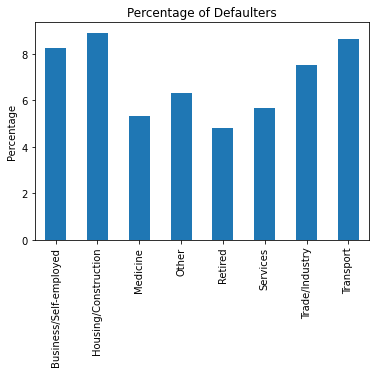

In [ ]:
#plt.figure(figsize =(10,5))
(default['ORGANIZATION_TYPE'].value_counts()*100/dff['ORGANIZATION_TYPE'].value_counts()).plot(kind='bar')
plt.title('Percentage of Defaulters')
plt.ylabel('Percentage')
plt.show()

In [ ]:
# XNA implies no organization

In [ ]:
org_type = pd.crosstab(dff['ORGANIZATION_TYPE'] , dff['TARGET'])

In [ ]:
statistic , p , df , arr = stats.chi2_contingency(org_type)

In [ ]:
p

3.793811879326563e-105

In [ ]:
# p value less than 0.05. Hence significant column

## AMT_REQ_CRED

In [ ]:
dff.info(max_cols = 120)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 153214 entries, 0 to 153213
Data columns (total 112 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   TARGET                        153214 non-null  int64  
 1   NAME_CONTRACT_TYPE            153214 non-null  object 
 2   CODE_GENDER                   153214 non-null  object 
 3   FLAG_OWN_CAR                  153214 non-null  object 
 4   FLAG_OWN_REALTY               153214 non-null  object 
 5   CNT_CHILDREN                  153214 non-null  int64  
 6   AMT_INCOME_TOTAL              153214 non-null  float64
 7   AMT_CREDIT                    153214 non-null  float64
 8   AMT_ANNUITY                   153208 non-null  float64
 9   AMT_GOODS_PRICE               153085 non-null  float64
 10  NAME_TYPE_SUITE               152527 non-null  object 
 11  NAME_INCOME_TYPE              153214 non-null  object 
 12  NAME_EDUCATION_TYPE           153214 non-nu

In [ ]:
amt_req_credit = dff.iloc[:, 105:]

In [ ]:
amt_req_credit.head()

,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,LOG_AMT_INCOME_TOTAL
0,0.0,0.0,0.0,0.0,0.0,1.0,12.218495
1,0.0,0.0,0.0,0.0,0.0,0.0,12.506177
2,0.0,0.0,0.0,1.0,0.0,0.0,11.119883
3,0.0,0.0,0.0,0.0,0.0,1.0,12.323856
4,NaN,NaN,NaN,NaN,NaN,NaN,12.149502


In [ ]:
amt_req_credit.isnull().sum()*100/len(amt_req_credit)

AMT_REQ_CREDIT_BUREAU_HOUR    12.593497
AMT_REQ_CREDIT_BUREAU_DAY     12.593497
AMT_REQ_CREDIT_BUREAU_WEEK    12.593497
AMT_REQ_CREDIT_BUREAU_MON     12.593497
AMT_REQ_CREDIT_BUREAU_QRT     12.593497
AMT_REQ_CREDIT_BUREAU_YEAR    12.593497
LOG_AMT_INCOME_TOTAL           0.000000
dtype: float64

### AMT_REQ_CREDIT_BUREAU_HOUR

In [ ]:
dff['AMT_REQ_CREDIT_BUREAU_HOUR'].value_counts()

0.0    133036
1.0       845
2.0        33
3.0         4
4.0         1
Name: AMT_REQ_CREDIT_BUREAU_HOUR, dtype: int64

Text(0, 0.5, 'Percentage')

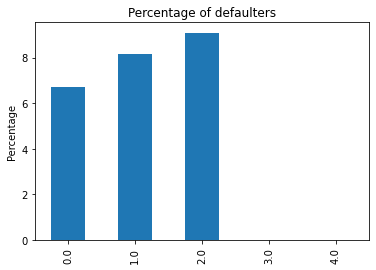

In [ ]:
(default['AMT_REQ_CREDIT_BUREAU_HOUR'].value_counts()*100/dff['AMT_REQ_CREDIT_BUREAU_HOUR'].value_counts()).plot(kind='bar')
plt.title('Percentage of defaulters')
plt.ylabel('Percentage')

In [ ]:
table = pd.crosstab(dff['TARGET'] , dff['AMT_REQ_CREDIT_BUREAU_HOUR'])
table

AMT_REQ_CREDIT_BUREAU_HOUR,0.0,1.0,2.0,3.0,4.0
TARGET,,,,,
0,124106,776,30,4,1
1,8930,69,3,0,0


In [ ]:
stats.chi2_contingency(table)

(3.483757266279472,
 0.4803523820523239,
 4,
 array([[1.24093355e+05, 7.88199322e+02, 3.07817487e+01, 3.73112105e+00,
         9.32780263e-01],
        [8.94264497e+03, 5.68006780e+01, 2.21825133e+00, 2.68878949e-01,
         6.72197373e-02]]))

In [ ]:
# p value greater than 0.05.

### AMT_REQ_CREDIT_BUREAU_DAY

In [ ]:
dff['AMT_REQ_CREDIT_BUREAU_DAY'].value_counts()

0.0    133096
1.0       706
2.0        58
3.0        29
4.0        16
5.0         7
6.0         4
9.0         2
8.0         1
Name: AMT_REQ_CREDIT_BUREAU_DAY, dtype: int64

In [ ]:
default['AMT_REQ_CREDIT_BUREAU_DAY'].value_counts()

0.0    8933
1.0      62
2.0       4
3.0       2
4.0       1
Name: AMT_REQ_CREDIT_BUREAU_DAY, dtype: int64

Text(0, 0.5, 'Percentage')

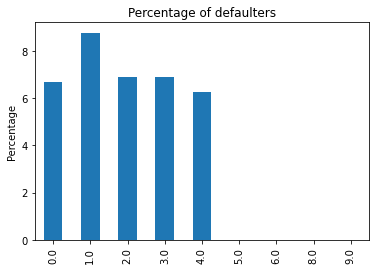

In [ ]:
(default['AMT_REQ_CREDIT_BUREAU_DAY'].value_counts()*100/dff['AMT_REQ_CREDIT_BUREAU_DAY'].value_counts()).plot(kind='bar')
plt.title('Percentage of defaulters')
plt.ylabel('Percentage')

In [ ]:
table = pd.crosstab(dff['TARGET'] , dff['AMT_REQ_CREDIT_BUREAU_DAY'])
table

AMT_REQ_CREDIT_BUREAU_DAY,0.0,1.0,2.0,3.0,4.0,5.0,6.0,8.0,9.0
TARGET,,,,,,,,,
0,124163,644,54,27,15,7,4,1,2
1,8933,62,4,2,1,0,0,0,0


In [ ]:
stats.chi2_contingency(table)

(5.818928573600344,
 0.6675062988995923,
 8,
 array([[1.24149322e+05, 6.58542865e+02, 5.41012552e+01, 2.70506276e+01,
         1.49244842e+01, 6.52946184e+00, 3.73112105e+00, 9.32780263e-01,
         1.86556053e+00],
        [8.94667816e+03, 4.74571345e+01, 3.89874476e+00, 1.94937238e+00,
         1.07551580e+00, 4.70538161e-01, 2.68878949e-01, 6.72197373e-02,
         1.34439475e-01]]))

In [ ]:
# p value greater than 0.05

### AMT_REQ_CREDIT_BUREAU_WEEK

In [ ]:
dff['AMT_REQ_CREDIT_BUREAU_WEEK'].value_counts()

0.0    129544
1.0      4196
2.0       101
3.0        37
4.0        21
6.0        11
5.0         5
8.0         4
Name: AMT_REQ_CREDIT_BUREAU_WEEK, dtype: int64

Text(0, 0.5, 'Percentage')

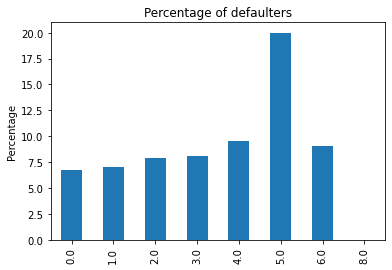

In [ ]:
(default['AMT_REQ_CREDIT_BUREAU_WEEK'].value_counts()*100/dff['AMT_REQ_CREDIT_BUREAU_WEEK'].value_counts()).plot(kind='bar')
plt.title('Percentage of defaulters')
plt.ylabel('Percentage')

In [ ]:
table = pd.crosstab(dff['TARGET'] , dff['AMT_REQ_CREDIT_BUREAU_WEEK'])
table

AMT_REQ_CREDIT_BUREAU_WEEK,0.0,1.0,2.0,3.0,4.0,5.0,6.0,8.0
TARGET,,,,,,,,
0,120853,3900,93,34,19,4,10,4
1,8691,296,8,3,2,1,1,0


In [ ]:
stats.chi2_contingency(table)

(3.174892618094753,
 0.8683655647177935,
 7,
 array([[1.20836086e+05, 3.91394598e+03, 9.42108065e+01, 3.45128697e+01,
         1.95883855e+01, 4.66390131e+00, 1.02605829e+01, 3.73112105e+00],
        [8.70791365e+03, 2.82054018e+02, 6.78919347e+00, 2.48713028e+00,
         1.41161448e+00, 3.36098687e-01, 7.39417110e-01, 2.68878949e-01]]))

In [ ]:
# p value greater than 0.05

### AMT_REQ_CREDIT_BUREAU_MON

In [ ]:
dff['AMT_REQ_CREDIT_BUREAU_MON'].value_counts()

0.0     109839
1.0      17458
2.0       3194
3.0       1256
4.0        673
5.0        398
6.0        248
7.0        195
9.0        141
8.0        129
10.0        97
11.0        83
12.0        61
13.0        52
15.0        29
14.0        26
16.0        17
17.0        11
18.0         6
19.0         2
27.0         1
23.0         1
24.0         1
22.0         1
Name: AMT_REQ_CREDIT_BUREAU_MON, dtype: int64

In [ ]:
default['AMT_REQ_CREDIT_BUREAU_MON'].value_counts()

0.0     7436
1.0     1203
2.0      199
3.0       65
4.0       34
5.0       22
7.0       12
6.0       10
10.0       7
9.0        5
11.0       3
13.0       2
8.0        2
15.0       1
12.0       1
Name: AMT_REQ_CREDIT_BUREAU_MON, dtype: int64

Text(0, 0.5, 'Percentage')

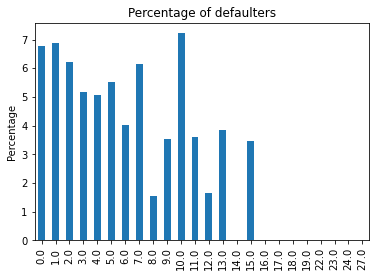

In [ ]:
(default['AMT_REQ_CREDIT_BUREAU_MON'].value_counts()*100/dff['AMT_REQ_CREDIT_BUREAU_MON'].value_counts()).plot(kind='bar')
plt.title('Percentage of defaulters')
plt.ylabel('Percentage')

In [ ]:
table = pd.crosstab(dff['TARGET'] , dff['AMT_REQ_CREDIT_BUREAU_MON'])
table

AMT_REQ_CREDIT_BUREAU_MON,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,14.0,15.0,16.0,17.0,18.0,19.0,22.0,23.0,24.0,27.0
TARGET,,,,,,,,,,,,,,,,,,,,,
0,102403,16255,2995,1191,639,376,238,183,127,136,...,26,28,17,11,6,2,1,1,1,1
1,7436,1203,199,65,34,22,10,12,2,5,...,0,1,0,0,0,0,0,0,0,0


In [ ]:
stats.chi2_contingency(table)

(31.618304235417696,
 0.10834545802987074,
 23,
 array([[1.02455651e+05, 1.62844778e+04, 2.97930016e+03, 1.17157201e+03,
         6.27761117e+02, 3.71246545e+02, 2.31329505e+02, 1.81892151e+02,
         1.20328654e+02, 1.31522017e+02, 9.04796855e+01, 7.74207618e+01,
         5.68995960e+01, 4.85045737e+01, 2.42522868e+01, 2.70506276e+01,
         1.58572645e+01, 1.02605829e+01, 5.59668158e+00, 1.86556053e+00,
         9.32780263e-01, 9.32780263e-01, 9.32780263e-01, 9.32780263e-01],
        [7.38334873e+03, 1.17352217e+03, 2.14699841e+02, 8.44279901e+01,
         4.52388832e+01, 2.67534554e+01, 1.66704949e+01, 1.31078488e+01,
         8.67134611e+00, 9.47798296e+00, 6.52031452e+00, 5.57923820e+00,
         4.10040398e+00, 3.49542634e+00, 1.74771317e+00, 1.94937238e+00,
         1.14273553e+00, 7.39417110e-01, 4.03318424e-01, 1.34439475e-01,
         6.72197373e-02, 6.72197373e-02, 6.72197373e-02, 6.72197373e-02]]))

In [ ]:
# p value less than 0.05

### AMT_REQ_CREDIT_BUREAU_QRT

In [ ]:
dff['AMT_REQ_CREDIT_BUREAU_QRT'].value_counts()

0.0      108528
1.0       16862
2.0        7327
3.0         890
4.0         247
5.0          37
6.0          17
8.0           6
7.0           3
19.0          1
261.0         1
Name: AMT_REQ_CREDIT_BUREAU_QRT, dtype: int64

In [ ]:
default['AMT_REQ_CREDIT_BUREAU_QRT'].value_counts()

0.0     7378
1.0      967
2.0      562
3.0       52
4.0       32
5.0        5
6.0        4
19.0       1
7.0        1
Name: AMT_REQ_CREDIT_BUREAU_QRT, dtype: int64

Text(0, 0.5, 'Percentage')

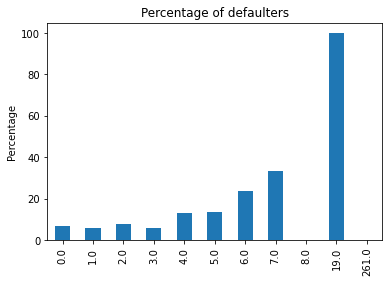

In [ ]:
(default['AMT_REQ_CREDIT_BUREAU_QRT'].value_counts()*100/dff['AMT_REQ_CREDIT_BUREAU_QRT'].value_counts()).plot(kind='bar')
plt.title('Percentage of defaulters')
plt.ylabel('Percentage')

In [ ]:
table = pd.crosstab(dff['TARGET'] , dff['AMT_REQ_CREDIT_BUREAU_QRT'])
table

AMT_REQ_CREDIT_BUREAU_QRT,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,19.0,261.0
TARGET,,,,,,,,,,,
0,101150,15895,6765,838,215,32,13,2,6,0,1
1,7378,967,562,52,32,5,4,1,0,1,0


In [ ]:
stats.chi2_contingency(table)

(82.27732436577116,
 1.7936193318741341e-13,
 10,
 array([[1.01232776e+05, 1.57285408e+04, 6.83448098e+03, 8.30174434e+02,
         2.30396725e+02, 3.45128697e+01, 1.58572645e+01, 2.79834079e+00,
         5.59668158e+00, 9.32780263e-01, 9.32780263e-01],
        [7.29522365e+03, 1.13345921e+03, 4.92519015e+02, 5.98255662e+01,
         1.66032751e+01, 2.48713028e+00, 1.14273553e+00, 2.01659212e-01,
         4.03318424e-01, 6.72197373e-02, 6.72197373e-02]]))

In [ ]:
# p value less than 0.05

### AMT_REQ_CREDIT_BUREAU_YEAR

In [ ]:
dff['AMT_REQ_CREDIT_BUREAU_YEAR'].value_counts()

0.0     37124
1.0     31560
2.0     24849
3.0     16706
4.0     10399
5.0      6065
6.0      3509
7.0      1987
8.0      1096
9.0       552
12.0       15
11.0       15
13.0       13
10.0        9
14.0        5
15.0        4
17.0        4
18.0        3
19.0        2
16.0        2
Name: AMT_REQ_CREDIT_BUREAU_YEAR, dtype: int64

In [ ]:
default['AMT_REQ_CREDIT_BUREAU_YEAR'].value_counts()

0.0     2345
1.0     1988
2.0     1724
3.0     1181
4.0      764
5.0      443
6.0      263
7.0      157
8.0       75
9.0       58
13.0       1
11.0       1
14.0       1
16.0       1
Name: AMT_REQ_CREDIT_BUREAU_YEAR, dtype: int64

Text(0, 0.5, 'Percentage')

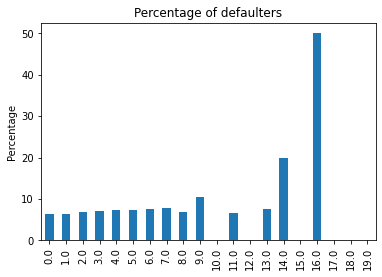

In [ ]:
(default['AMT_REQ_CREDIT_BUREAU_YEAR'].value_counts()*100/dff['AMT_REQ_CREDIT_BUREAU_YEAR'].value_counts()).plot(kind='bar')
plt.title('Percentage of defaulters')
plt.ylabel('Percentage')

In [ ]:
table = pd.crosstab(dff['TARGET'] , dff['AMT_REQ_CREDIT_BUREAU_YEAR'])
table

AMT_REQ_CREDIT_BUREAU_YEAR,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0
TARGET,,,,,,,,,,,,,,,,,,,,
0,34779,29572,23125,15525,9635,5622,3246,1830,1021,494,9,14,15,12,4,4,1,4,3,2
1,2345,1988,1724,1181,764,443,263,157,75,58,0,1,0,1,1,0,1,0,0,0


In [ ]:
stats.chi2_contingency(table)

(64.0022077004597,
 8.860760485627854e-07,
 19,
 array([[3.46285345e+04, 2.94385451e+04, 2.31786567e+04, 1.55830271e+04,
         9.69998195e+03, 5.65731229e+03, 3.27312594e+03, 1.85343438e+03,
         1.02232717e+03, 5.14894705e+02, 8.39502236e+00, 1.39917039e+01,
         1.39917039e+01, 1.21261434e+01, 4.66390131e+00, 3.73112105e+00,
         1.86556053e+00, 3.73112105e+00, 2.79834079e+00, 1.86556053e+00],
        [2.49546553e+03, 2.12145491e+03, 1.67034325e+03, 1.12297293e+03,
         6.99018048e+02, 4.07687707e+02, 2.35874058e+02, 1.33565618e+02,
         7.36728321e+01, 3.71052950e+01, 6.04977636e-01, 1.00829606e+00,
         1.00829606e+00, 8.73856585e-01, 3.36098687e-01, 2.68878949e-01,
         1.34439475e-01, 2.68878949e-01, 2.01659212e-01, 1.34439475e-01]]))

In [ ]:
# p value less than 0.05

# FLAG DOCUMENTS

In [ ]:
dff.info(max_cols = 120)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 153214 entries, 0 to 153213
Data columns (total 112 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   TARGET                        153214 non-null  int64  
 1   NAME_CONTRACT_TYPE            153214 non-null  object 
 2   CODE_GENDER                   153214 non-null  object 
 3   FLAG_OWN_CAR                  153214 non-null  object 
 4   FLAG_OWN_REALTY               153214 non-null  object 
 5   CNT_CHILDREN                  153214 non-null  int64  
 6   AMT_INCOME_TOTAL              153214 non-null  float64
 7   AMT_CREDIT                    153214 non-null  float64
 8   AMT_ANNUITY                   153208 non-null  float64
 9   AMT_GOODS_PRICE               153085 non-null  float64
 10  NAME_TYPE_SUITE               152527 non-null  object 
 11  NAME_INCOME_TYPE              153214 non-null  object 
 12  NAME_EDUCATION_TYPE           153214 non-nu

In [ ]:
document = dff.iloc[:,85:105]

In [ ]:
doc_cols = document.columns

In [ ]:
document.head()

,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21
0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
document.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 153214 entries, 0 to 153213
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   FLAG_DOCUMENT_2   153214 non-null  int64
 1   FLAG_DOCUMENT_3   153214 non-null  int64
 2   FLAG_DOCUMENT_4   153214 non-null  int64
 3   FLAG_DOCUMENT_5   153214 non-null  int64
 4   FLAG_DOCUMENT_6   153214 non-null  int64
 5   FLAG_DOCUMENT_7   153214 non-null  int64
 6   FLAG_DOCUMENT_8   153214 non-null  int64
 7   FLAG_DOCUMENT_9   153214 non-null  int64
 8   FLAG_DOCUMENT_10  153214 non-null  int64
 9   FLAG_DOCUMENT_11  153214 non-null  int64
 10  FLAG_DOCUMENT_12  153214 non-null  int64
 11  FLAG_DOCUMENT_13  153214 non-null  int64
 12  FLAG_DOCUMENT_14  153214 non-null  int64
 13  FLAG_DOCUMENT_15  153214 non-null  int64
 14  FLAG_DOCUMENT_16  153214 non-null  int64
 15  FLAG_DOCUMENT_17  153214 non-null  int64
 16  FLAG_DOCUMENT_18  153214 non-null  int64
 17  FLAG_DOCUM

In [ ]:
for i in document.columns:
    document[i] = document[i]/document[i].sum()

In [ ]:
document.head()

,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21
0,0.0,0.000009,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.000009,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.000009,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.000009,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.000009,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
dff['FLAG_DOC_SCORE'] =document.sum(axis = 1)

In [ ]:
for i in document.columns:
    print(document[i].value_counts())
    
# giving weightage to columns based on the sum of dcuments submitted 

0.000000    153205
0.111111         9
Name: FLAG_DOCUMENT_2, dtype: int64
0.000009    106538
0.000000     46676
Name: FLAG_DOCUMENT_3, dtype: int64
0.0    153204
0.1        10
Name: FLAG_DOCUMENT_4, dtype: int64
0.000000    150855
0.000424      2359
Name: FLAG_DOCUMENT_5, dtype: int64
0.000000    139967
0.000075     13247
Name: FLAG_DOCUMENT_6, dtype: int64
0.000000    153180
0.029412        34
Name: FLAG_DOCUMENT_7, dtype: int64
0.000000    139818
0.000075     13396
Name: FLAG_DOCUMENT_8, dtype: int64
0.000000    152474
0.001351       740
Name: FLAG_DOCUMENT_9, dtype: int64
0.0    153209
0.2         5
Name: FLAG_DOCUMENT_10, dtype: int64
0.000000    152489
0.001379       725
Name: FLAG_DOCUMENT_11, dtype: int64
0.0    153212
0.5         2
Name: FLAG_DOCUMENT_12, dtype: int64
0.000000    152537
0.001477       677
Name: FLAG_DOCUMENT_13, dtype: int64
0.000000    152552
0.001511       662
Name: FLAG_DOCUMENT_14, dtype: int64
0.000000    152990
0.004464       224
Name: FLAG_DOCUMENT_15, d

In [ ]:
# #for i in document.columns:
#     sns.countplot(x=df_treated['TARGET'] ,hue = document[i])
#     plt.title(i)
#     plt.show()

In [ ]:
dff[doc_cols] = document

<AxesSubplot:xlabel='TARGET', ylabel='FLAG_DOC_SCORE'>

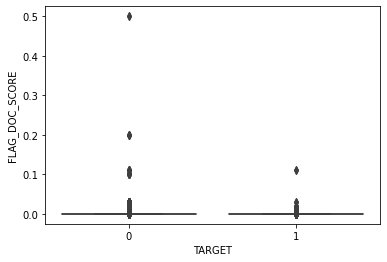

In [ ]:
sns.boxplot(x = dff['TARGET'] ,y = dff['FLAG_DOC_SCORE'])

In [ ]:
dff['FLAG_DOC_SCORE'].describe()

count    153214.000000
mean          0.000131
std           0.002568
min           0.000000
25%           0.000009
50%           0.000009
75%           0.000009
max           0.500075
Name: FLAG_DOC_SCORE, dtype: float64

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='FLAG_DOC_SCORE', ylabel='Density'>

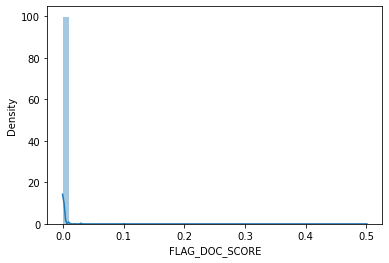

In [ ]:
sns.distplot(dff['FLAG_DOC_SCORE'])

In [ ]:
default = dff[dff['TARGET']==1]
non_default = dff[dff['TARGET']==0]

In [ ]:
default_score = default['FLAG_DOC_SCORE']
non_default_score = non_default['FLAG_DOC_SCORE']

In [ ]:
stats.shapiro(default_score)

C:\Users\saketh\anaconda3\lib\site-packages\scipy\stats\morestats.py:1681: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


ShapiroResult(statistic=0.02518606185913086, pvalue=0.0)

In [ ]:
stats.mannwhitneyu(default_score , non_default_score)

MannwhitneyuResult(statistic=752551947.5, pvalue=0.0027289236674926825)

In [ ]:
stats.kruskal(default_score , non_default_score)

KruskalResult(statistic=7.721122532205096, pvalue=0.0054578450527284356)

In [ ]:
# p value less than 0.05 , hence flag doc score is significantly related to target

## KARTHIK

### AMT_CREDIT


In [ ]:
dff['AMT_CREDIT'].head()

0     406597.5
1    1293502.5
2      80865.0
3     918468.0
4     773680.5
Name: AMT_CREDIT, dtype: float64

In [ ]:
dff['AMT_CREDIT'].isnull().sum()*100/len(dff['AMT_CREDIT'])

0.0

In [ ]:
skewness = dff['AMT_CREDIT'].skew()
kurtosis = dff['AMT_CREDIT'].kurt()
print('Skewness',skewness)
print('Kurtosis',kurtosis)

Skewness 1.231714291887597
Kurtosis 1.8307042390593868


In [ ]:
dff['LOG_AMT_CREDIT'] = np.log(dff['AMT_CREDIT'])

In [ ]:
dff['LOG_AMT_CREDIT'].skew()

-0.323912272781313

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


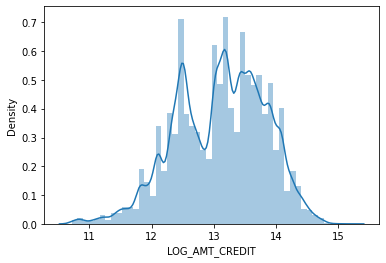

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


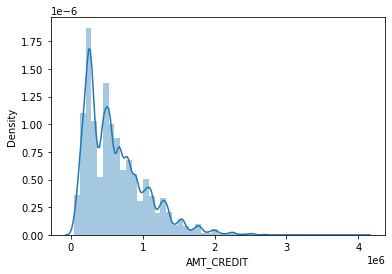

In [ ]:
sns.distplot(dff['LOG_AMT_CREDIT'])
plt.show()
sns.distplot(dff['AMT_CREDIT'])
plt.show()

In [ ]:
dff['TARGET'].head()

0    1
1    0
2    0
3    0
4    0
Name: TARGET, dtype: int64

In [ ]:
pd.pivot_table(data=dff,values='AMT_CREDIT',index='TARGET',aggfunc='mean')

,AMT_CREDIT
TARGET,
0,625215.123655
1,579281.869127


In [ ]:
a=dff[dff['TARGET'] == 1]['LOG_AMT_CREDIT']

In [ ]:
b=dff[dff['TARGET'] == 0]['LOG_AMT_CREDIT']

In [ ]:
stats.shapiro(a)

C:\Users\saketh\anaconda3\lib\site-packages\scipy\stats\morestats.py:1681: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


ShapiroResult(statistic=0.991070032119751, pvalue=2.462098980143327e-25)

In [ ]:
stats.f_oneway(a,b) 

F_onewayResult(statistic=21.55195105395597, pvalue=3.4465707726933113e-06)

In [ ]:
stats.kruskal(a,b)

KruskalResult(statistic=42.496189228715885, pvalue=7.08200689332406e-11)

In [ ]:
#As p value is less than 0.05 there is relation with target column

<AxesSubplot:xlabel='TARGET', ylabel='LOG_AMT_CREDIT'>

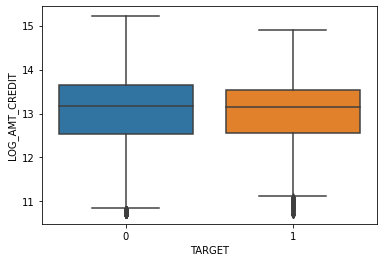

In [ ]:
sns.boxplot(x=('TARGET'),y=('LOG_AMT_CREDIT'),data=dff)

sns.barplot(x=('TARGET'),y=('AMT_CREDIT'),data=df_new1)

In [ ]:
#outliers should be treated???

### AMT_ANNUITY

In [ ]:

dff['AMT_ANNUITY'].head()

0    24700.5
1    35698.5
2     5881.5
3    28966.5
4    32778.0
Name: AMT_ANNUITY, dtype: float64

In [ ]:
dff['AMT_ANNUITY'].isnull().sum()

6

In [ ]:
#what imputation to be done?

In [ ]:
dff['AMT_ANNUITY'].isnull().sum()*100/len(dff['AMT_ANNUITY'])

0.003916091218818123

In [ ]:
skewness = dff['AMT_ANNUITY'].skew()
kurtosis = dff['AMT_ANNUITY'].kurt()
print('Skewness',skewness)
print('Kurtosis',kurtosis)

Skewness 1.6702892258900814
Kurtosis 8.547372241845203


C:\Users\saketh\anaconda3\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='AMT_ANNUITY', ylabel='Density'>

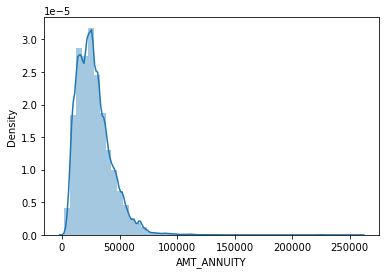

In [ ]:
sns.distplot(dff['AMT_ANNUITY'])

In [ ]:
dff['LOG_AMT_ANNUITY'] = np.log(dff['AMT_ANNUITY'])

In [ ]:
dff['LOG_AMT_ANNUITY'].skew()

-0.33828984271075846

In [ ]:
dff['AMT_ANNUITY'].head()

0    24700.5
1    35698.5
2     5881.5
3    28966.5
4    32778.0
Name: AMT_ANNUITY, dtype: float64

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


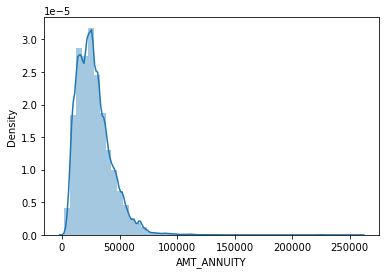

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


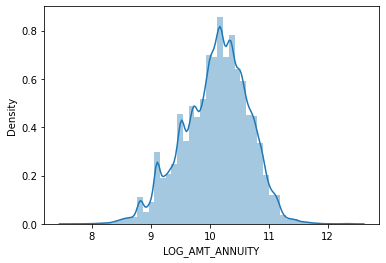

In [ ]:
sns.distplot(dff['AMT_ANNUITY'])
plt.show()
sns.distplot(dff['LOG_AMT_ANNUITY'])
plt.show()

In [ ]:
pd.pivot_table(data=dff,values='AMT_ANNUITY',index='TARGET',aggfunc='mean')

,AMT_ANNUITY
TARGET,
0,28141.407034
1,27173.362447


In [ ]:
c=dff[dff['TARGET']==1]['AMT_ANNUITY']

In [ ]:
d=dff[dff['TARGET'] ==0]['AMT_ANNUITY']

In [ ]:
!pip install pingouin

In [ ]:
import pingouin as pg

# Levene's Test in Python using Pingouin
pg.homoscedasticity(dff, dv='TARGET', 
                    group='AMT_ANNUITY')

,W,pval,equal_var
levene,1.059208,0.000007,False


In [ ]:
stats.mannwhitneyu(c,d)

MannwhitneyuResult(statistic=754919815.5, pvalue=0.037467593678928386)

In [ ]:
c=dff[dff['TARGET']==1]['LOG_AMT_ANNUITY']

In [ ]:
d=dff[dff['TARGET'] ==0]['LOG_AMT_ANNUITY']

In [ ]:
# Levene's Test in Python using Pingouin
pg.homoscedasticity(dff, dv='TARGET', 
                    group='LOG_AMT_ANNUITY')

,W,pval,equal_var
levene,1.059208,0.000007,False


In [ ]:
stats.mannwhitneyu(c,d)

MannwhitneyuResult(statistic=754919815.5, pvalue=0.037467593678928386)

In [ ]:
# pvalue > 0.05. Hence amt annuity is not significantly related to TARGET

<AxesSubplot:xlabel='TARGET', ylabel='AMT_ANNUITY'>

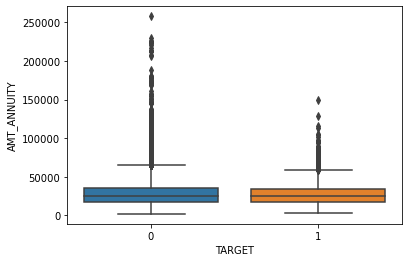

In [ ]:
sns.boxplot(x=('TARGET'),y=('AMT_ANNUITY'),data=dff)

<AxesSubplot:xlabel='TARGET', ylabel='LOG_AMT_ANNUITY'>

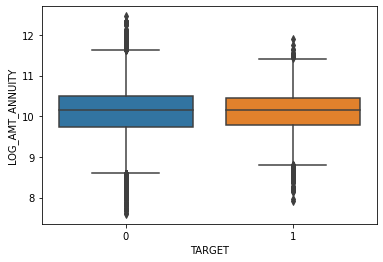

In [ ]:
sns.boxplot(x=('TARGET'),y=('LOG_AMT_ANNUITY'),data=dff)

In [ ]:
#sns.barplot(x=('TARGET'),y=('AMT_CREDIT'),data=df_new1)

### AMT_GOODS_PRICE

In [ ]:
dff['AMT_GOODS_PRICE'].head()

0     351000.0
1    1129500.0
2      67500.0
3     697500.0
4     679500.0
Name: AMT_GOODS_PRICE, dtype: float64

In [ ]:
dff['AMT_GOODS_PRICE'].isnull().sum()

129

In [ ]:
dff['AMT_GOODS_PRICE'].isnull().sum()*100/len(dff['AMT_GOODS_PRICE'])

0.08419596120458966

In [ ]:
skewness = dff['AMT_GOODS_PRICE'].skew()
kurtosis = dff['AMT_GOODS_PRICE'].kurt()
print('Skewness',skewness)
print('Kurtosis',kurtosis)

Skewness 1.340026803258285
Kurtosis 2.2765767312751546


In [ ]:
dff['LOG_AMT_GOODS_PRICE'] = np.log(dff['AMT_GOODS_PRICE'])

In [ ]:
dff['LOG_AMT_GOODS_PRICE'].skew()

-0.278443352154527

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


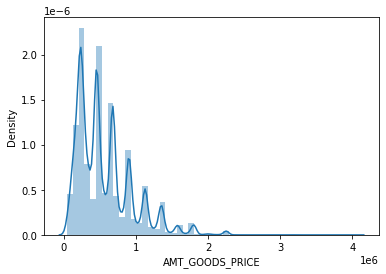

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


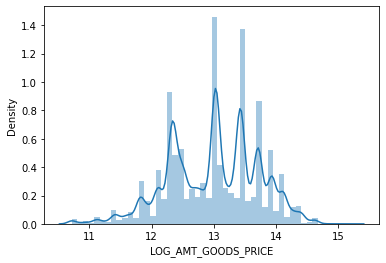

In [ ]:
sns.distplot(dff['AMT_GOODS_PRICE'])
plt.show()
sns.distplot(dff['LOG_AMT_GOODS_PRICE'])
plt.show()

In [ ]:
pd.pivot_table(data=dff,values='AMT_GOODS_PRICE',index='TARGET',aggfunc='mean')

,AMT_GOODS_PRICE
TARGET,
0,564990.138309
1,509535.897308


In [ ]:
e=dff[dff['TARGET']==1]['AMT_GOODS_PRICE']

In [ ]:
f=dff[dff['TARGET']==0]['AMT_GOODS_PRICE']

In [ ]:
# Levene's Test in Python using Pingouin
pg.homoscedasticity(dff, dv='TARGET', 
                    group='AMT_GOODS_PRICE')

,W,pval,equal_var
levene,2.123611,2.230760e-62,False


In [ ]:
stats.mannwhitneyu(e,f)

MannwhitneyuResult(statistic=711750317.5, pvalue=2.8087615519460283e-31)

<AxesSubplot:xlabel='TARGET', ylabel='AMT_GOODS_PRICE'>

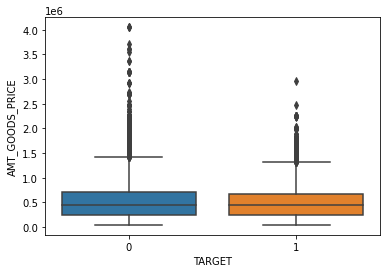

In [ ]:
sns.boxplot(x=('TARGET'),y=('AMT_GOODS_PRICE'),data=dff)

<AxesSubplot:xlabel='TARGET', ylabel='LOG_AMT_GOODS_PRICE'>

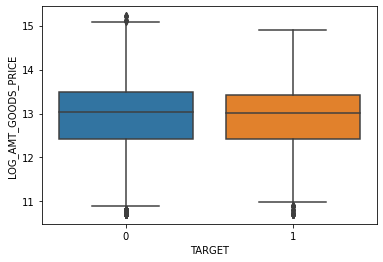

In [ ]:
sns.boxplot(x=('TARGET'),y=('LOG_AMT_GOODS_PRICE'),data=dff)

In [ ]:
#sns.barplot(x=('TARGET'),y=('AMT_GOODS_PRICE'),data=df_new1)

### NAME_INCOME_TYPE


In [ ]:
dff['NAME_INCOME_TYPE'].head()

0          Working
1    State servant
2          Working
3          Working
4          Working
Name: NAME_INCOME_TYPE, dtype: object

In [ ]:
table=pd.crosstab(dff['NAME_INCOME_TYPE'],dff['TARGET'])
table

TARGET,0,1
NAME_INCOME_TYPE,,
Businessman,9,0
Commercial associate,37676,2621
Maternity leave,2,0
Pensioner,25637,1287
State servant,9922,498
Student,9,0
Unemployed,8,3
Working,69246,6296


In [ ]:
observed_value=table.values
observed_value

array([[    9,     0],
       [37676,  2621],
       [    2,     0],
       [25637,  1287],
       [ 9922,   498],
       [    9,     0],
       [    8,     3],
       [69246,  6296]], dtype=int64)

In [ ]:
stats.chi2_contingency(observed= observed_value)

(513.8881618577374,
 8.276628403222614e-107,
 7,
 array([[8.37117365e+00, 6.28826347e-01],
        [3.74814650e+04, 2.81553504e+03],
        [1.86026081e+00, 1.39739188e-01],
        [2.50428310e+04, 1.88116895e+03],
        [9.69195883e+03, 7.28041171e+02],
        [8.37117365e+00, 6.28826347e-01],
        [1.02314345e+01, 7.68565536e-01],
        [7.02639111e+04, 5.27808888e+03]]))

In [ ]:
#p-value is less than 0.05, reject Ho

In [ ]:
dff['NAME_INCOME_TYPE'].isnull().sum()*100/len(dff['NAME_INCOME_TYPE'])

0.0

In [ ]:
dff['NAME_INCOME_TYPE'].value_counts()

Working                 75542
Commercial associate    40297
Pensioner               26924
State servant           10420
Unemployed                 11
Businessman                 9
Student                     9
Maternity leave             2
Name: NAME_INCOME_TYPE, dtype: int64

In [ ]:
(dff.groupby(['NAME_INCOME_TYPE'])['TARGET'].sum()/dff['NAME_INCOME_TYPE'].value_counts())*100

Businessman              0.000000
Commercial associate     6.504206
Maternity leave          0.000000
Pensioner                4.780122
State servant            4.779271
Student                  0.000000
Unemployed              27.272727
Working                  8.334436
dtype: float64

<AxesSubplot:>

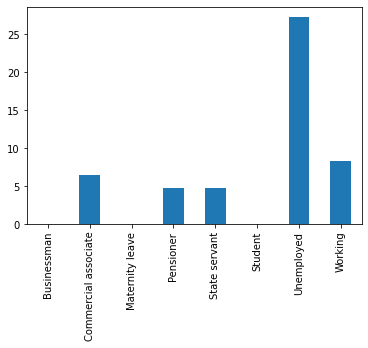

In [ ]:
((dff.groupby(['NAME_INCOME_TYPE'])['TARGET'].sum()/dff['NAME_INCOME_TYPE'].value_counts())*100).plot(kind='bar')

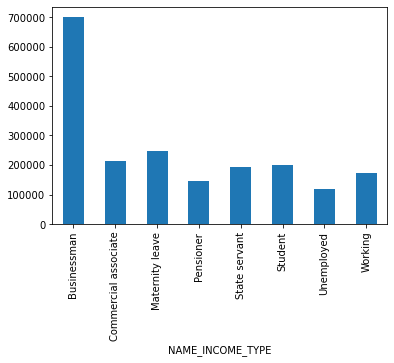

In [ ]:
dff.groupby('NAME_INCOME_TYPE')['AMT_INCOME_TOTAL'].mean().plot(kind='bar')
plt.show()

### NAME_EDUCATION_TYPE

In [ ]:
dff['NAME_EDUCATION_TYPE'].head()

0    Secondary / secondary special
1                 Higher education
2    Secondary / secondary special
3    Secondary / secondary special
4    Secondary / secondary special
Name: NAME_EDUCATION_TYPE, dtype: object

In [ ]:
table1=pd.crosstab(dff['NAME_EDUCATION_TYPE'],dff['TARGET'])
table1

TARGET,0,1
NAME_EDUCATION_TYPE,,
Academic degree,98,1
Higher education,42108,2174
Incomplete higher,5428,444
Lower secondary,1203,115
Secondary / secondary special,93672,7971


In [ ]:
observed_value=table1.values
observed_value

array([[   98,     1],
       [42108,  2174],
       [ 5428,   444],
       [ 1203,   115],
       [93672,  7971]], dtype=int64)

In [ ]:
stats.chi2_contingency(observed= observed_value)

(423.03005882871344,
 2.9348069254581147e-90,
 4,
 array([[9.20829102e+01, 6.91708982e+00],
        [4.11880346e+04, 3.09396537e+03],
        [5.46172574e+03, 4.10274257e+02],
        [1.22591187e+03, 9.20881251e+01],
        [9.45412448e+04, 7.10175516e+03]]))

In [ ]:
# p value is less than 0.05 we reject Ho 

In [ ]:
dff['NAME_EDUCATION_TYPE'].isnull().sum()*100/len(dff['NAME_EDUCATION_TYPE'])

0.0

In [ ]:
dff['NAME_EDUCATION_TYPE'].value_counts()

Secondary / secondary special    101643
Higher education                  44282
Incomplete higher                  5872
Lower secondary                    1318
Academic degree                      99
Name: NAME_EDUCATION_TYPE, dtype: int64

In [ ]:
((dff.groupby(['NAME_EDUCATION_TYPE'])['TARGET'].sum()/dff['NAME_EDUCATION_TYPE'].value_counts())*100)

Academic degree                  1.010101
Higher education                 4.909444
Incomplete higher                7.561308
Lower secondary                  8.725341
Secondary / secondary special    7.842153
dtype: float64

<AxesSubplot:>

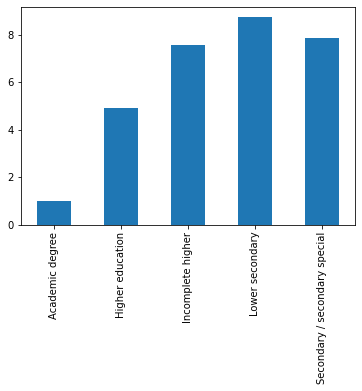

In [ ]:
((dff.groupby(['NAME_EDUCATION_TYPE'])['TARGET'].sum()/dff['NAME_EDUCATION_TYPE'].value_counts())*100).plot(kind='bar')

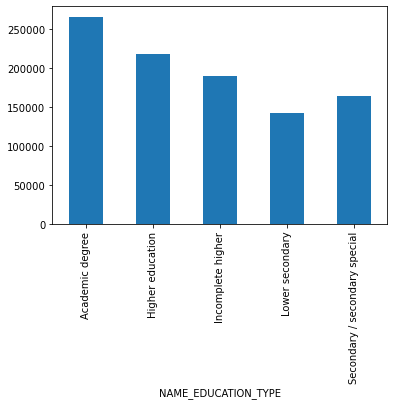

In [ ]:
dff.groupby('NAME_EDUCATION_TYPE')['AMT_INCOME_TOTAL'].mean().plot(kind='bar')
plt.show()

<AxesSubplot:xlabel='TARGET', ylabel='AMT_INCOME_TOTAL'>

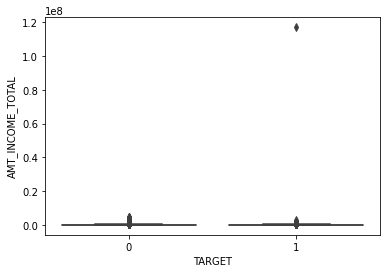

In [ ]:
sns.boxplot(x=('TARGET'),y=('AMT_INCOME_TOTAL'),data=dff)

In [ ]:
#How to treat this?

### NAME_FAMILY_STATUS

In [ ]:
dff['NAME_FAMILY_STATUS'].head()

0    Single / not married
1                 Married
2                 Married
3                 Married
4                 Married
Name: NAME_FAMILY_STATUS, dtype: object

In [ ]:
table2=pd.crosstab(dff['NAME_FAMILY_STATUS'],dff['TARGET'])
table2

TARGET,0,1
NAME_FAMILY_STATUS,,
Civil marriage,13819,1325
Married,86728,6047
Separated,10633,829
Single / not married,23170,2089
Unknown,1,0
Widow,8158,415


In [ ]:
observed_value=table2.values
observed_value

array([[13819,  1325],
       [86728,  6047],
       [10633,   829],
       [23170,  2089],
       [    1,     0],
       [ 8158,   415]], dtype=int64)

In [ ]:
stats.chi2_contingency(observed= observed_value)

(229.70094421579932,
 1.2396421414519475e-47,
 5,
 array([[1.40858949e+04, 1.05810513e+03],
        [8.62928484e+04, 6.48215160e+03],
        [1.06611547e+04, 8.00845288e+02],
        [2.34941639e+04, 1.76483608e+03],
        [9.30130406e-01, 6.98695942e-02],
        [7.97400797e+03, 5.98992031e+02]]))

In [ ]:
# p value<0.05 We reject Ho 

In [ ]:
dff['NAME_FAMILY_STATUS'].isnull().sum()*100/len(dff['NAME_FAMILY_STATUS'])

0.0

In [ ]:
dff['NAME_FAMILY_STATUS'].value_counts()

Married                 92775
Single / not married    25259
Civil marriage          15144
Separated               11462
Widow                    8573
Unknown                     1
Name: NAME_FAMILY_STATUS, dtype: int64

In [ ]:
((dff.groupby(['NAME_FAMILY_STATUS'])['TARGET'].sum()/dff['NAME_FAMILY_STATUS'].value_counts())*100)

Civil marriage          8.749340
Married                 6.517920
Separated               7.232595
Single / not married    8.270319
Unknown                 0.000000
Widow                   4.840779
dtype: float64

<AxesSubplot:>

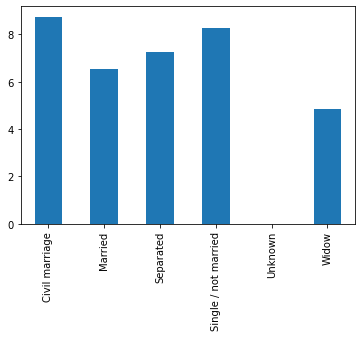

In [ ]:
((dff.groupby(['NAME_FAMILY_STATUS'])['TARGET'].sum()/dff['NAME_FAMILY_STATUS'].value_counts())*100).plot(kind='bar')

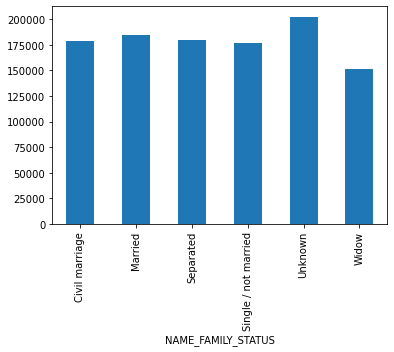

In [ ]:
dff.groupby('NAME_FAMILY_STATUS')['AMT_INCOME_TOTAL'].mean().plot(kind='bar')
plt.show()

### NAME_HOUSING_TYPE

In [ ]:
dff['NAME_HOUSING_TYPE'].head()

0    House / apartment
1    House / apartment
2    House / apartment
3    House / apartment
4    House / apartment
Name: NAME_HOUSING_TYPE, dtype: object

In [ ]:
table3=pd.crosstab(dff['NAME_HOUSING_TYPE'],dff['TARGET'])
table3

TARGET,0,1
NAME_HOUSING_TYPE,,
Co-op apartment,590,49
House / apartment,126776,9195
Municipal apartment,6725,586
Office apartment,1144,62
Rented apartment,1500,180
With parents,5774,633


In [ ]:
observed_value=table3.values
observed_value

array([[   590,     49],
       [126776,   9195],
       [  6725,    586],
       [  1144,     62],
       [  1500,    180],
       [  5774,    633]], dtype=int64)

In [ ]:
stats.chi2_contingency(observed= observed_value)

(147.64009875509274,
 4.24404179489797e-30,
 5,
 array([[5.94353329e+02, 4.46466707e+01],
        [1.26470761e+05, 9.50023859e+03],
        [6.80018340e+03, 5.10816603e+02],
        [1.12173727e+03, 8.42627306e+01],
        [1.56261908e+03, 1.17380918e+02],
        [5.95934551e+03, 4.47654490e+02]]))

In [ ]:
# p-value is less than 0.05 so we reject Ho

In [ ]:
dff['NAME_HOUSING_TYPE'].isnull().sum()*100/len(dff['NAME_HOUSING_TYPE'])

0.0

In [ ]:
dff['NAME_HOUSING_TYPE'].value_counts()

House / apartment      135971
Municipal apartment      7311
With parents             6407
Rented apartment         1680
Office apartment         1206
Co-op apartment           639
Name: NAME_HOUSING_TYPE, dtype: int64

In [ ]:
((dff.groupby(['NAME_HOUSING_TYPE'])['TARGET'].sum()/dff['NAME_HOUSING_TYPE'].value_counts())*100)

Co-op apartment         7.668232
House / apartment       6.762471
Municipal apartment     8.015319
Office apartment        5.140962
Rented apartment       10.714286
With parents            9.879819
dtype: float64

<AxesSubplot:>

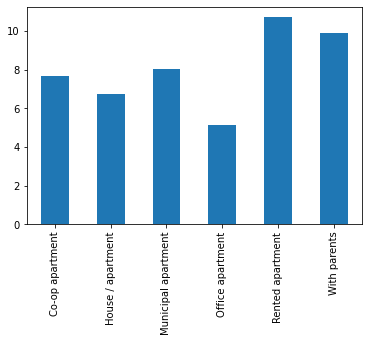

In [ ]:
((dff.groupby(['NAME_HOUSING_TYPE'])['TARGET'].sum()/dff['NAME_HOUSING_TYPE'].value_counts())*100).plot(kind='bar')

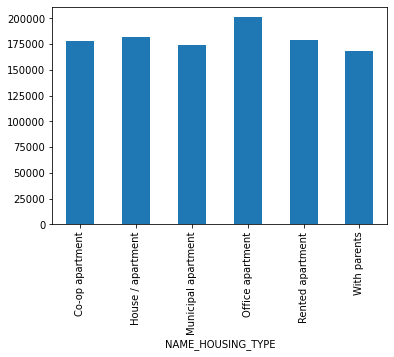

In [ ]:
dff.groupby('NAME_HOUSING_TYPE')['AMT_INCOME_TOTAL'].mean().plot(kind='bar')
plt.show()

# Yoganand THe yoga master

## NAME_FAMILY_STATUS-  Family status of the client

In [ ]:
dff['NAME_FAMILY_STATUS'].value_counts()

Married                 92775
Single / not married    25259
Civil marriage          15144
Separated               11462
Widow                    8573
Unknown                     1
Name: NAME_FAMILY_STATUS, dtype: int64

In [ ]:
dff['NAME_FAMILY_STATUS'].isnull().sum()/len(dff)*100

0.0

In [ ]:
(dff.groupby('NAME_FAMILY_STATUS')['TARGET'].sum()/dff['NAME_FAMILY_STATUS'].value_counts())*100

Civil marriage          8.749340
Married                 6.517920
Separated               7.232595
Single / not married    8.270319
Unknown                 0.000000
Widow                   4.840779
dtype: float64

<AxesSubplot:>

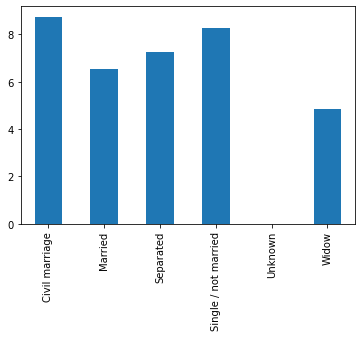

In [ ]:
(dff[dff['TARGET']==1]['NAME_FAMILY_STATUS'].value_counts()/dff['NAME_FAMILY_STATUS'].value_counts()*100).plot(kind='bar')

In [ ]:
pd.crosstab(dff['NAME_FAMILY_STATUS'],dff['TARGET'])

TARGET,0,1
NAME_FAMILY_STATUS,,
Civil marriage,13819,1325
Married,86728,6047
Separated,10633,829
Single / not married,23170,2089
Unknown,1,0
Widow,8158,415


In [ ]:
stats.chi2_contingency(pd.crosstab(dff['NAME_FAMILY_STATUS'],dff['TARGET']))

(229.70094421579932,
 1.2396421414519475e-47,
 5,
 array([[1.40858949e+04, 1.05810513e+03],
        [8.62928484e+04, 6.48215160e+03],
        [1.06611547e+04, 8.00845288e+02],
        [2.34941639e+04, 1.76483608e+03],
        [9.30130406e-01, 6.98695942e-02],
        [7.97400797e+03, 5.98992031e+02]]))

## NAME_HOUSING_TYPE - "What is the housing situation of the client    (renting or living with parents)

In [ ]:
dff['REGION_POPULATION_RELATIVE'].value_counts()

0.046220    8622
0.026392    8014
0.072508    7395
0.031329    6974
0.025164    6938
            ... 
0.003122     249
0.002134     179
0.001333     131
0.001417      65
0.000290       1
Name: REGION_POPULATION_RELATIVE, Length: 79, dtype: int64

1.560970780011686

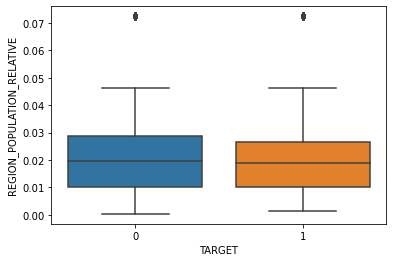

In [ ]:
sns.boxplot(y=dff['REGION_POPULATION_RELATIVE'],x=dff['TARGET'])
dff['REGION_POPULATION_RELATIVE'].skew()

In [ ]:
Q1 = dff['REGION_POPULATION_RELATIVE'].quantile(0.25)
Q2 = dff['REGION_POPULATION_RELATIVE'].quantile(0.5)
Q3 = dff['REGION_POPULATION_RELATIVE'].quantile(0.75)

IQR = Q3-Q1

UL = Q3+1.5*IQR
LL = Q1-1.5*IQR

print('UL',UL,'LL',LL)

UL 0.05660950000000001 LL -0.017914500000000003


In [ ]:
dff[(dff['REGION_POPULATION_RELATIVE'] > UL) | (dff['REGION_POPULATION_RELATIVE'] < LL)] # capping

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,LOG_AMT_INCOME_TOTAL,FLAG_DOC_SCORE,LOG_AMT_CREDIT,LOG_AMT_ANNUITY,LOG_AMT_GOODS_PRICE
33,0,Cash loans,M,N,Y,0,180000.0,1256400.0,40657.5,900000.0,...,0.0,0.0,0.0,0.0,8.0,12.100712,0.000009,14.043761,10.612939,13.710150
49,0,Cash loans,M,N,Y,0,225000.0,448272.0,28647.0,396000.0,...,0.0,0.0,0.0,1.0,8.0,12.323856,0.000075,13.013155,10.262804,12.889169
53,0,Cash loans,F,N,Y,0,270000.0,891072.0,45625.5,720000.0,...,0.0,0.0,0.0,0.0,4.0,12.506177,0.000009,13.700181,10.728222,13.487006
97,0,Cash loans,M,Y,Y,0,337500.0,876078.0,49050.0,765000.0,...,0.0,0.0,0.0,0.0,2.0,12.729321,0.000075,13.683210,10.800595,13.547631
126,0,Cash loans,M,N,Y,0,180000.0,254700.0,16407.0,225000.0,...,0.0,0.0,0.0,1.0,5.0,12.100712,0.000075,12.447842,9.705463,12.323856
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153061,0,Cash loans,F,Y,Y,0,225000.0,1827549.0,50386.5,1525500.0,...,NaN,NaN,NaN,NaN,NaN,12.323856,0.000075,14.418486,10.827479,14.237833
153149,0,Cash loans,F,N,Y,0,315000.0,1391130.0,77809.5,1305000.0,...,0.0,0.0,0.0,0.0,0.0,12.660328,0.000075,14.145627,11.262019,14.081714
153172,0,Cash loans,F,N,Y,0,440100.0,713889.0,45751.5,661500.0,...,NaN,NaN,NaN,NaN,NaN,12.994757,0.000009,13.478483,10.730980,13.402265
153202,0,Cash loans,F,Y,Y,1,292500.0,355536.0,18283.5,270000.0,...,0.0,0.0,0.0,1.0,1.0,12.586220,0.000075,12.781382,9.813754,12.506177


In [ ]:
dff['REGION_POPULATION_RELATIVE'] = dff['REGION_POPULATION_RELATIVE'].clip(lower = LL , upper = UL) # capping the outliers with ul and ll

0.9226728688030633

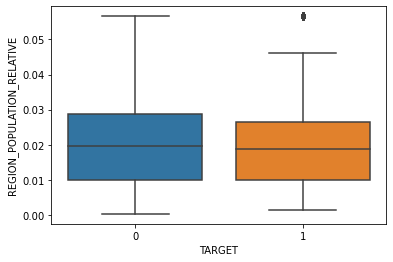

In [ ]:
sns.boxplot(y=dff['REGION_POPULATION_RELATIVE'],x=dff['TARGET'])
dff['REGION_POPULATION_RELATIVE'].skew()

In [ ]:
dff['REGION_POPULATION_RELATIVE'] = np.sqrt(dff['REGION_POPULATION_RELATIVE'])
print('Skewness',dff['REGION_POPULATION_RELATIVE'].skew())

Skewness 0.24400108021514827


<AxesSubplot:xlabel='TARGET', ylabel='REGION_POPULATION_RELATIVE'>

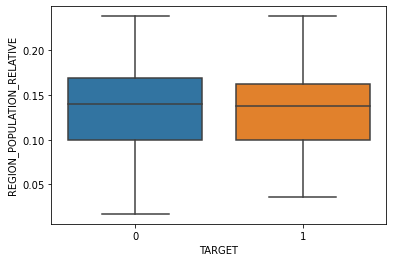

In [ ]:
sns.boxplot(y=dff['REGION_POPULATION_RELATIVE'],x=dff['TARGET'])

In [ ]:
from scipy.stats import shapiro

print(shapiro(dff['REGION_POPULATION_RELATIVE']))

# We can infer that the data is  not normal.

ShapiroResult(statistic=0.9735421538352966, pvalue=0.0)


C:\Users\saketh\anaconda3\lib\site-packages\scipy\stats\morestats.py:1681: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


In [ ]:
# Levene's Test in Python using Pingouin
import pingouin as pg
pg.homoscedasticity(dff, dv='TARGET', 
                    group='REGION_POPULATION_RELATIVE')

,W,pval,equal_var
levene,8.198667,7.562896e-89,False


In [ ]:
dff['TARGET'].value_counts()

0    142509
1     10705
Name: TARGET, dtype: int64

In [ ]:
default=dff[dff['TARGET']==1]['REGION_POPULATION_RELATIVE']
nondefault=dff[dff['TARGET']==0]['REGION_POPULATION_RELATIVE']

In [ ]:
len(default)

10705

In [ ]:
d1=default.sample(frac=1,random_state=42).reset_index(drop=True)

In [ ]:
nd1=np.random.choice(nondefault,size=24825,replace=False)

In [ ]:
#H0:Variable is not significant
#H1:Variable is significant

stats.mannwhitneyu(d1,nd1)

MannwhitneyuResult(statistic=125188918.0, pvalue=2.174092393605991e-18)

## DAYS_BIRTH - Client's age in days at the time of application	time only relative to the application

In [ ]:
dff['DAYS_BIRTH'].value_counts()

-14751    26
-13634    25
-18248    24
-13749    24
-15042    24
          ..
-8052      1
-8317      1
-25044     1
-24991     1
-25186     1
Name: DAYS_BIRTH, Length: 17270, dtype: int64

-0.11399454076271115

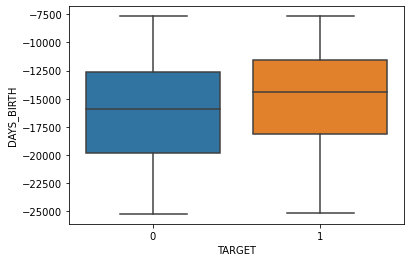

In [ ]:
sns.boxplot(y=dff['DAYS_BIRTH'],x=dff['TARGET'])
dff['DAYS_BIRTH'].skew()

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='DAYS_BIRTH', ylabel='Density'>

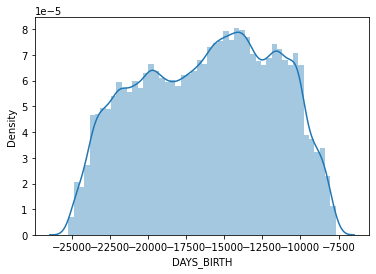

In [ ]:
sns.distplot(dff['DAYS_BIRTH'])

In [ ]:
stats.shapiro(dff['DAYS_BIRTH'])

C:\Users\saketh\anaconda3\lib\site-packages\scipy\stats\morestats.py:1681: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


ShapiroResult(statistic=0.9699382185935974, pvalue=0.0)

In [ ]:
# Levene's Test in Python using Pingouin
import pingouin as pg
pg.homoscedasticity(dff, dv='TARGET', 
                    group='DAYS_BIRTH')

,W,pval,equal_var
levene,1.001827,0.435354,True


In [ ]:
default=dff[dff['TARGET']==1]['DAYS_BIRTH']
nondefault=dff[dff['TARGET']==0]['DAYS_BIRTH']

In [ ]:
len(default)

10705

In [ ]:
d1=default.sample(frac=1,random_state=42).reset_index(drop=True)

In [ ]:
nd1=np.random.choice(nondefault,size=24825,replace=False)

In [ ]:
#H0:Variable is not significant
#H1:Variable is significant

stats.mannwhitneyu(d1,nd1)

MannwhitneyuResult(statistic=111647398.5, pvalue=7.2328123839426685e-127)

## DAYS_EMPLOYED - How many days before the application the person started current employment	time only relative to the application

In [ ]:
dff['DAYS_EMPLOYED'].value_counts()

 365243    26929
-199          85
-116          82
-212          82
-224          81
           ...  
-11823         1
-9776          1
-7849          1
-11951         1
 0             1
Name: DAYS_EMPLOYED, Length: 11176, dtype: int64

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


1.702803326081622

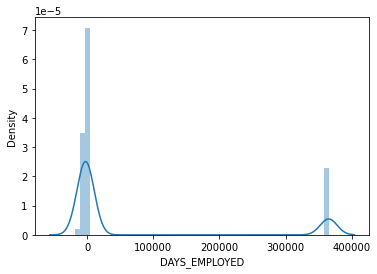

In [ ]:
sns.distplot(dff['DAYS_EMPLOYED'])
dff['DAYS_EMPLOYED'].skew()

<AxesSubplot:xlabel='TARGET', ylabel='DAYS_EMPLOYED'>

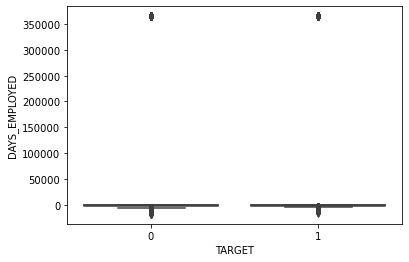

In [ ]:
sns.boxplot(y=dff['DAYS_EMPLOYED'],x=dff['TARGET'])

In [ ]:
Q1 = dff['DAYS_EMPLOYED'].quantile(0.25)
Q2 = dff['DAYS_EMPLOYED'].quantile(0.5)
Q3 = dff['DAYS_EMPLOYED'].quantile(0.75)

IQR = Q3-Q1

UL = Q3+1.5*IQR
LL = Q1-IQR


In [ ]:
dff['DAYS_EMPLOYED'] = dff['DAYS_EMPLOYED'].clip(lower = LL , upper = UL) # capping the outliers with ul and ll

0.40578493237289587

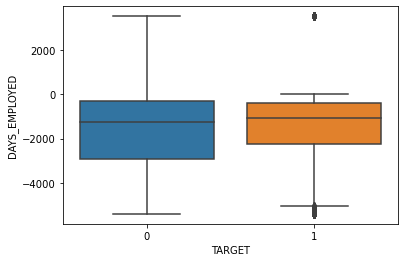

In [ ]:
sns.boxplot(y=dff['DAYS_EMPLOYED'],x=dff['TARGET'])
dff['DAYS_EMPLOYED'].skew()

<AxesSubplot:xlabel='TARGET', ylabel='DAYS_EMPLOYED'>

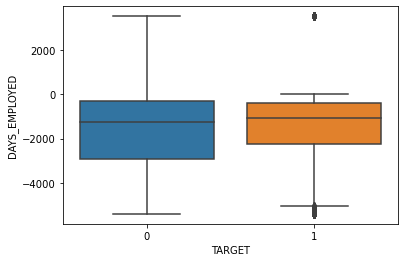

In [ ]:
sns.boxplot(y=dff['DAYS_EMPLOYED'],x=dff['TARGET'])

In [ ]:
stats.shapiro(dff['DAYS_EMPLOYED'])

# We can infer that data is normal.

C:\Users\saketh\anaconda3\lib\site-packages\scipy\stats\morestats.py:1681: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


ShapiroResult(statistic=0.9076656103134155, pvalue=0.0)

In [ ]:
# Levene's Test in Python using Pingouin
import pingouin as pg
pg.homoscedasticity(dff, dv='TARGET', 
                    group='DAYS_EMPLOYED')

,W,pval,equal_var
levene,1.125323,3.941152e-10,False


In [ ]:
default=dff[dff['TARGET']==1]['DAYS_EMPLOYED']
nondefault=dff[dff['TARGET']==0]['DAYS_EMPLOYED']

In [ ]:
len(default)

10705

In [ ]:
d1=default.sample(frac=1,random_state=42).reset_index(drop=True)

In [ ]:
nd1=np.random.choice(nondefault,size=24825,replace=False)

In [ ]:
#H0:Variable is not significant
#H1:Variable is significant

stats.mannwhitneyu(d1,nd1)

MannwhitneyuResult(statistic=126157094.0, pvalue=1.568871823490935e-14)

## DAYS_REGISTRATION - How many days before the application did client change his registration	time only relative to the application

In [ ]:
dff['DAYS_REGISTRATION'].value_counts()

-7.0        55
-4.0        50
-1.0        48
-14.0       45
-9.0        45
            ..
-15570.0     1
-12420.0     1
-16704.0     1
-14914.0     1
-12814.0     1
Name: DAYS_REGISTRATION, Length: 14987, dtype: int64

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


-0.46724194231639504

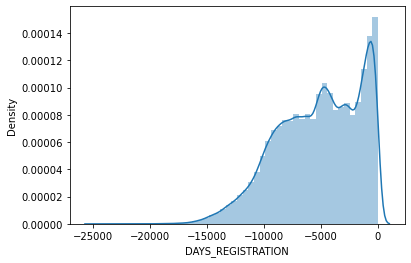

In [ ]:
sns.distplot(dff['DAYS_REGISTRATION'])
dff['DAYS_REGISTRATION'].skew()

<AxesSubplot:xlabel='TARGET', ylabel='DAYS_REGISTRATION'>

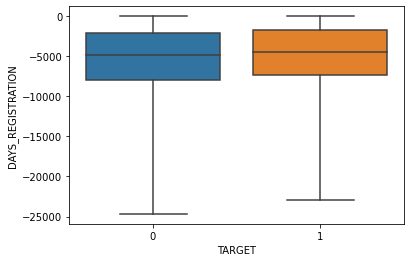

In [ ]:
sns.boxplot(y=dff['DAYS_REGISTRATION'],x=dff['TARGET'] , whis = 3)

In [ ]:
# Outlier treatment

Q1 = dff['DAYS_REGISTRATION'].quantile(0.25)
Q2 = dff['DAYS_REGISTRATION'].quantile(0.5)
Q3 = dff['DAYS_REGISTRATION'].quantile(0.75)

IQR = Q3-Q1

UL = Q3+3*IQR
LL = Q1-3*IQR

In [ ]:
dff['DAYS_REGISTRATION'] = dff['DAYS_REGISTRATION'].clip(lower = LL , upper = UL) # capping the outliers with ul and ll

-0.46724194231639504

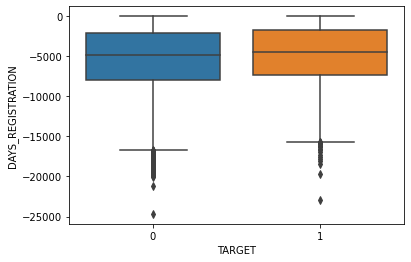

In [ ]:
sns.boxplot(y=dff['DAYS_REGISTRATION'],x=dff['TARGET'])
dff['DAYS_REGISTRATION'].skew()

In [ ]:
# As the data is left skewed we go for Transformation
dff['DAYS_REGISTRATION'] = np.sqrt(abs(dff['DAYS_REGISTRATION']))
dff['DAYS_REGISTRATION'].skew()

-0.269030720483571

<AxesSubplot:xlabel='TARGET', ylabel='DAYS_REGISTRATION'>

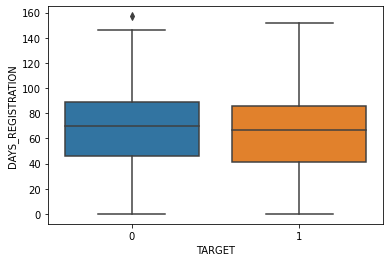

In [ ]:
sns.boxplot(y=dff['DAYS_REGISTRATION'],x=dff['TARGET'])

In [ ]:
stats.shapiro(dff['DAYS_REGISTRATION'])

# We can say that data is normal.

C:\Users\saketh\anaconda3\lib\site-packages\scipy\stats\morestats.py:1681: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


ShapiroResult(statistic=0.9777265787124634, pvalue=0.0)

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='DAYS_REGISTRATION', ylabel='Density'>

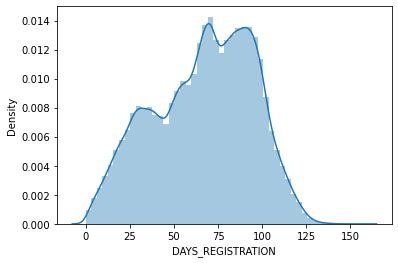

In [ ]:
sns.distplot(dff['DAYS_REGISTRATION'])

In [ ]:
# Levene's Test in Python using Pingouin
import pingouin as pg
pg.homoscedasticity(dff, dv='TARGET', 
                    group='DAYS_REGISTRATION')

,W,pval,equal_var
levene,0.860743,1.0,True


In [ ]:
default=dff[dff['TARGET']==1]['DAYS_REGISTRATION']
nondefault=dff[dff['TARGET']==0]['DAYS_REGISTRATION']

In [ ]:
len(default)

10705

In [ ]:
d1=np.array(default.sample(frac=1,random_state=42).reset_index(drop=True))

In [ ]:
nd1=np.random.choice(nondefault,size=24825,replace=False)

In [ ]:
d1.shape

(10705,)

In [ ]:
#H0:Variable is not significant
#H1:Variable is significant

stats.mannwhitneyu(d1,nd1)

MannwhitneyuResult(statistic=123539430.0, pvalue=3.3084245696556296e-26)

## NITISH

## DAYS_ID_PUBLISH

In [ ]:
dff['DAYS_ID_PUBLISH'].isnull().sum()

0

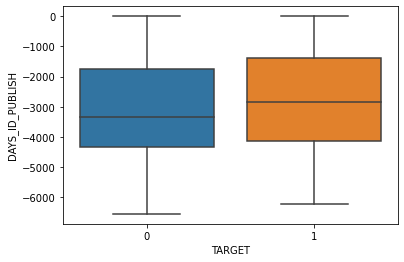

In [ ]:
sns.boxplot(y=dff['DAYS_ID_PUBLISH'],x=dff['TARGET'])
plt.show()

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='DAYS_ID_PUBLISH', ylabel='Density'>

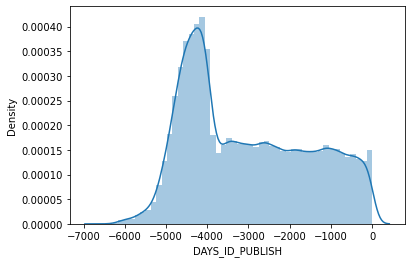

In [ ]:
sns.distplot(dff['DAYS_ID_PUBLISH'])

In [ ]:
dff['DAYS_ID_PUBLISH'].skew()

0.37559781221625294

In [ ]:
Target1=dff[dff['TARGET']==1]['DAYS_ID_PUBLISH']

In [ ]:
Target1

0        -2120
11       -1827
20       -1029
52       -3190
75       -1082
          ... 
153174   -2772
153175   -2580
153195   -4704
153203      -9
153212    -931
Name: DAYS_ID_PUBLISH, Length: 10705, dtype: int64

In [ ]:
len(Target1)

10705

In [ ]:
Target2=dff[dff['TARGET']==0]['DAYS_ID_PUBLISH']

In [ ]:
Target2

1         -291
2        -3227
3        -4911
4        -2056
5        -1259
          ... 
153208   -2357
153209   -1982
153210   -4090
153211   -5150
153213    -410
Name: DAYS_ID_PUBLISH, Length: 142509, dtype: int64

In [ ]:
sample=np.random.choice(Target2,size=24825,replace=True)


In [ ]:
len(sample)

24825

In [ ]:
stats.levene(Target1.values,sample)

LeveneResult(statistic=15.004277819782695, pvalue=0.00010745995585801497)

In [ ]:
stats.shapiro(Target1.values)

C:\Users\saketh\anaconda3\lib\site-packages\scipy\stats\morestats.py:1681: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


ShapiroResult(statistic=0.9487776756286621, pvalue=0.0)

In [ ]:
stats.shapiro(sample)

ShapiroResult(statistic=0.9353572130203247, pvalue=0.0)

In [ ]:
stats.mannwhitneyu(Target1.values,sample)

MannwhitneyuResult(statistic=117821015.0, pvalue=6.657798026740153e-65)

## FLAG_MOBIL

In [ ]:
dff.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 153214 entries, 0 to 153213
Columns: 116 entries, TARGET to LOG_AMT_GOODS_PRICE
dtypes: float64(80), int64(20), object(16)
memory usage: 141.8+ MB


In [ ]:
dff['FLAG_MOBIL'].isnull().sum()

0

In [ ]:
dff['FLAG_MOBIL'].value_counts()

1    153213
0         1
Name: FLAG_MOBIL, dtype: int64

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='FLAG_MOBIL', ylabel='count'>

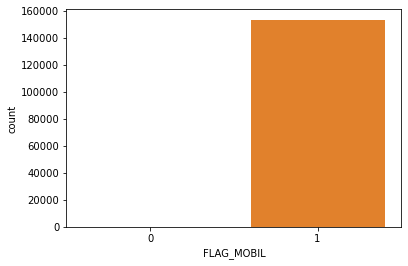

In [ ]:
sns.countplot(dff['FLAG_MOBIL'])

In [ ]:
dff['FLAG_MOBIL'].value_counts() # can remove this column as no variation in data

1    153213
0         1
Name: FLAG_MOBIL, dtype: int64

In [ ]:
d=dff[dff['TARGET']==1]


In [ ]:
d['FLAG_MOBIL'].value_counts()

1    10705
Name: FLAG_MOBIL, dtype: int64

<AxesSubplot:>

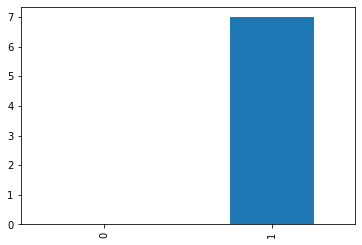

In [ ]:
(d['FLAG_MOBIL'].value_counts()*100/dff['FLAG_MOBIL'].value_counts()).plot(kind='bar')

In [ ]:
table1=pd.crosstab(dff['FLAG_MOBIL'],dff['TARGET'])

In [ ]:
observed_values=table1.values

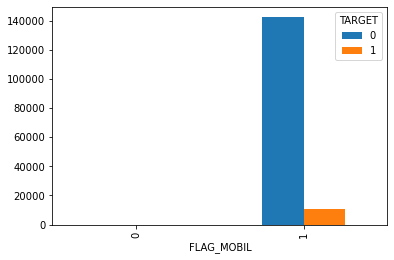

In [ ]:
table1=pd.crosstab(dff['FLAG_MOBIL'],dff['TARGET']).plot(kind='bar')

In [ ]:
fm=stats.chi2_contingency(observed_values)

In [ ]:
fm

(2.8468924452658655,
 0.09155074098326633,
 1,
 array([[9.30130406e-01, 6.98695942e-02],
        [1.42508070e+05, 1.07049301e+04]]))

## FLAG_EMP_PHONE

In [ ]:
dff['FLAG_EMP_PHONE'].isnull().sum()

0

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='FLAG_EMP_PHONE', ylabel='count'>

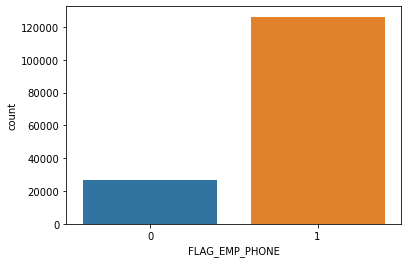

In [ ]:
sns.countplot(dff['FLAG_EMP_PHONE'])

In [ ]:
dff['FLAG_EMP_PHONE'].value_counts()

1    126278
0     26936
Name: FLAG_EMP_PHONE, dtype: int64

In [ ]:
d['FLAG_EMP_PHONE'].value_counts()

1    9415
0    1290
Name: FLAG_EMP_PHONE, dtype: int64

<AxesSubplot:>

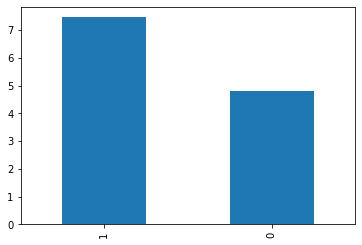

In [ ]:
(d['FLAG_EMP_PHONE'].value_counts()*100/dff['FLAG_EMP_PHONE'].value_counts()).plot(kind='bar')

In [ ]:
table2=pd.crosstab(dff['FLAG_EMP_PHONE'],dff['TARGET'])

In [ ]:
observed_values2=table2.values

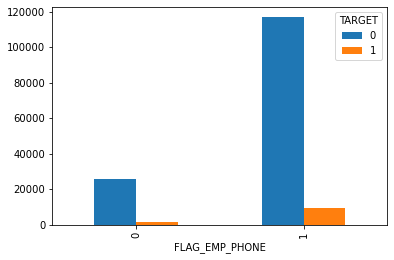

In [ ]:
table2=pd.crosstab(dff['FLAG_EMP_PHONE'],dff['TARGET']).plot(kind='bar')

In [ ]:
fem=stats.chi2_contingency(observed_values2)

In [ ]:
fem

(242.5079261617122,
 1.1165476658727502e-54,
 1,
 array([[ 25053.99261164,   1882.00738836],
        [117455.00738836,   8822.99261164]]))

## FLAG_WORK_PHONE

In [ ]:
dff['FLAG_WORK_PHONE'].isnull().sum()

0

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='FLAG_WORK_PHONE', ylabel='count'>

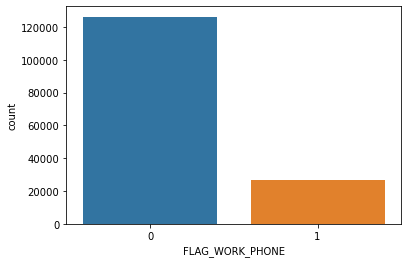

In [ ]:
sns.countplot(dff['FLAG_WORK_PHONE'])

In [ ]:
dff['FLAG_WORK_PHONE'].value_counts()

0    126198
1     27016
Name: FLAG_WORK_PHONE, dtype: int64

In [ ]:
d['FLAG_WORK_PHONE'].value_counts()

0    8479
1    2226
Name: FLAG_WORK_PHONE, dtype: int64

<AxesSubplot:>

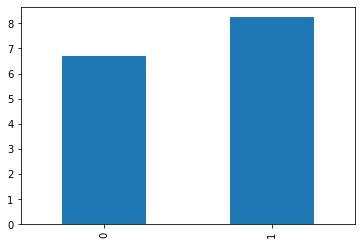

In [ ]:
(d['FLAG_WORK_PHONE'].value_counts()*100/dff['FLAG_WORK_PHONE'].value_counts()).plot(kind='bar')

In [ ]:
table3=pd.crosstab(dff['FLAG_WORK_PHONE'],dff['TARGET'])

In [ ]:
observed_values3=table3.values

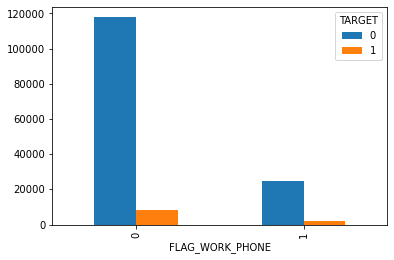

In [ ]:
table3=pd.crosstab(dff['FLAG_WORK_PHONE'],dff['TARGET']).plot(kind='bar')

In [ ]:
fwp=stats.chi2_contingency(observed_values3)

In [ ]:
fwp

(78.95453450155345,
 6.355588960473517e-19,
 1,
 array([[117380.59695589,   8817.40304411],
        [ 25128.40304411,   1887.59695589]]))

## FLAG_CONT_MOBILE

In [ ]:
dff['FLAG_CONT_MOBILE'].isnull().sum()

0

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='FLAG_CONT_MOBILE', ylabel='count'>

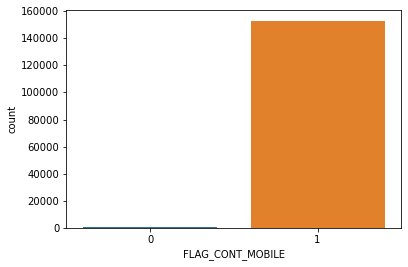

In [ ]:
sns.countplot(dff['FLAG_CONT_MOBILE'])

In [ ]:
dff['FLAG_CONT_MOBILE'].value_counts() # even this column is highly imbalanced

1    152868
0       346
Name: FLAG_CONT_MOBILE, dtype: int64

In [ ]:
d['FLAG_CONT_MOBILE'].value_counts()

1    10677
0       28
Name: FLAG_CONT_MOBILE, dtype: int64

<AxesSubplot:>

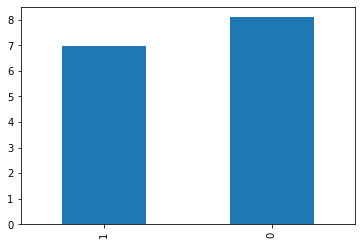

In [ ]:
(d['FLAG_CONT_MOBILE'].value_counts()*100/dff['FLAG_CONT_MOBILE'].value_counts()).plot(kind='bar')

In [ ]:
table4=pd.crosstab(dff['FLAG_CONT_MOBILE'],dff['TARGET'])

In [ ]:
observed_values4=table4.values

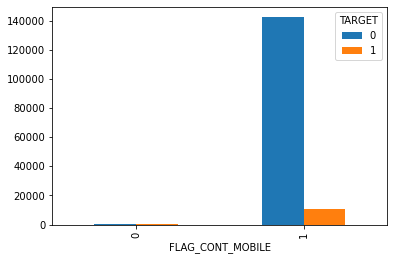

In [ ]:
table4=pd.crosstab(dff['FLAG_CONT_MOBILE'],dff['TARGET']).plot(kind='bar')

In [ ]:
fcm=stats.chi2_contingency(observed_values4)

In [ ]:
fcm

(0.49282015634513965,
 0.482671987161712,
 1,
 array([[3.21825120e+02, 2.41748796e+01],
        [1.42187175e+05, 1.06808251e+04]]))

## FLAG_PHONE

In [ ]:
dff['FLAG_PHONE'].isnull().sum()

0

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='FLAG_PHONE', ylabel='count'>

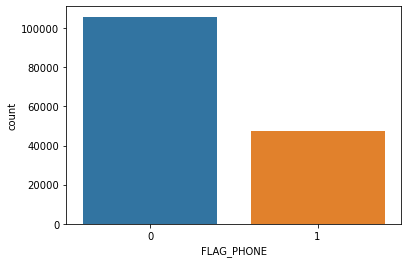

In [ ]:
sns.countplot(dff['FLAG_PHONE'])

In [ ]:
dff['FLAG_PHONE'].value_counts()

0    105709
1     47505
Name: FLAG_PHONE, dtype: int64

In [ ]:
d['FLAG_PHONE'].value_counts()

0    7812
1    2893
Name: FLAG_PHONE, dtype: int64

<AxesSubplot:>

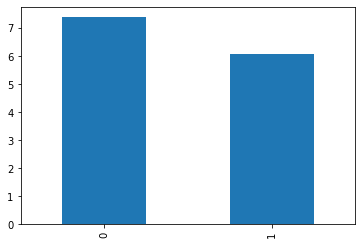

In [ ]:
(d['FLAG_PHONE'].value_counts()*100/dff['FLAG_PHONE'].value_counts()).plot(kind='bar')

In [ ]:
table5=pd.crosstab(dff['FLAG_PHONE'],dff['TARGET'])

In [ ]:
observed_values5=table5.values

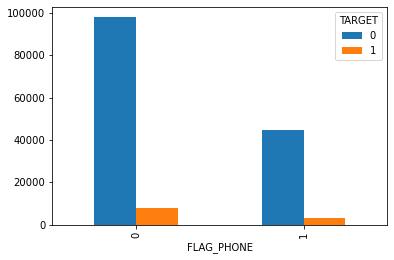

In [ ]:
table5=pd.crosstab(dff['FLAG_PHONE'],dff['TARGET']).plot(kind='bar')

In [ ]:
fp=stats.chi2_contingency(observed_values5)

In [ ]:
fp

(85.06104709062728,
 2.8929394841303675e-20,
 1,
 array([[98323.15507069,  7385.84492931],
        [44185.84492931,  3319.15507069]]))

## FLAG_EMAIL

In [ ]:
dff['FLAG_EMAIL'].isnull().sum()

0

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='FLAG_EMAIL', ylabel='count'>

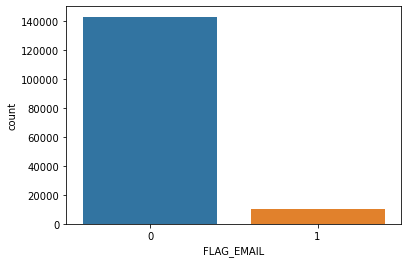

In [ ]:
sns.countplot(dff['FLAG_EMAIL'])

In [ ]:
dff['FLAG_EMAIL'].value_counts()

0    143049
1     10165
Name: FLAG_EMAIL, dtype: int64

In [ ]:
d['FLAG_EMAIL'].value_counts()

0    10000
1      705
Name: FLAG_EMAIL, dtype: int64

<AxesSubplot:>

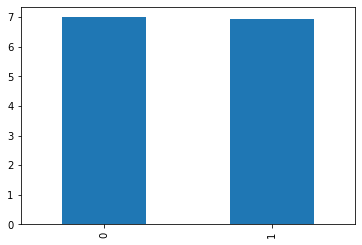

In [ ]:
(d['FLAG_EMAIL'].value_counts()*100/dff['FLAG_EMAIL'].value_counts()).plot(kind='bar')

In [ ]:
table6=pd.crosstab(dff['FLAG_EMAIL'],dff['TARGET'])

In [ ]:
observed_values6=table6.values

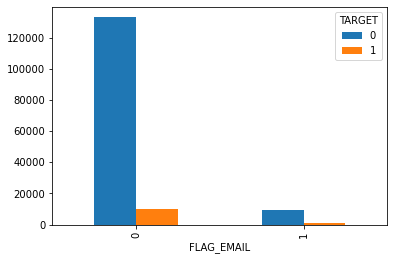

In [ ]:
table6=pd.crosstab(dff['FLAG_EMAIL'],dff['TARGET']).plot(kind='bar')

In [ ]:
fe=stats.chi2_contingency(observed_values6)

In [ ]:
fe

(0.03618862107556386,
 0.8491264978234279,
 1,
 array([[133054.22442466,   9994.77557534],
        [  9454.77557534,    710.22442466]]))

# Mahesh

In [ ]:
len(dff)

153214

In [ ]:
d=dff[dff['TARGET']==1]

## REGION_RATING_CLIENT_W_CITY - Our rating of the region where client lives with taking city into account (1,2,3)

In [ ]:
reg_w=pd.crosstab(dff['TARGET'],dff['REGION_RATING_CLIENT_W_CITY'])

<AxesSubplot:>

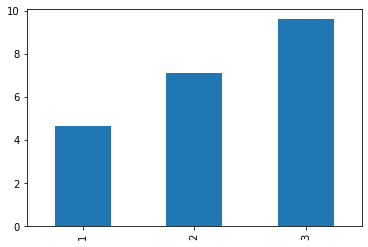

In [ ]:
(d['REGION_RATING_CLIENT_W_CITY'].value_counts()*100/(dff['REGION_RATING_CLIENT_W_CITY'].value_counts())).plot(kind='bar')

<AxesSubplot:xlabel='TARGET'>

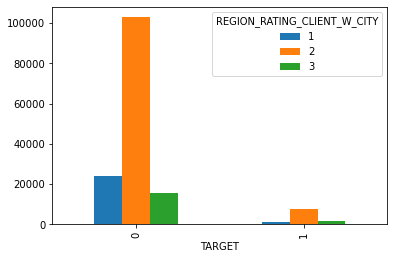

In [ ]:
reg_w.plot(kind='bar')

In [ ]:
# Ho: columns are independent
# Ha: columns have significant relationship

In [ ]:
stats.chi2_contingency(reg_w)

(393.76813233868637,
 3.121307011815265e-86,
 2,
 array([[ 23560.20317987, 102971.01670866,  15977.78011148],
        [  1769.79682013,   7734.98329134,   1200.21988852]]))

In [ ]:
# pvalue = 1.2 * 10 power -248 <<< 0.05. Hence we reject null. So our columns are significantly related.

## CNT_FAM_MEMBERS-How many family members does client have

In [ ]:
CNT_FAM_tar=pd.crosstab(dff['TARGET'],dff['CNT_FAM_MEMBERS'])

<AxesSubplot:>

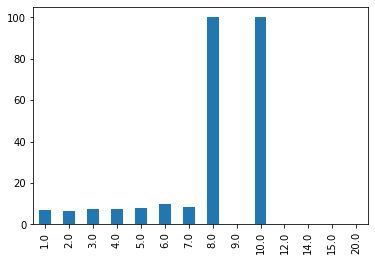

In [ ]:
(d['CNT_FAM_MEMBERS'].value_counts()*100/(dff['CNT_FAM_MEMBERS'].value_counts())).plot(kind='bar')

In [ ]:
lis2=[]
for i in dff['CNT_FAM_MEMBERS']:
    if i<=4:
        lis2.append('small family')
    elif i>4:
        lis2.append('large family')

lis3=pd.Series(lis2)
dff['CNT_FAM_MEMBERS_']=pd.DataFrame(lis3)
dff['CNT_FAM_MEMBERS_'].value_counts()

small family    151878
large family      1335
Name: CNT_FAM_MEMBERS_, dtype: int64

In [ ]:
#do visualization

In [ ]:
CNT_FAM_CH=pd.crosstab(dff['TARGET'],dff['CNT_FAM_MEMBERS'])

In [ ]:
stats.chi2_contingency(CNT_FAM_CH)

(111.14281128670999,
 1.1154693922565687e-17,
 13,
 array([[3.52016981e+04, 7.14479321e+04, 2.44754395e+04, 1.01412068e+04,
         1.10406425e+03, 1.12545724e+02, 1.11615594e+01, 4.65064975e+00,
         3.72051980e+00, 9.30129950e-01, 9.30129950e-01, 1.86025990e+00,
         9.30129950e-01, 9.30129950e-01],
        [2.64430192e+03, 5.36706791e+03, 1.83856050e+03, 7.61793157e+02,
         8.29357496e+01, 8.45427607e+00, 8.38440602e-01, 3.49350251e-01,
         2.79480201e-01, 6.98700502e-02, 6.98700502e-02, 1.39740100e-01,
         6.98700502e-02, 6.98700502e-02]]))

In [ ]:
# pvalue=0 <<< 0.05. Hence we reject null. So our columns are significantly related.

In [ ]:
dff['CNT_FAM_MEMBERS'].value_counts()

2.0     76815
1.0     37846
3.0     26314
4.0     10903
5.0      1187
6.0       121
7.0        12
8.0         5
9.0         4
14.0        2
15.0        1
12.0        1
20.0        1
10.0        1
Name: CNT_FAM_MEMBERS, dtype: int64

In [ ]:
# Ho: columns are independent
# Ha: columns have significant relationship

In [ ]:
CNT_FAM_tar

CNT_FAM_MEMBERS,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,12.0,14.0,15.0,20.0
TARGET,,,,,,,,,,,,,,
0,35138,71705,24340,10101,1095,109,11,0,4,0,1,2,1,1
1,2708,5110,1974,802,92,12,1,5,0,1,0,0,0,0


In [ ]:
stats.chi2_contingency(CNT_FAM_tar)

(111.14281128670999,
 1.1154693922565687e-17,
 13,
 array([[3.52016981e+04, 7.14479321e+04, 2.44754395e+04, 1.01412068e+04,
         1.10406425e+03, 1.12545724e+02, 1.11615594e+01, 4.65064975e+00,
         3.72051980e+00, 9.30129950e-01, 9.30129950e-01, 1.86025990e+00,
         9.30129950e-01, 9.30129950e-01],
        [2.64430192e+03, 5.36706791e+03, 1.83856050e+03, 7.61793157e+02,
         8.29357496e+01, 8.45427607e+00, 8.38440602e-01, 3.49350251e-01,
         2.79480201e-01, 6.98700502e-02, 6.98700502e-02, 1.39740100e-01,
         6.98700502e-02, 6.98700502e-02]]))

In [ ]:
# pvalue = 2.73 * 10 power -27 <<< 0.05. Hence we reject null. So our columns are significantly related.

## REGION_RATING_CLIENT-Our rating of the region where client lives (1,2,3)

In [ ]:
Region_r=pd.crosstab(dff['TARGET'],dff['REGION_RATING_CLIENT'])

<AxesSubplot:>

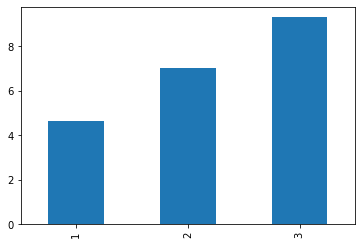

In [ ]:
(d['REGION_RATING_CLIENT'].value_counts()*100/(dff['REGION_RATING_CLIENT'].value_counts())).plot(kind='bar')

<AxesSubplot:xlabel='TARGET'>

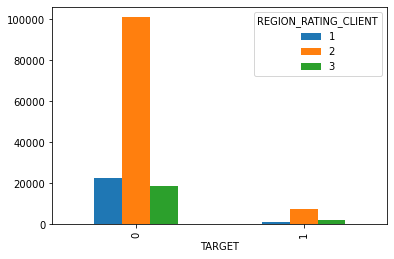

In [ ]:
Region_r.plot(kind='bar')

In [ ]:
# Ho: columns are independent
# Ha: columns have significant relationship

In [ ]:
stats.chi2_contingency(Region_r)

(372.3941327755275,
 1.3666003298827954e-81,
 2,
 array([[ 21969.68018588, 101089.36289765,  19449.95691647],
        [  1650.31981412,   7593.63710235,   1461.04308353]]))

In [ ]:
# pvalue = 3.56 * 10 power -232 <<< 0.05. Hence we reject null. So our columns are significantly related.

## WEEKDAY_APPR_PROCESS_START - On which day of the week did the client apply for the loan

In [ ]:
WEEKDAY_Tar=pd.crosstab(dff['TARGET'],dff['WEEKDAY_APPR_PROCESS_START'])

<AxesSubplot:>

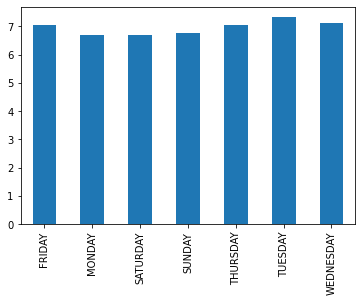

In [ ]:
(d['WEEKDAY_APPR_PROCESS_START'].value_counts()*100/(dff['WEEKDAY_APPR_PROCESS_START'].value_counts())).plot(kind='bar')

<AxesSubplot:xlabel='TARGET'>

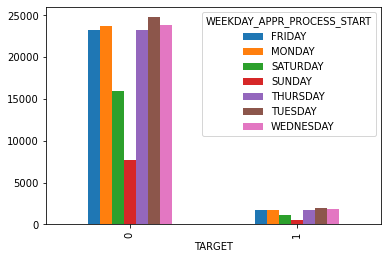

In [ ]:
WEEKDAY_Tar.plot(kind='bar')

In [ ]:
# Ho: columns are independent
# Ha: columns have significant relationship

In [ ]:
stats.chi2_contingency(WEEKDAY_Tar)

(12.178645183632264,
 0.05810006968737961,
 6,
 array([[23299.76666623, 23656.00661167, 15897.78889658,  7642.88154477,
         23280.23392771, 24860.52548723, 23871.79686582],
        [ 1750.23333377,  1776.99338833,  1194.21110342,   574.11845523,
          1748.76607229,  1867.47451277,  1793.20313418]]))

In [ ]:
## pvalue = 0.016 <<< 0.05. Hence we reject null. So our columns are significantly related.

## HOUR_APPR_PROCESS_START-Approximately at what hour did the client apply for the loan

<AxesSubplot:>

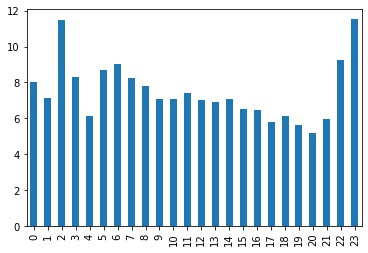

In [ ]:
(d['HOUR_APPR_PROCESS_START'].value_counts()*100/(dff['HOUR_APPR_PROCESS_START'].value_counts())).plot(kind='bar')

In [ ]:
lis=[]
for i in dff['HOUR_APPR_PROCESS_START']:
    if i<=8:
        lis.append('shift1')
    elif 8<i<=16:
        lis.append('shift2')
    elif 16<i<=24:
        lis.append('shift3')

lis1=pd.Series(lis)
dff['HOUR_APPR_PROCESS_START']=lis1
dff['HOUR_APPR_PROCESS_START'].value_counts()

shift2    118247
shift1     17704
shift3     17263
Name: HOUR_APPR_PROCESS_START, dtype: int64

In [ ]:
HOUR_Tar=pd.crosstab(dff['TARGET'],dff['HOUR_APPR_PROCESS_START'])

<AxesSubplot:xlabel='TARGET'>

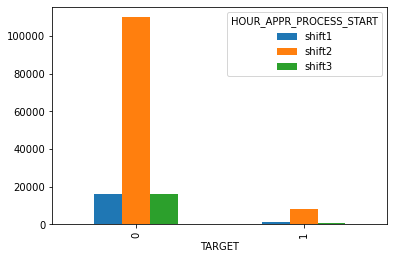

In [ ]:
HOUR_Tar.plot(kind ='bar')

In [ ]:
# Ho: columns are independent
# Ha: columns have significant relationship

In [ ]:
stats.chi2_contingency(HOUR_Tar)

(68.4171044126256,
 1.3912800026162063e-15,
 2,
 array([[ 16467.02870495, 109985.13009908,  16056.84119597],
        [  1236.97129505,   8261.86990092,   1206.15880403]]))

In [ ]:
## pvalue =7.19 * 10 power -44 <<< 0.05. Hence we reject null. So our columns are significantly related.

# Kedar

## REG_REGION_NOT_LIVE_REGION
Flag if client's permanent address does not match contact address (1=different, 0=same, at region level)

In [ ]:
dff[dff['REG_REGION_NOT_LIVE_REGION'].isnull()==True]
#no null values

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,LOG_AMT_INCOME_TOTAL,FLAG_DOC_SCORE,LOG_AMT_CREDIT,LOG_AMT_ANNUITY,LOG_AMT_GOODS_PRICE,CNT_FAM_MEMBERS_


In [ ]:
dff['REG_REGION_NOT_LIVE_REGION'].value_counts()

0    151345
1      1869
Name: REG_REGION_NOT_LIVE_REGION, dtype: int64

In [ ]:
o=pd.crosstab(dff['REG_REGION_NOT_LIVE_REGION'],dff['TARGET'])
o

TARGET,0,1
REG_REGION_NOT_LIVE_REGION,,
0,140766,10579
1,1743,126


In [ ]:
(dff.groupby('REG_REGION_NOT_LIVE_REGION')['TARGET'].sum()/dff['REG_REGION_NOT_LIVE_REGION'].value_counts())*100
#both are similar. looks like no change according to this

C:\Users\saketh\anaconda3\lib\site-packages\IPython\core\displayhook.py:275: UserWarning: Output cache limit (currently 1000 entries) hit.
Flushing oldest 200 entries.
  warn('Output cache limit (currently {sz} entries) hit.\n'


REG_REGION_NOT_LIVE_REGION
0    6.989990
1    6.741573
dtype: float64

<AxesSubplot:>

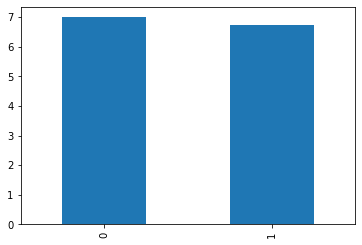

In [ ]:
(dff[dff['TARGET']==1]['REG_REGION_NOT_LIVE_REGION'].value_counts()/dff['REG_REGION_NOT_LIVE_REGION'].value_counts()*100).plot(kind='bar')

<AxesSubplot:xlabel='REG_REGION_NOT_LIVE_REGION'>

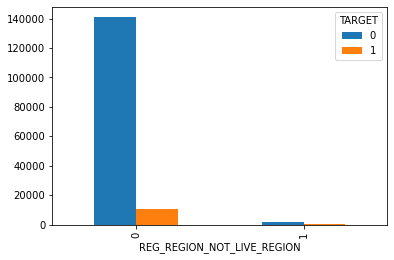

In [ ]:
pd.crosstab(dff['REG_REGION_NOT_LIVE_REGION'],dff['TARGET']).plot(kind='bar')
#more values of REG_REGION_NOT_LIVE_REGION=0 are present

In [ ]:
stat,O,d,arr=stats.chi2_contingency(o)

In [ ]:
O
#this column also effects target according to p(o) value

0.7091082403206508

## REG_REGION_NOT_WORK_REGION
Flag if client's permanent address does not match work address (1=different, 0=same, at region level)

In [ ]:
dff[dff['REG_REGION_NOT_WORK_REGION'].isnull()==True]
#no null values

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,LOG_AMT_INCOME_TOTAL,FLAG_DOC_SCORE,LOG_AMT_CREDIT,LOG_AMT_ANNUITY,LOG_AMT_GOODS_PRICE,CNT_FAM_MEMBERS_


In [ ]:
dff['REG_REGION_NOT_WORK_REGION'].value_counts()

0    146152
1      7062
Name: REG_REGION_NOT_WORK_REGION, dtype: int64

In [ ]:
p=pd.crosstab(dff['REG_REGION_NOT_WORK_REGION'],dff['TARGET'])
p

TARGET,0,1
REG_REGION_NOT_WORK_REGION,,
0,135947,10205
1,6562,500


In [ ]:
(dff.groupby('REG_REGION_NOT_WORK_REGION')['TARGET'].sum()/dff['REG_REGION_NOT_WORK_REGION'].value_counts())*100
#both are similar. looks like no change according to this

REG_REGION_NOT_WORK_REGION
0    6.982457
1    7.080147
dtype: float64

<AxesSubplot:>

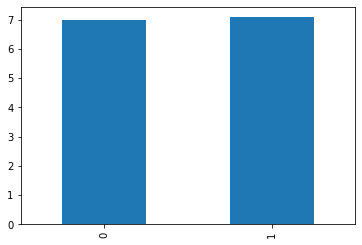

In [ ]:
(dff[dff['TARGET']==1]['REG_REGION_NOT_WORK_REGION'].value_counts()/dff['REG_REGION_NOT_WORK_REGION'].value_counts()*100).plot(kind='bar')

<AxesSubplot:xlabel='REG_REGION_NOT_WORK_REGION'>

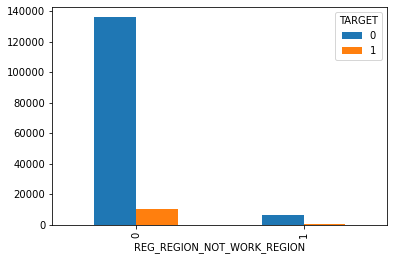

In [ ]:
pd.crosstab(dff['REG_REGION_NOT_WORK_REGION'],dff['TARGET']).plot(kind='bar')
#more values of REG_REGION_NOT_WORK_REGION=0 are present

In [ ]:
stat,P,d,arr=stats.chi2_contingency(p)

In [ ]:
print(P,stat,d,arr)
#this column also effects target according to p value

0.7713362406435283 0.08446433226661158 1 [[135940.41907397  10211.58092603]
 [  6568.58092603    493.41907397]]


## LIVE_REGION_NOT_WORK_REGION
Flag if client's contact address does not match work address (1=different, 0=same, at region level)

In [ ]:
dff[dff['LIVE_REGION_NOT_WORK_REGION'].isnull()==True]
#no null values

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,LOG_AMT_INCOME_TOTAL,FLAG_DOC_SCORE,LOG_AMT_CREDIT,LOG_AMT_ANNUITY,LOG_AMT_GOODS_PRICE,CNT_FAM_MEMBERS_


In [ ]:
dff['LIVE_REGION_NOT_WORK_REGION'].value_counts()

0    147201
1      6013
Name: LIVE_REGION_NOT_WORK_REGION, dtype: int64

In [ ]:
q=pd.crosstab(dff['LIVE_REGION_NOT_WORK_REGION'],dff['TARGET'])
q

TARGET,0,1
LIVE_REGION_NOT_WORK_REGION,,
0,136915,10286
1,5594,419


In [ ]:
(dff.groupby('LIVE_REGION_NOT_WORK_REGION')['TARGET'].sum()/dff['LIVE_REGION_NOT_WORK_REGION'].value_counts())*100
#both are similar. looks like no change according to this

LIVE_REGION_NOT_WORK_REGION
0    6.987724
1    6.968235
dtype: float64

<AxesSubplot:>

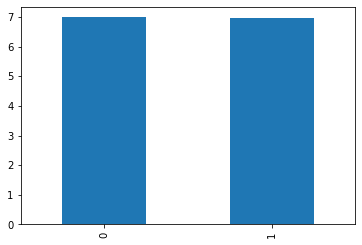

In [ ]:
(dff[dff['TARGET']==1]['LIVE_REGION_NOT_WORK_REGION'].value_counts()/dff['LIVE_REGION_NOT_WORK_REGION'].value_counts()*100).plot(kind='bar')

<AxesSubplot:xlabel='LIVE_REGION_NOT_WORK_REGION'>

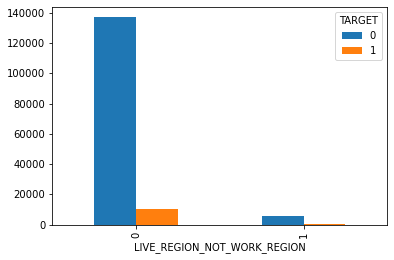

In [ ]:
pd.crosstab(dff['LIVE_REGION_NOT_WORK_REGION'],dff['TARGET']).plot(kind='bar')
#more values of LIVE_REGION_NOT_WORK_REGION=0 are present

In [ ]:
stat,Q,d,arr=stats.chi2_contingency(q)

In [ ]:
Q
#this column doesnt effect target according to p value

0.9742320016423094

### REG_CITY_NOT_LIVE_CITY
Flag if client's permanent address does not match contact address (1=different, 0=same, at city level)

In [ ]:
dff[dff['REG_CITY_NOT_LIVE_CITY'].isnull()==True]
#no null values

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,LOG_AMT_INCOME_TOTAL,FLAG_DOC_SCORE,LOG_AMT_CREDIT,LOG_AMT_ANNUITY,LOG_AMT_GOODS_PRICE,CNT_FAM_MEMBERS_


In [ ]:
dff['REG_CITY_NOT_LIVE_CITY'].value_counts()

0    147698
1      5516
Name: REG_CITY_NOT_LIVE_CITY, dtype: int64

In [ ]:
r=pd.crosstab(dff['REG_CITY_NOT_LIVE_CITY'],dff['TARGET'])
r

TARGET,0,1
REG_CITY_NOT_LIVE_CITY,,
0,137531,10167
1,4978,538


In [ ]:
(dff.groupby('REG_CITY_NOT_LIVE_CITY')['TARGET'].sum()/dff['REG_CITY_NOT_LIVE_CITY'].value_counts())*100
#looks like 1 has more chance of default

REG_CITY_NOT_LIVE_CITY
0    6.883641
1    9.753445
dtype: float64

<AxesSubplot:>

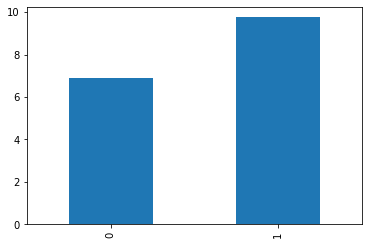

In [ ]:
(dff[dff['TARGET']==1]['REG_CITY_NOT_LIVE_CITY'].value_counts()/dff['REG_CITY_NOT_LIVE_CITY'].value_counts()*100).plot(kind='bar')

<AxesSubplot:xlabel='REG_CITY_NOT_LIVE_CITY'>

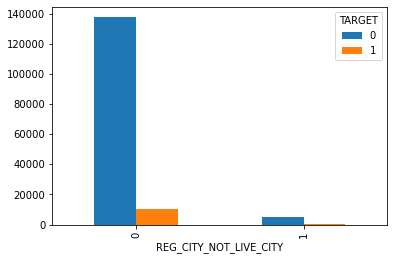

In [ ]:
pd.crosstab(dff['REG_CITY_NOT_LIVE_CITY'],dff['TARGET']).plot(kind='bar')
#more values of REG_CITY_NOT_LIVE_CITY=0 are present

In [ ]:
stat,R,d,arr=stats.chi2_contingency(r)

In [ ]:
R
#this column has effect on target according to p value

2.791033213496958e-16

### REG_CITY_NOT_WORK_CITY
Flag if client's permanent address does not match work address (1=different, 0=same, at city level)

In [ ]:
dff[dff['REG_CITY_NOT_WORK_CITY'].isnull()==True]
#no null values

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,LOG_AMT_INCOME_TOTAL,FLAG_DOC_SCORE,LOG_AMT_CREDIT,LOG_AMT_ANNUITY,LOG_AMT_GOODS_PRICE,CNT_FAM_MEMBERS_


In [ ]:
dff['REG_CITY_NOT_WORK_CITY'].value_counts()

0    134803
1     18411
Name: REG_CITY_NOT_WORK_CITY, dtype: int64

In [ ]:
s=pd.crosstab(dff['REG_CITY_NOT_WORK_CITY'],dff['TARGET'])
s

TARGET,0,1
REG_CITY_NOT_WORK_CITY,,
0,125712,9091
1,16797,1614


In [ ]:
(dff.groupby('REG_CITY_NOT_WORK_CITY')['TARGET'].sum()/dff['REG_CITY_NOT_WORK_CITY'].value_counts())*100
#looks like 1 has little more chance of default

REG_CITY_NOT_WORK_CITY
0    6.743915
1    8.766498
dtype: float64

<AxesSubplot:>

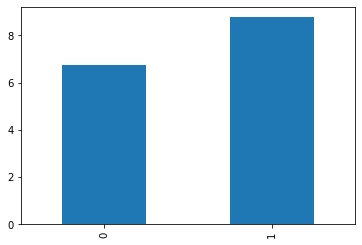

In [ ]:
(dff[dff['TARGET']==1]['REG_CITY_NOT_WORK_CITY'].value_counts()/dff['REG_CITY_NOT_WORK_CITY'].value_counts()*100).plot(kind='bar')

<AxesSubplot:xlabel='REG_CITY_NOT_WORK_CITY'>

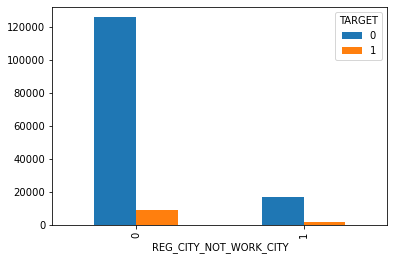

In [ ]:
pd.crosstab(dff['REG_CITY_NOT_WORK_CITY'],dff['TARGET']).plot(kind='bar')
#more values of REG_CITY_NOT_WORK_CITY=0 are present

In [ ]:
stat,S,d,arr=stats.chi2_contingency(s)

In [ ]:
S
#this column has effect on target according to p value

6.60546456133636e-24

### LIVE_CITY_NOT_WORK_CITY
Flag if client's contact address does not match work address (1=different, 0=same, at city level)

In [ ]:
dff[dff['LIVE_CITY_NOT_WORK_CITY'].isnull()==True]
#no null values

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,LOG_AMT_INCOME_TOTAL,FLAG_DOC_SCORE,LOG_AMT_CREDIT,LOG_AMT_ANNUITY,LOG_AMT_GOODS_PRICE,CNT_FAM_MEMBERS_


In [ ]:
dff['LIVE_CITY_NOT_WORK_CITY'].value_counts()

0    137574
1     15640
Name: LIVE_CITY_NOT_WORK_CITY, dtype: int64

In [ ]:
t=pd.crosstab(dff['LIVE_CITY_NOT_WORK_CITY'],dff['TARGET'])
t

TARGET,0,1
LIVE_CITY_NOT_WORK_CITY,,
0,128188,9386
1,14321,1319


In [ ]:
(dff.groupby('LIVE_CITY_NOT_WORK_CITY')['TARGET'].sum()/dff['LIVE_CITY_NOT_WORK_CITY'].value_counts())*100
#looks like 1 has little more chance of default

LIVE_CITY_NOT_WORK_CITY
0    6.822510
1    8.433504
dtype: float64

<AxesSubplot:>

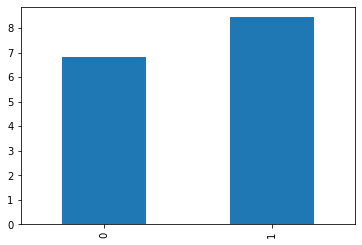

In [ ]:
(dff[dff['TARGET']==1]['LIVE_CITY_NOT_WORK_CITY'].value_counts()/dff['LIVE_CITY_NOT_WORK_CITY'].value_counts()*100).plot(kind='bar')

<AxesSubplot:xlabel='LIVE_CITY_NOT_WORK_CITY'>

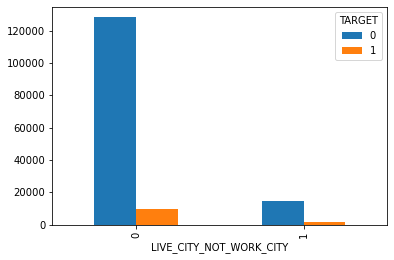

In [ ]:
pd.crosstab(dff['LIVE_CITY_NOT_WORK_CITY'],dff['TARGET']).plot(kind='bar')
#more values of LIVE_CITY_NOT_WORK_CITY=0 are present

In [ ]:
stat,T,d,arr=stats.chi2_contingency(t)

In [ ]:
T
#this column has effect on target according to p value

7.880521774754367e-14

In [ ]:
print('columns with their p values in ascending order')
print('')
print('')
print('REG_CITY_NOT_WORK_CITY:',S)
print('REG_CITY_NOT_LIVE_CITY:',R)
print('LIVE_CITY_NOT_WORK_CITY:',T)
print('REG_REGION_NOT_WORK_REGION:',P)
print('REG_REGION_NOT_LIVE_REGION:',O)
print('LIVE_REGION_NOT_WORK_REGION-','this column is not significant-',Q)

columns with their p values in ascending order


REG_CITY_NOT_WORK_CITY: 6.60546456133636e-24
REG_CITY_NOT_LIVE_CITY: 2.791033213496958e-16
LIVE_CITY_NOT_WORK_CITY: 7.880521774754367e-14
REG_REGION_NOT_WORK_REGION: 0.7713362406435283
REG_REGION_NOT_LIVE_REGION: 0.7091082403206508
LIVE_REGION_NOT_WORK_REGION- this column is not significant- 0.9742320016423094


# NIKHIL

## OBS_30_CNT_SOCIAL_CIRCLE

In [ ]:
dff['OBS_30_CNT_SOCIAL_CIRCLE'].isnull().sum()

626

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='OBS_30_CNT_SOCIAL_CIRCLE', ylabel='Density'>

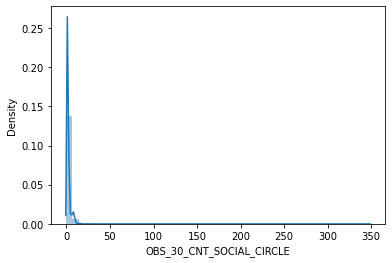

In [ ]:
sns.distplot(dff['OBS_30_CNT_SOCIAL_CIRCLE'])

In [ ]:
dff['OBS_30_CNT_SOCIAL_CIRCLE'].skew()

20.57116256647752

In [ ]:
dff['OBS_30_CNT_SOCIAL_CIRCLE'].value_counts()

0.0      82905
1.0      24238
2.0      14651
3.0       9774
4.0       6850
5.0       4606
6.0       3096
7.0       2052
8.0       1455
9.0        931
10.0       682
11.0       410
12.0       309
13.0       219
14.0       133
15.0        77
16.0        57
17.0        38
18.0        22
19.0        21
20.0        15
21.0        13
22.0        10
23.0         6
25.0         6
24.0         4
27.0         2
26.0         2
348.0        1
28.0         1
47.0         1
30.0         1
Name: OBS_30_CNT_SOCIAL_CIRCLE, dtype: int64

In [ ]:
li = []

for i in dff['OBS_30_CNT_SOCIAL_CIRCLE']:
    if i == 0.0:
        li.append('0')
    if i == 1.0:
        li.append('1')
    if i == 2.0:
        li.append('2')
    if i == 3.0:
        li.append('3')
    if i == 4.0:
        li.append('4')
    if i >= 5.0:
        li.append('greater than 4')

li1 = pd.Series(li)
dff['OBS_30_CNT_SOCIAL_CIRCLE'] = pd.DataFrame(li1)
dff['OBS_30_CNT_SOCIAL_CIRCLE'].value_counts()

0                 82905
1                 24238
2                 14651
greater than 4    14170
3                  9774
4                  6850
Name: OBS_30_CNT_SOCIAL_CIRCLE, dtype: int64

In [ ]:
o=pd.crosstab(dff['OBS_30_CNT_SOCIAL_CIRCLE'],dff['TARGET'])
o

TARGET,0,1
OBS_30_CNT_SOCIAL_CIRCLE,,
0,76992,5913
1,22525,1713
2,13617,1034
3,9154,620
4,6382,468
greater than 4,13254,916


In [ ]:
(dff.groupby('OBS_30_CNT_SOCIAL_CIRCLE')['TARGET'].sum()/dff['OBS_30_CNT_SOCIAL_CIRCLE'].value_counts())*100
#both are similar. looks like no change according to this

0                 7.132260
1                 7.067415
2                 7.057539
3                 6.343360
4                 6.832117
greater than 4    6.464361
dtype: float64

<AxesSubplot:>

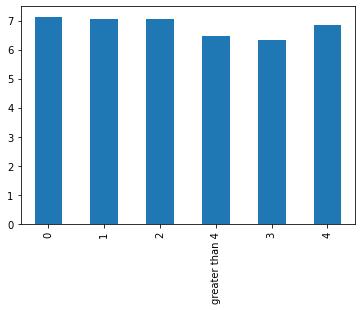

In [ ]:
(dff[dff['TARGET']==1]['OBS_30_CNT_SOCIAL_CIRCLE'].value_counts()/dff['OBS_30_CNT_SOCIAL_CIRCLE'].value_counts()*100).plot(kind='bar')

<AxesSubplot:xlabel='OBS_30_CNT_SOCIAL_CIRCLE'>

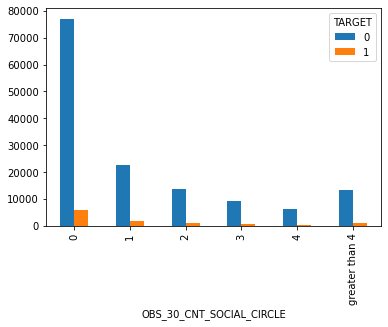

In [ ]:
pd.crosstab(dff['OBS_30_CNT_SOCIAL_CIRCLE'],dff['TARGET']).plot(kind='bar')
#more values of REG_REGION_NOT_LIVE_REGION=0 are present

In [ ]:
stat,O,d,arr=stats.chi2_contingency(o)

In [ ]:
O
#this column doesnt effect target according to p(o) value

0.008496887277270639

## DEF_30_CNT_SOCIAL_CIRCLE

In [ ]:
dff['DEF_30_CNT_SOCIAL_CIRCLE'].isnull().sum()

626

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='DEF_30_CNT_SOCIAL_CIRCLE', ylabel='Density'>

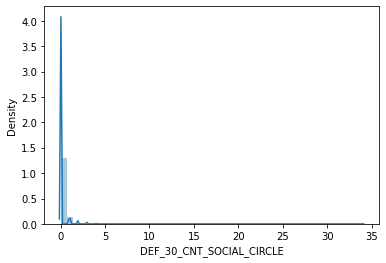

In [ ]:
sns.distplot(dff['DEF_30_CNT_SOCIAL_CIRCLE'])

In [ ]:
dff['DEF_30_CNT_SOCIAL_CIRCLE'].skew()

6.62104671377617

In [ ]:
dff['DEF_30_CNT_SOCIAL_CIRCLE'].value_counts()

0.0     135592
1.0      13744
2.0       2541
3.0        572
4.0        102
5.0         31
6.0          5
34.0         1
Name: DEF_30_CNT_SOCIAL_CIRCLE, dtype: int64

In [ ]:
l = []

for i in dff['DEF_30_CNT_SOCIAL_CIRCLE']:
    if i == 0.0:
        l.append('0')
    if i == 1.0:
        l.append('1')
    if i == 2.0:
        l.append('2')
    if i >= 3.0:
        l.append('greater than 2')
   
lis = pd.Series(l)
dff['DEF_30_CNT_SOCIAL_CIRCLE'] = pd.DataFrame(lis)
dff['DEF_30_CNT_SOCIAL_CIRCLE'].value_counts()

0                 135592
1                  13744
2                   2541
greater than 2       711
Name: DEF_30_CNT_SOCIAL_CIRCLE, dtype: int64

In [ ]:
#do visualization and chi2

In [ ]:
o=pd.crosstab(dff['DEF_30_CNT_SOCIAL_CIRCLE'],dff['TARGET'])
o

TARGET,0,1
DEF_30_CNT_SOCIAL_CIRCLE,,
0,126048,9544
1,12833,911
2,2380,161
greater than 2,663,48


In [ ]:
(dff.groupby('DEF_30_CNT_SOCIAL_CIRCLE')['TARGET'].sum()/dff['DEF_30_CNT_SOCIAL_CIRCLE'].value_counts())*100
#both are similar. looks like no change according to this

DEF_30_CNT_SOCIAL_CIRCLE
0                 7.038763
1                 6.628347
2                 6.336088
greater than 2    6.751055
dtype: float64

<AxesSubplot:>

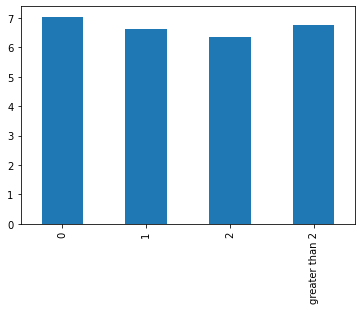

In [ ]:
(dff[dff['TARGET']==1]['DEF_30_CNT_SOCIAL_CIRCLE'].value_counts()/dff['DEF_30_CNT_SOCIAL_CIRCLE'].value_counts()*100).plot(kind='bar')

<AxesSubplot:xlabel='DEF_30_CNT_SOCIAL_CIRCLE'>

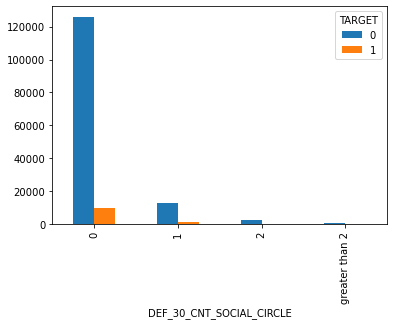

In [ ]:
pd.crosstab(dff['DEF_30_CNT_SOCIAL_CIRCLE'],dff['TARGET']).plot(kind='bar')
#more values of REG_REGION_NOT_LIVE_REGION=0 are present

In [ ]:
stat,O,d,arr=stats.chi2_contingency(o)

In [ ]:
O
#this column doesn't effects target according to p(o) value

0.17216192248981177

## OBS_60_CNT_SOCIAL_CIRCLE

In [ ]:
dff['OBS_60_CNT_SOCIAL_CIRCLE'].isnull().sum()

626

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='OBS_60_CNT_SOCIAL_CIRCLE', ylabel='Density'>

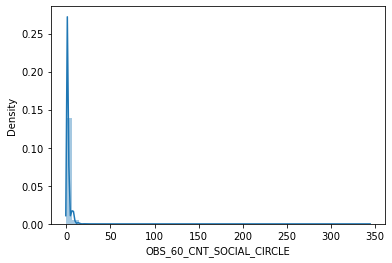

In [ ]:
sns.distplot(dff['OBS_60_CNT_SOCIAL_CIRCLE'])

In [ ]:
dff['OBS_60_CNT_SOCIAL_CIRCLE'].skew()

20.418531124839173

In [ ]:
dff['OBS_60_CNT_SOCIAL_CIRCLE'].head(15) 

0      2.0
1      1.0
2      0.0
3      0.0
4      0.0
5      8.0
6      0.0
7      0.0
8      0.0
9      1.0
10     0.0
11    10.0
12     0.0
13     0.0
14     2.0
Name: OBS_60_CNT_SOCIAL_CIRCLE, dtype: float64

In [ ]:
li = []

for i in dff['OBS_60_CNT_SOCIAL_CIRCLE']:
    if i == 0.0:
        li.append('0')
    if i == 1.0:
        li.append('1')
    if i == 2.0:
        li.append('2')
li1 = pd.Series(li)
dff['OBS_60_CNT_SOCIAL_CIRCLE'] = pd.DataFrame(li1)
dff['OBS_60_CNT_SOCIAL_CIRCLE'].value_counts()

0    83287
1    24253
2    14640
Name: OBS_60_CNT_SOCIAL_CIRCLE, dtype: int64

In [ ]:
#do visualization and chi2

In [ ]:
o=pd.crosstab(dff['OBS_60_CNT_SOCIAL_CIRCLE'],dff['TARGET'])
o

TARGET,0,1
OBS_60_CNT_SOCIAL_CIRCLE,,
0,77469,5818
1,22529,1724
2,13636,1004


In [ ]:
(dff.groupby('OBS_60_CNT_SOCIAL_CIRCLE')['TARGET'].sum()/dff['OBS_60_CNT_SOCIAL_CIRCLE'].value_counts())*100
#both are similar. looks like no change according to this

OBS_60_CNT_SOCIAL_CIRCLE
0    6.985484
1    7.108399
2    6.857923
dtype: float64

<AxesSubplot:>

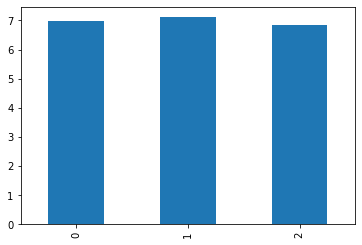

In [ ]:
(dff[dff['TARGET']==1]['OBS_60_CNT_SOCIAL_CIRCLE'].value_counts()/dff['OBS_60_CNT_SOCIAL_CIRCLE'].value_counts()*100).plot(kind='bar')

<AxesSubplot:xlabel='OBS_60_CNT_SOCIAL_CIRCLE'>

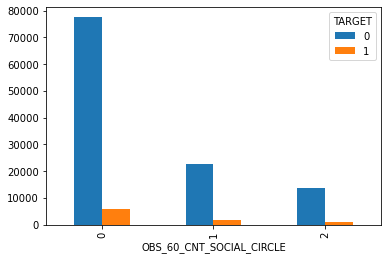

In [ ]:
pd.crosstab(dff['OBS_60_CNT_SOCIAL_CIRCLE'],dff['TARGET']).plot(kind='bar')
#more values of REG_REGION_NOT_LIVE_REGION=0 are present

In [ ]:
stat,O,d,arr=stats.chi2_contingency(o)

In [ ]:
O
#this column also effects target according to p(o) value

0.6332312823142566

## DEF_60_CNT_SOCIAL_CIRCLE

In [ ]:
dff['DEF_60_CNT_SOCIAL_CIRCLE'].isnull().sum()

626

In [ ]:
dff['DEF_60_CNT_SOCIAL_CIRCLE'].value_counts()

0.0     140230
1.0      10484
2.0       1511
3.0        295
4.0         55
5.0         10
6.0          2
24.0         1
Name: DEF_60_CNT_SOCIAL_CIRCLE, dtype: int64

In [ ]:
#do visualization and chi2

In [ ]:
o=pd.crosstab(dff['DEF_60_CNT_SOCIAL_CIRCLE'],dff['TARGET'])
o

TARGET,0,1
DEF_60_CNT_SOCIAL_CIRCLE,,
0.0,130756,9474
1.0,9485,999
2.0,1341,170
3.0,257,38
4.0,50,5
5.0,10,0
6.0,2,0
24.0,1,0


In [ ]:
(dff.groupby('DEF_60_CNT_SOCIAL_CIRCLE')['TARGET'].sum()/dff['DEF_60_CNT_SOCIAL_CIRCLE'].value_counts())*100
#both are similar. looks like no change according to this

DEF_60_CNT_SOCIAL_CIRCLE
0.0      6.756044
1.0      9.528806
2.0     11.250827
3.0     12.881356
4.0      9.090909
5.0      0.000000
6.0      0.000000
24.0     0.000000
dtype: float64

<AxesSubplot:>

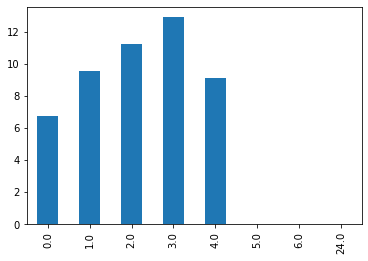

In [ ]:
(dff[dff['TARGET']==1]['DEF_60_CNT_SOCIAL_CIRCLE'].value_counts()/dff['DEF_60_CNT_SOCIAL_CIRCLE'].value_counts()*100).plot(kind='bar')

<AxesSubplot:xlabel='DEF_60_CNT_SOCIAL_CIRCLE'>

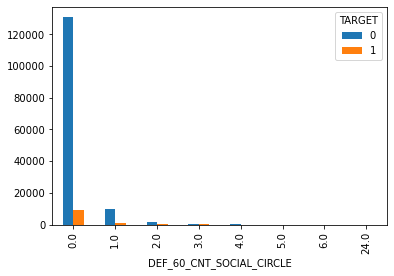

In [ ]:
pd.crosstab(dff['DEF_60_CNT_SOCIAL_CIRCLE'],dff['TARGET']).plot(kind='bar')
#more values of REG_REGION_NOT_LIVE_REGION=0 are present

In [ ]:
stat,O,d,arr=stats.chi2_contingency(o)

In [ ]:
O
#this column doesnt effects target according to p(o) value

2.5702067777070392e-34

## DAYS_LAST_PHONE_CHANGE

In [ ]:
dff['DAYS_LAST_PHONE_CHANGE'].isnull().sum()

1

In [ ]:
dff['DAYS_LAST_PHONE_CHANGE']=abs(dff['DAYS_LAST_PHONE_CHANGE'])

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='DAYS_LAST_PHONE_CHANGE', ylabel='Density'>

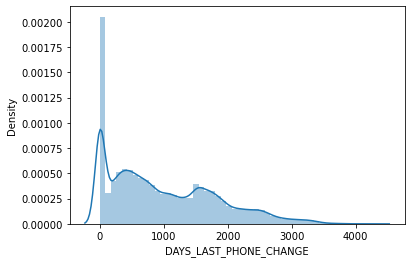

In [ ]:
sns.distplot(dff['DAYS_LAST_PHONE_CHANGE'])

In [ ]:
dff['DAYS_LAST_PHONE_CHANGE'].skew()

0.6998993837324363

<AxesSubplot:xlabel='TARGET', ylabel='DAYS_LAST_PHONE_CHANGE'>

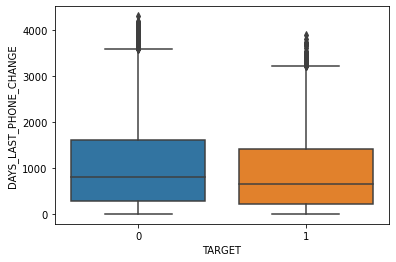

In [ ]:
sns.boxplot(y=dff['DAYS_LAST_PHONE_CHANGE'],x=dff['TARGET'])

In [ ]:
i=pt.fit_transform(dff[['DAYS_LAST_PHONE_CHANGE']])

In [ ]:
i.shape

(153214, 1)

In [ ]:
i=i.ravel()

In [ ]:
i=pd.Series(i)

In [ ]:
i.skew()

-0.47512346680020506

In [ ]:
dff['DAYS_LAST_PHONE_CHANGE_TR']=i

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:ylabel='Density'>

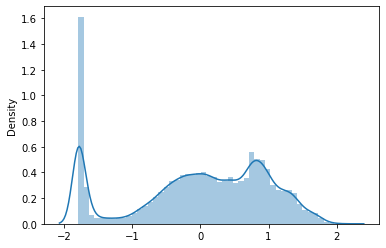

In [ ]:
sns.distplot(i)

<AxesSubplot:xlabel='TARGET'>

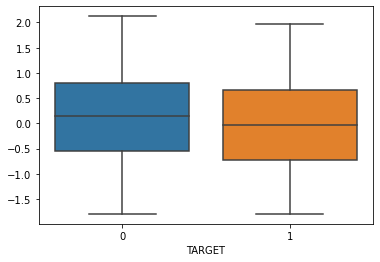

In [ ]:
sns.boxplot(y=i,x=dff['TARGET'])

In [ ]:
dff.shape

(153214, 118)

In [ ]:
dff.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 153214 entries, 0 to 153213
Columns: 118 entries, TARGET to DAYS_LAST_PHONE_CHANGE_TR
dtypes: float64(78), int64(19), object(21)
memory usage: 144.1+ MB


In [ ]:
# dff['FLAG_EMP_PHONE'] = dff['FLAG_EMP_PHONE'].astype('object')
dff['FLAG_EMP_PHONE'] = dff['FLAG_EMP_PHONE'].astype('object')
dff['FLAG_WORK_PHONE'] = dff['FLAG_WORK_PHONE'].astype('object')
dff['FLAG_CONT_MOBILE'] = dff['FLAG_CONT_MOBILE'].astype('object')
dff['FLAG_PHONE'] = dff['FLAG_PHONE'].astype('object')
dff['FLAG_EMAIL'] = dff['FLAG_EMAIL'].astype('object')

dff['REGION_RATING_CLIENT'] = dff['REGION_RATING_CLIENT'].astype('object')
dff['REGION_RATING_CLIENT_W_CITY'] = dff['REGION_RATING_CLIENT_W_CITY'].astype('object')
dff['REG_REGION_NOT_LIVE_REGION'] = dff['REG_REGION_NOT_LIVE_REGION'].astype('object')
dff['REG_REGION_NOT_WORK_REGION'] = dff['REG_REGION_NOT_WORK_REGION'].astype('object')
dff['LIVE_REGION_NOT_WORK_REGION'] = dff['LIVE_REGION_NOT_WORK_REGION'].astype('object')

dff['REG_CITY_NOT_LIVE_CITY'] = dff['REG_CITY_NOT_LIVE_CITY'].astype('object')
dff['REG_CITY_NOT_WORK_CITY'] = dff['REG_CITY_NOT_WORK_CITY'].astype('object')
dff['LIVE_CITY_NOT_WORK_CITY'] = dff['LIVE_CITY_NOT_WORK_CITY'].astype('object')

dff['DEF_60_CNT_SOCIAL_CIRCLE'] = dff['DEF_60_CNT_SOCIAL_CIRCLE'].astype('object')


# CNT_CHILDREN
### Number of children the client has

In [ ]:
dff['CNT_CHILDREN'].isnull().sum()

0

In [ ]:
dff['CNT_CHILDREN'].value_counts()


0     108501
1      31317
2      11946
3       1292
4        130
5         13
6          5
7          4
12         2
19         1
14         1
10         1
9          1
Name: CNT_CHILDREN, dtype: int64

In [ ]:
l=[]
for i in dff['CNT_CHILDREN']:
    if i >=3 :
        l.append('Others')
    else:
        l.append(i)
# #len(l)
pd.Series(l).value_counts()   

0         108501
1          31317
2          11946
Others      1450
dtype: int64

In [ ]:
dff['CNT_CHILDREN'] = l
dff['CNT_CHILDREN'].value_counts()

0         108501
1          31317
2          11946
Others      1450
Name: CNT_CHILDREN, dtype: int64

In [ ]:
default = dff[dff['TARGET']==1]

In [ ]:
c = default['CNT_CHILDREN'].value_counts()*100/dff['CNT_CHILDREN'].value_counts()
c

0         6.723440
1         7.679535
2         7.408338
Others    8.275862
Name: CNT_CHILDREN, dtype: float64

Text(0, 0.5, 'Percentage')

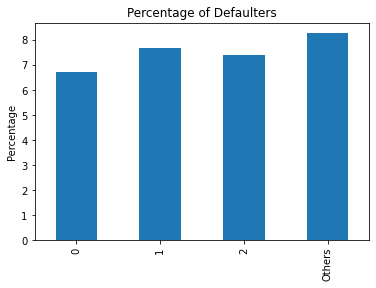

In [ ]:
c.plot(kind='bar')
plt.title('Percentage of Defaulters')
plt.ylabel('Percentage')

In [ ]:
children = pd.crosstab(dff['TARGET'] , dff['CNT_CHILDREN'])

In [ ]:
stats.chi2_contingency(children)

(41.6786808854289,
 4.694129353276176e-09,
 3,
 array([[100920.07916378,  29128.89391962,  11111.33782814,
           1348.68908846],
        [  7580.92083622,   2188.10608038,    834.66217186,
            101.31091154]]))

In [ ]:
# # p value less than 0.05. significant column

## EXT SOURCE

In [ ]:
dff.info(max_cols = 120)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 153214 entries, 0 to 153213
Data columns (total 118 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   TARGET                        153214 non-null  int64  
 1   NAME_CONTRACT_TYPE            153214 non-null  object 
 2   CODE_GENDER                   153214 non-null  object 
 3   FLAG_OWN_CAR                  153214 non-null  object 
 4   FLAG_OWN_REALTY               153214 non-null  object 
 5   CNT_CHILDREN                  153214 non-null  object 
 6   AMT_INCOME_TOTAL              153214 non-null  float64
 7   AMT_CREDIT                    153214 non-null  float64
 8   AMT_ANNUITY                   153208 non-null  float64
 9   AMT_GOODS_PRICE               153085 non-null  float64
 10  NAME_TYPE_SUITE               152527 non-null  object 
 11  NAME_INCOME_TYPE              153214 non-null  object 
 12  NAME_EDUCATION_TYPE           153214 non-nu

In [ ]:
ext = dff.iloc[:,40:43]

In [ ]:
ext

,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
0,0.083037,0.262949,0.139376
1,0.311267,0.622246,NaN
2,0.464831,0.715042,0.176653
3,NaN,0.566907,0.770087
4,0.721940,0.642656,NaN
...,...,...,...
153209,0.145570,0.681632,NaN
153210,NaN,0.115992,NaN
153211,0.744026,0.535722,0.218859
153212,NaN,0.514163,0.661024


In [ ]:
l=[]
for i in range(len(ext)):
    if ext.iloc[i,0]== ext.iloc[i,0] and ext.iloc[i,1] == ext.iloc[i,1] and ext.iloc[i,2] == ext.iloc[i,2]:
        l.append((ext.iloc[i,0]+ext.iloc[i,1]+ext.iloc[i,2])/3)
    
    elif (ext.iloc[i,0] != ext.iloc[i,0] and ext.iloc[i,1] != ext.iloc[i,1] and ext.iloc[i,2] != ext.iloc[i,2]):
        l.append(0)
        
    elif (ext.iloc[i,0] == ext.iloc[i,0] and ext.iloc[i,1] == ext.iloc[i,1] and ext.iloc[i,2] != ext.iloc[i,2]):
        l.append((ext.iloc[i,0]+ext.iloc[i,1])/2)
    
    elif (ext.iloc[i,0] == ext.iloc[i,0] and ext.iloc[i,2] == ext.iloc[i,2] and ext.iloc[i,1] != ext.iloc[i,1]):
        l.append((ext.iloc[i,0]+ext.iloc[i,2])/2)
    
    elif (ext.iloc[i,1] == ext.iloc[i,1] and ext.iloc[i,2] == ext.iloc[i,2] and ext.iloc[i,0] != ext.iloc[i,0]):
        l.append((ext.iloc[i,1]+ext.iloc[i,2])/2)
    
    elif (ext.iloc[i,0] == ext.iloc[i,0] and ext.iloc[i,1] != ext.iloc[i,1] and ext.iloc[i,2] != ext.iloc[i,2]):
        l.append(ext.iloc[i,0])
    
    elif (ext.iloc[i,0] != ext.iloc[i,0] and ext.iloc[i,1] == ext.iloc[i,1] and ext.iloc[i,2] != ext.iloc[i,2]):
        l.append(ext.iloc[i,1])
    
    elif (ext.iloc[i,0] != ext.iloc[i,0] and ext.iloc[i,1] != ext.iloc[i,1] and ext.iloc[i,2] == ext.iloc[i,2]):
        l.append(ext.iloc[i,2])

dff['EXT_SOURCE_AVG'] = l

In [ ]:
dff['EXT_SOURCE_AVG']

0         0.161787
1         0.466757
2         0.452175
3         0.668497
4         0.682298
            ...   
153209    0.413601
153210    0.115992
153211    0.499536
153212    0.587593
153213    0.518984
Name: EXT_SOURCE_AVG, Length: 153214, dtype: float64

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='EXT_SOURCE_AVG', ylabel='Density'>

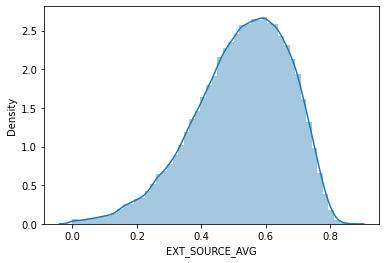

In [ ]:
sns.distplot(dff['EXT_SOURCE_AVG'])

In [ ]:
dff['EXT_SOURCE_AVG'].skew()

-0.583487568123855

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='EXT_SOURCE_AVG'>

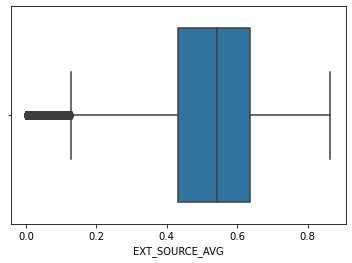

In [ ]:
sns.boxplot(dff['EXT_SOURCE_AVG'])

<AxesSubplot:xlabel='TARGET', ylabel='EXT_SOURCE_AVG'>

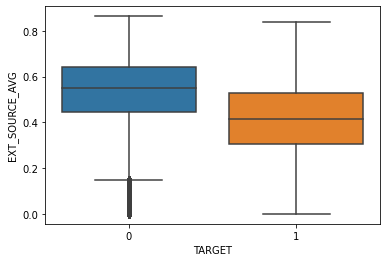

In [ ]:
sns.boxplot(y = dff['EXT_SOURCE_AVG'] , x = dff['TARGET'])

In [ ]:
default = dff[dff['TARGET']==1]
non_default = dff[dff['TARGET']==0]

In [ ]:
default_score = default['EXT_SOURCE_AVG']
non_default_score = non_default['EXT_SOURCE_AVG']

In [ ]:
stats.shapiro(dff['EXT_SOURCE_AVG'])

C:\Users\saketh\anaconda3\lib\site-packages\scipy\stats\morestats.py:1681: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


ShapiroResult(statistic=0.9755799174308777, pvalue=0.0)

In [ ]:
stats.mannwhitneyu(default_score , non_default_score)

MannwhitneyuResult(statistic=434544035.0, pvalue=0.0)

In [ ]:
dff.drop(['AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY','AMT_GOODS_PRICE','CNT_FAM_MEMBERS','DAYS_LAST_PHONE_CHANGE'], 
         axis = 1 , inplace = True)


In [ ]:
doc_cols

Index(['FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4',
       'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7',
       'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10',
       'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13',
       'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16',
       'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19',
       'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21'],
      dtype='object')

In [ ]:
dff.drop(doc_cols , axis = 1 , inplace = True)

In [ ]:
dff.drop(['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3'] , axis = 1 , inplace = True)

In [ ]:
dff.drop('FLAG_MOBIL', axis = 1 , inplace = True)

In [ ]:
dff.shape

(153214, 89)

In [ ]:
dff.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 153214 entries, 0 to 153213
Data columns (total 89 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   TARGET                        153214 non-null  int64  
 1   NAME_CONTRACT_TYPE            153214 non-null  object 
 2   CODE_GENDER                   153214 non-null  object 
 3   FLAG_OWN_CAR                  153214 non-null  object 
 4   FLAG_OWN_REALTY               153214 non-null  object 
 5   CNT_CHILDREN                  153214 non-null  object 
 6   NAME_TYPE_SUITE               152527 non-null  object 
 7   NAME_INCOME_TYPE              153214 non-null  object 
 8   NAME_EDUCATION_TYPE           153214 non-null  object 
 9   NAME_FAMILY_STATUS            153214 non-null  object 
 10  NAME_HOUSING_TYPE             153214 non-null  object 
 11  REGION_POPULATION_RELATIVE    153214 non-null  float64
 12  DAYS_BIRTH                    153214 non-nul

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
df_num = dff.select_dtypes(include = np.number)
df_cat = dff.select_dtypes(include = np.object)

<ipython-input-1730-758e6740e94a>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_num['TARGET'] = dff['TARGET']


In [ ]:
df_scaled = pd.concat([df_num , df_cat] , axis  = 1)
df_scaled.shape

(153214, 89)

In [ ]:
df_dummy = pd.get_dummies(df_scaled , drop_first = True)
df_dummy.shape

(153214, 154)

In [ ]:
null_dummy = df_dummy.isnull().sum()*100/len(df_dummy)

In [ ]:
drop_cols = null_dummy[null_dummy>25].index
drop_cols

Index(['YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'FLOORSMIN_MEDI',
       'LIVINGAPARTMENTS_MEDI', 'NONLIVINGAPARTMENTS_MEDI'],
      dtype='object')

In [ ]:
df_dummy.drop(drop_cols , axis = 1 , inplace = True)

In [ ]:
from sklearn.impute import KNNImputer

In [ ]:
knn = KNNImputer (n_neighbors = 5 , missing_values = np.nan ,weights ='distance' )
df_imp1 = pd.DataFrame(knn.fit_transform(df_dummy.iloc[0:75000,:]),columns = df_dummy.columns)

In [ ]:
df_imp1.shape

(75000, 149)

In [ ]:
knn = KNNImputer (n_neighbors = 5 , missing_values = np.nan ,weights ='distance' )
df_imp2 = pd.DataFrame(knn.fit_transform(df_dummy.iloc[75000:,:]),columns = df_dummy.columns)

In [ ]:
df_imp2.shape

(78214, 149)

In [ ]:
df_treated = df_imp1.append(df_imp2)
df_treated.shape

(153214, 149)

In [ ]:
df_treated.head()

,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,ELEVATORS_AVG,...,OBS_60_CNT_SOCIAL_CIRCLE_1,OBS_60_CNT_SOCIAL_CIRCLE_2,DEF_60_CNT_SOCIAL_CIRCLE_1.0,DEF_60_CNT_SOCIAL_CIRCLE_2.0,DEF_60_CNT_SOCIAL_CIRCLE_3.0,DEF_60_CNT_SOCIAL_CIRCLE_4.0,DEF_60_CNT_SOCIAL_CIRCLE_5.0,DEF_60_CNT_SOCIAL_CIRCLE_6.0,DEF_60_CNT_SOCIAL_CIRCLE_24.0,CNT_FAM_MEMBERS__small family
0,0.137117,-9461.0,-637.0,60.398675,-2120.0,-1.0,-1.287541,-0.735322,-1.037080,-0.770260,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.059506,-16765.0,-1188.0,34.438351,-291.0,-1.0,0.046047,-0.386587,0.354706,0.646277,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.177000,-13439.0,-2717.0,17.635192,-3227.0,-1.0,-0.156627,0.016064,-0.120148,-0.770260,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.128888,-14086.0,-3028.0,25.357445,-4911.0,23.0,0.673984,0.398693,-0.176602,1.270663,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.100030,-14583.0,-203.0,24.799194,-2056.0,-1.0,1.848476,0.884253,2.288712,1.778159,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
df_treated.to_csv('data122_unscaled_knn_5.csv')

# Scaling before knn

In [ ]:
target = df_num['TARGET']
df_num.drop('TARGET' , axis = 1 , inplace = True)

C:\Users\saketh\anaconda3\lib\site-packages\pandas\core\frame.py:4163: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().drop(


In [ ]:
ss = StandardScaler()
df_num_scaled = pd.DataFrame(ss.fit_transform(df_num), columns = df_num.columns)
df_num_scaled.head()

,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,ELEVATORS_AVG,...,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,LOG_AMT_INCOME_TOTAL,FLAG_DOC_SCORE,LOG_AMT_CREDIT,LOG_AMT_ANNUITY,LOG_AMT_GOODS_PRICE,DAYS_LAST_PHONE_CHANGE_TR,EXT_SOURCE_AVG
0,-0.059191,1.522747,0.200872,-0.222698,0.591199,-0.440086,-1.287541,-0.735322,-1.037080,-0.770260,...,-0.299493,-0.283541,-0.473080,0.500014,-0.04717,-0.265856,0.026460,-0.323019,0.452168,-2.475517
1,-1.778149,-0.148101,-0.006345,-1.150392,1.798882,-0.440086,0.046047,-0.386587,0.354706,0.646277,...,-0.299493,-0.283541,-1.005457,1.092633,-0.04717,1.348749,0.695337,1.306760,0.170787,-0.397189
2,0.824165,0.612748,-0.581364,-1.750854,-0.139750,-0.440086,-0.156627,NaN,-0.120148,-0.770260,...,0.650006,-0.283541,-1.005457,-1.763106,-0.04717,-2.519107,-2.579797,-2.622025,1.267880,-0.496559
3,-0.241455,0.464741,-0.698324,-1.474899,-1.251690,2.203309,0.673984,0.398693,-0.176602,1.270663,...,-0.299493,-0.283541,-0.473080,0.717055,-0.04717,0.871041,0.315809,0.634587,-1.664975,0.977645
4,-0.880608,0.351049,0.364089,-1.494848,0.633458,-0.440086,1.848476,0.884253,2.288712,1.778159,...,NaN,NaN,NaN,0.357890,-0.04717,0.631703,0.540323,0.598128,-0.768788,1.071698


In [ ]:
df_num_scaled['TARGET'] = target

In [ ]:
df_scaled = pd.concat([df_num_scaled , df_cat] , axis  = 1)
df_scaled.shape

(153214, 89)

In [ ]:
df_dummy_scaled = pd.get_dummies(df_scaled , drop_first = True)
df_dummy_scaled.shape

(153214, 154)

In [ ]:
null_dummy_s = df_dummy_scaled.isnull().sum()*100/len(df_dummy_scaled)

In [ ]:
drop_cols_s = null_dummy_s[null_dummy_s>25].index
drop_cols_s

Index(['YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'FLOORSMIN_MEDI',
       'LIVINGAPARTMENTS_MEDI', 'NONLIVINGAPARTMENTS_MEDI'],
      dtype='object')

In [ ]:
df_dummy_scaled.drop(drop_cols_s , axis = 1 , inplace = True)

In [ ]:
knn = KNNImputer (n_neighbors = 5 , missing_values = np.nan ,weights ='distance' )
df_imp1_s = pd.DataFrame(knn.fit_transform(df_dummy_scaled.iloc[0:75000,:]),columns = df_dummy_scaled.columns)

In [ ]:
df_imp1_s.shape

(75000, 149)

In [ ]:
knn = KNNImputer (n_neighbors = 5 , missing_values = np.nan ,weights ='distance' )
df_imp2_s = pd.DataFrame(knn.fit_transform(df_dummy_scaled.iloc[75000:,:]),columns = df_dummy_scaled.columns)

In [ ]:
df_imp2_s.shape

(78214, 149)

In [ ]:
df_treated_scaled = df_imp1_s.append(df_imp2_s)
df_treated_scaled.shape

(153214, 149)

In [ ]:
df_treated_scaled.head()

,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,ELEVATORS_AVG,...,OBS_60_CNT_SOCIAL_CIRCLE_1,OBS_60_CNT_SOCIAL_CIRCLE_2,DEF_60_CNT_SOCIAL_CIRCLE_1.0,DEF_60_CNT_SOCIAL_CIRCLE_2.0,DEF_60_CNT_SOCIAL_CIRCLE_3.0,DEF_60_CNT_SOCIAL_CIRCLE_4.0,DEF_60_CNT_SOCIAL_CIRCLE_5.0,DEF_60_CNT_SOCIAL_CIRCLE_6.0,DEF_60_CNT_SOCIAL_CIRCLE_24.0,CNT_FAM_MEMBERS__small family
0,-0.059191,1.522747,0.200872,-0.222698,0.591199,-0.440086,-1.287541,-0.735322,-1.037080,-0.770260,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-1.778149,-0.148101,-0.006345,-1.150392,1.798882,-0.440086,0.046047,-0.386587,0.354706,0.646277,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.824165,0.612748,-0.581364,-1.750854,-0.139750,-0.440086,-0.156627,-0.036591,-0.120148,-0.770260,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.241455,0.464741,-0.698324,-1.474899,-1.251690,2.203309,0.673984,0.398693,-0.176602,1.270663,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.880608,0.351049,0.364089,-1.494848,0.633458,-0.440086,1.848476,0.884253,2.288712,1.778159,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
df_treated_scaled.isnull().sum().sum()

0

In [ ]:
df_treated_scaled.to_csv('data122_scaled_knn_5.csv')